In [ ]:
# ====== 1. 나눔 폰트 설치 ======
!apt-get update -qq
!apt-get install fonts-nanum* -qq

# ====== 2. matplotlib 폰트 캐시 삭제 ======
import matplotlib as mpl
import matplotlib.font_manager as fm
import os

# 캐시 파일 삭제
cache_dir = mpl.get_cachedir()
print("Cache dir:", cache_dir)
!rm -rf ~/.cache/matplotlib/*

# ====== 3. NanumGothic 폰트 경로 찾기 ======
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
assert os.path.exists(font_path), "⚠ NanumGothic.ttf not found!"

# ====== 4. matplotlib에 폰트 강제 등록 ======
fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

# ====== 5. retina display 설정 ======
%config InlineBackend.figure_format = 'retina'

print("✅ 한글 폰트 세팅 완료!")


In [ ]:
!pip -q install arch statsmodels xlsxwriter
# !pip: 파이썬 라이브러리를 설치하는 명령어입니다.
# -q (Quiet): 설치 과정에서 발생하는 긴 메시지를 숨겨서, 노트를 깔끔하게 유지합니다.

import numpy as np # 숫자로 된 배열(행렬)을 다루거나 수학 계산을 할 때 사용합니다.
import pandas as pd #  CSV 파일을 읽고, 데이터를 표(DataFrame) 형태로 다루는 데 사용하는, 데이터 분석의 핵심 도구입니다.
import matplotlib.pyplot as plt # 데이터 분석 결과를 그래프로 그릴 때(시각화) 사용합니다.
import warnings # 분석 자체와 관련 없는 사소한 '경고(Warning)' 메시지가 뜨는 것을 방지합니다.
warnings.filterwarnings("ignore")

# 보기 좋은 출력 설정
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.rcParams["figure.figsize"] = (7,4)

# arch (GARCH) 모델 - GARCH 모형(시시각각 변하는 위험/변동성을 추정)을 사용하기 위해 필요합니다.
from arch import arch_model
import statsmodels.api as sm # 라이브러리에서 OLS(최소자승법) 회귀분석 모델을 불러옵니다.

# 데이터 정제

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive

# 1. 사용자가 제공한 Google Drive 경로를 변수로 사용합니다.
reits_file_path = "리츠 22-24 csv 형식 합본.csv"
pf_file_path = "포트폴리오 22-24 csv 형식 합본.csv"

print(f"리츠 파일 경로: {reits_file_path}")
print(f"포트폴리오 파일 경로: {pf_file_path}")

# ===== [STEP 2] 헬퍼 함수 정의 (zero_pad_krx) =====
def zero_pad_krx(x):
    """KRX 티커를 6자리 0패딩 문자열로 통일."""
    """
    목적: '5930'이나 '88260'처럼 형식이 다른 티커 번호를 '005930', '088260'처럼
           '6자리 숫자 문자열'로 통일시켜주는 함수입니다.
           (데이터를 합치거나 비교할 때 오류를 방지하기 위해 필수적입니다.)
    """
    try:
        xi = int(float(x))
        return f"{xi:06d}"
    except Exception:
        return str(x)

# ===== [STEP 2.5] clean_wide_prices 함수 정의 (새로운 컬럼명 반영) =====
def clean_wide_prices(path_in):
    """
    [수정됨]
    목적: 원본 CSV 파일(와이드형)을 읽어서,
           (date, ticker, close, cash_div) 구조의 '롱형' DataFrame으로 변환합니다.
    변경점: 'close_1', 'ticker_1' 대신 'Close', 'ticker.1' 같은 실제 컬럼명을 인식하도록 수정되었습니다.
    """
    # 1. 파일 읽기
    try:
        df = pd.read_csv(path_in)
    except FileNotFoundError:
        print(f"[오류] '{path_in}' 파일을 찾을 수 없습니다. Google Drive 경로와 파일명을 다시 확인하세요.")
        return None

    # 2) 날짜 열 확인/정렬
    if "Date" not in df.columns: # 'Date' 열이 없으면 분석이 불가능하므로 오류 발생
        raise ValueError("CSV에 'Date' 열이 필요합니다.")
    df["Date"] = pd.to_datetime(df["Date"]) # 'Date' 열을 '날짜' 형식으로 변환
    df = df.sort_values("Date").reset_index(drop=True) # 날짜순으로 정렬

    # 3) 불필요 열 제거 (Unnamed...)
    drop_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    # 4) Close / ticker / cash_div 쌍 찾기 (숫자 기준으로 정렬)
    def get_cols_sorted(prefix, all_cols):
        # prefix: "Close", "ticker", "cash_div" (Case-Sensitive)
        cols = [c for c in all_cols if str(c).startswith(prefix)]

        def get_sort_key(col_name):
            parts = str(col_name).split('.')
            if len(parts) == 1:
                return 0  # 'Close', 'ticker', 'cash_div'(숫자 없는 첫 번째 열)
            else:
                try:
                    return int(parts[-1]) # 'Close.1', 'Close.10'
                except ValueError:
                    return -1

        return sorted(cols, key=get_sort_key)

    all_cols = df.columns
    close_cols = get_cols_sorted("Close", all_cols) # 모든 가격 열 (예: [Close, Close.1, ...])
    tick_cols  = get_cols_sorted("ticker", all_cols) # 모든 티커 열 (예: [ticker, ticker.1, ...])
    div_cols   = get_cols_sorted("cash_div", all_cols) # 모든 배당 열 (예: [cash_div, cash_div.1, ...])

    if len(close_cols) == 0 or len(tick_cols) == 0:
        print(f"[경고] '{path_in}' 파일에서 'Close' 또는 'ticker' 열을 찾을 수 없습니다.")
        return None

    if len(close_cols) != len(tick_cols):
        raise ValueError(f"Close({len(close_cols)})와 ticker({len(tick_cols)}) 개수 불일치")

    has_div = len(div_cols) > 0
    if has_div and (len(div_cols) != len(close_cols)):
         raise ValueError(f"Close({len(close_cols)})와 cash_div({len(div_cols)}) 개수 불일치")

    # 5) ticker 열: 모드값으로 고정 + 6자리 0패딩
    for tc in tick_cols: # (엑셀 파일 특성상 티커가 '005930'이 아니라 '5930'으로 저장된 경우가 많음)
        mode_val = df[tc].dropna().mode() # 가장 자주 나온 값(티커)을 찾음
        if len(mode_val) > 0:
            df[tc] = mode_val.iloc[0] # 모든 행을 그 티커로 통일
        df[tc] = df[tc].map(zero_pad_krx) # 'zero_pad_krx' 함수로 6자리로 변환

    # 6) 와이드 → 롱 병합
    out_list = []
    for i in range(len(close_cols)):
        ccol = close_cols[i] # e.g., 'Close' or 'Close.1'
        tcol = tick_cols[i] # e.g., 'ticker' or 'ticker.1'

        cols_to_use = ["Date", ccol, tcol]
        rename_map = {"Date": "date", ccol: "close", tcol: "ticker"}

        if has_div: # 배당금 열이 존재한다면
            dcol = div_cols[i] # e.g., 'cash_div' or 'cash_div.1'
            cols_to_use.append(dcol) # 배당금 열도 함께 선택
            rename_map[dcol] = "cash_div" # 열 이름을 'cash_div'로 통일

        temp = df[cols_to_use].rename(columns=rename_map)
        out_list.append(temp)

    out = pd.concat(out_list, ignore_index=True).dropna(subset=["close"])

    # 7) 정리
    out["date"] = pd.to_datetime(out["date"])
    if has_div:
        out["cash_div"] = out["cash_div"].fillna(0.0) # 배당금이 없는 날(NaN)은 0으로 채움
    else:
        out["cash_div"] = 0.0 # 배당금 열이 없으면 0으로 생성

    out = out.sort_values(["ticker","date"]).reset_index(drop=True)
    return out

# ===== [STEP 3] 수정된 함수로 데이터 불러오기 =====
reits_prices = clean_wide_prices(reits_file_path)
pf_prices    = clean_wide_prices(pf_file_path)

print("\n--- REITs Data Sample (최종 수정본 적용) ---")
display(reits_prices.head())

print("\n--- PF Data Sample (최종 수정본 적용) ---")
display(pf_prices.head())

# ===== [STEP 3.5] 필수 열 확인 =====
# (분석에 필수적인 'date', 'ticker', 'close', 'cash_div' 열이 모두 존재하는지 확인)
# (만약 하나라도 없으면 여기서 오류가 발생하며 코드가 중지됨)
assert set(["date","ticker","close","cash_div"]).issubset(reits_prices.columns)
assert set(["date","ticker","close","cash_div"]).issubset(pf_prices.columns)
print("\n[성공] 모든 데이터가 'date, ticker, close, cash_div' 열을 포함하여 잘 로드되었습니다.")

In [ ]:
reits_prices = clean_wide_prices(reits_file_path)
pf_prices    = clean_wide_prices(pf_file_path)

print("REITs sample:")
display(reits_prices.head())
print("PF sample:")
display(pf_prices.head())

# ['assert'는 '안전장치'입니다]
# 'assert'는 "이 조건이 True가 아니면, 여기서 코드를 즉시 중단하고 오류를 발생시켜라"는 명령어입니다.
# 목적: 뒤따르는 분석(STEP 4 이후)에 필수적인 'date', 'ticker', 'close', 'cash_div' 열이
#       'reits_prices'에 정말로 존재하는지 "코드가 직접" 확인하도록 합니다.
#       (만약 'clean_wide_prices' 함수가 실패했다면, 여기서 오류가 발생하여 분석이 중단됩니다.)
# 기대 컬럼: date, ticker, close
assert set(["date","ticker","close"]).issubset(reits_prices.columns)
assert set(["date","ticker","close"]).issubset(pf_prices.columns)

# 이름 매핑

In [ ]:
# =====[STEP 5.5] 티커-이름 매핑 딕셔너리 생성 =====
# 사용자가 제공한 리스트 기준
ticker_list = [
    "404990 신한서부티엔디리츠", "396690 미래에셋글로벌리츠", "400760 NH올원리츠",
    "395400 SK리츠", "377190 디앤디플랫폼리츠", "365550 ESR켄달스퀘어리츠",
    "357120 코람코라이프인프라리츠", "357250 미래에셋맵스리츠", "348950 제이알글로벌리츠",
    "350520 이지스레지던스리츠", "334890 이지스밸류플러스리츠", "338100 NH프라임리츠",
    "330590 롯데리츠", "293940 신한알파리츠", "204210 스타에스엠리츠",
    "088260 이리츠코크렙", "145270 케이탑리츠", "140910 에이리츠"
]

ticker_to_name_map = {}
for item in ticker_list:
    parts = item.split(" ") # 공백을 기준으로 쪼개기
    if len(parts) >= 2:
        ticker = parts[0]
        name = " ".join(parts[1:]) # 이름에 공백이 있어도 처리
        ticker_to_name_map[ticker] = name

# '번역표'가 올바르게 만들어졌는지 출력하여 확인합니다.
print("티커-이름 매핑 생성 완료:")
print(ticker_to_name_map)

In [ ]:
# ... (STEP 5.5 리츠 티커-이름 매핑 코드) ...

# ===== 포트폴리오 티커-이름 매핑 생성 =====
pf_name_list = [
    "005930 삼성전자",
    "000660 SK하이닉스",
    "035720 카카오",
    "005380 현대차",
    "035420 네이버"
]

pf_ticker_to_name_map = {}
for item in pf_name_list:
    parts = item.split(" ")
    if len(parts) >= 2:
        pf_ticker_to_name_map[parts[0]] = parts[1]

print("포트폴리오 티커-이름 매핑 생성 완료:")
print(pf_ticker_to_name_map)

In [ ]:
# =====[STEP 5.5] 부동산 포트폴리오 티커-이름 매핑 생성 =====

# 1. '부동산 주식 포트폴리오'의 티커와 이름 리스트를 정의합니다.
real_pf_name_list = [
    "237350 KODEX 코스피 100",
    "411060 KRX 금현물",
    "360750 TIGER 미국 S&P500",
    "329200 TIGER 리츠부동산인프라"
]

# 2. 딕셔너리(번역표)를 생성합니다.
real_pf_ticker_to_name_map = {}
for item in real_pf_name_list:
    parts = item.split(" ")
    if len(parts) >= 2:
        ticker = parts[0]
        # 'TIGER 미국 S&P500'처럼 이름에 공백이 있어도 모두 포함합니다.
        name = " ".join(parts[1:])
        real_pf_ticker_to_name_map[ticker] = name

# 3. 생성된 매핑을 출력하여 확인합니다.
print("부동산 포트폴리오 티커-이름 매핑 생성 완료:")
print(real_pf_ticker_to_name_map)

# 수익률 계산

In [ ]:
# =====[STEP 4] 수익률 계산 함수 정의 (가격수익률 기본, cash_div 있으면 총수익률도) =====

# 목적: '롱형' 가격 데이터(df)를 받아서 '수익률'을 계산하는 함수를 만듭니다.
# 입력(df): (date, ticker, close[, cash_div]) 컬럼을 가진 DataFrame
# 입력(has_div): 배당(cash_div)을 포함한 '총수익률'을 계산할지 여부 (기본값=False)
# 반환: 'price_ret'(가격수익률)과 'total_ret'(총수익률)이 추가된 DataFrame
def add_returns(df, has_div=False):
    """
    입력 df: (date, ticker, close[, cash_div])
    has_div=True 이고 cash_div 열이 존재하면: total_ret 계산
    반환 컬럼: price_ret, (total_ret)
    """

    # 1. [중요] 계산 오류를 방지하기 위해 데이터를 '종목(ticker)'별로, '날짜(date)'순으로 정렬합니다.
    df = df.sort_values(["ticker","date"]).copy()

    # 2. '어제 종가' 열을 만듭니다. (수익률 계산의 기준이 됨)
    # .groupby("ticker"): 종목별로 따로따로 계산 (예: SK리츠가 롯데리츠의 가격에 영향을 주지 않도록 분리)
    # .shift(1): 데이터를 한 칸씩 아래로 내립니다. (오늘 날짜 행에 '어제 종가'가 오게 됨)
    df["close_lag"] = df.groupby("ticker")["close"].shift(1)

    # 3. 가격 수익률 (price_ret) 계산
    # 공식: (오늘 종가 / 어제 종가) - 1
    # (배당금을 포함하지 않은 순수한 주가 변동률입니다.)
    df["price_ret"] = df["close"] / df["close_lag"] - 1

    # 4. 총수익률 (total_ret) 계산 (배당 포함)
    # (has_div=True이고, 'cash_div' 열이 실제로 df에 존재할 때만 실행)
    if has_div and ("cash_div" in df.columns):
        df["cash_div"] = df["cash_div"].fillna(0.0)

        # 4-2. 총수익률 (total_ret) 계산
        # 공식: (오늘 종가 + 오늘 받은 배당금) / 어제 종가 - 1
        # (이것이 리츠 투자자의 '실질적인' 총수익률입니다.)
        df["total_ret"] = (df["close"] + df["cash_div"]) / df["close_lag"] - 1

    # 5. 수익률이 계산된 DataFrame을 반환합니다.
    return df

# =====[STEP 4] 수익률 계산 (실행) =====

# 1. 리츠(REITs) 수익률 계산
# 'reits_prices'에 'cash_div' 열이 있는지 자동으로 감지합니다. (STEP 3에서 만들었음)
reits_has_div = ("cash_div" in reits_prices.columns)
# add_returns 함수를 '리츠' 데이터로 실행합니다。
# 'cash_div' 열이 있으므로, has_div=True가 되어 'total_ret'까지 모두 계산됩니다.
reits_ret = add_returns(reits_prices, has_div=reits_has_div)

# 2. 포트폴리오(PF) 수익률 계산
# (포트폴리오 주식들은 배당을 고려하지 않으므로(논문 기준), has_div=False로 설정 -> 'price_ret'만 계산)
pf_ret = add_returns(pf_prices,has_div=False)

# 3. 수익률 표준화 ('ret' 열 생성)
# 목적: 이후 모든 분석(STEP 5~15)에서 사용할 '대표 수익률'을 'ret'라는 하나의 열로 통일합니다.

# [리츠] K-리츠는 배당이 핵심이므로, 'total_ret'(배당 포함)을 대표 수익률('ret')로 사용합니다.
# (만약 'total_ret'이 없으면(배당 데이터가 없었으면), 'price_ret'을 대신 사용합니다.)
reits_ret["ret"] = reits_ret["total_ret"] if ("total_ret" in reits_ret.columns) else reits_ret["price_ret"]

# [포트폴리오] 주식은 'price_ret'(배당 제외)을 대표 수익률('ret')로 사용합니다.
pf_ret["ret"] = pf_ret["price_ret"]

# 4. 최종 결과 확인 (상위 5줄)
# 'reits_ret' 테이블에 'total_ret'과 'ret' 열이 올바르게 생성되었는지 눈으로 확인합니다.
print("REITs returns (배당 포함 'total_ret'이 'ret'로 사용됨):")
display(reits_ret.head())
print("PF returns (배당 제외 'price_ret'이 'ret'로 사용됨):")
display(pf_ret.head())

## 1. 왜 “(오늘 종가 / 어제 종가) − 1”을 쓰는가?

핵심 이유는 단 하나입니다.

> **가격 비율을 “수익률(%)”로 바꾸기 위해서입니다.**

---

**2. 직관적으로 설명하면?**

예를 들어
어제 가격이 100원 → 오늘 가격이 105원이라면,

* 오늘 가격 / 어제 가격 = 105 / 100 = 1.05
* “1.05”는 **105%**, 즉 “원금 + 5% 수익”이라는 뜻이에요.

우리가 알고 싶은 건 **“얼마나 벌었냐?”**,
즉 **순수 수익률(5%)**이죠?

그래서 원금을 의미하는 1을 빼서

[
1.05 - 1 = 0.05
]

이게 바로 **5% 수익률**입니다.

---

**3. 수학적으로 표현하면?**

* **오늘 종가 / 어제 종가** = 전체 가치 비율(원금 포함)
* 여기서 −1을 해야
  → 원금(1)을 제거하고
  → 순수한 증가율(증가한 비율)만 남습니다.

즉,

[
{수익률} = {P_t}{P_{t-1}} - 1 = {P_t - P_{t-1}}{P_{t-1}}
]

수익률은 항상

> “얼마만큼 증가/감소했는가”
> 를 나타내는 비율이기 때문에 **증가분 / 원래 가격** 형태여야 합니다.

---

**4. total_ret에서 왜 배당을 더하는가?**

리츠나 배당주들은

* 가격 상승
* 배당금 지급

두 가지 모두 “수익”입니다.

예:

어제 종가 100원
오늘 종가 102원
오늘 배당 3원이라면

순수 수익은?

* 가격 상승: +2
* 배당 수익: +3
* 전체 수익: +5

따라서

[
{총수익률(total return)} = {102 + 3}{100} - 1 = 0.05 = 5%
]

→ **리츠는 배당이 핵심이기 때문에 “총수익률”을 써야 정확한 성과를 측정**할 수 있어요.

---

**5. 결론 한 문장으로**

>“−1”을 하는 이유는 원금을 제거하고,
> 순수한 수익률(상승분의 비율)을 얻기 위해서입니다.



In [ ]:
# 1. 리츠 데이터에 있는 모든 날짜를 가져옵니다.
common_dates = reits_ret["date"].unique()
common_dates = pd.to_datetime(common_dates)

# 2. 데이터의 가장 마지막 날짜(최근)를 찾습니다.
end_date = common_dates.max()

# 3. 그로부터 정확히 3년 전 날짜를 계산합니다.
start_date = end_date - pd.DateOffset(years=3)

# 4. (선택 사항) 만약 데이터가 3년보다 짧다면, 데이터의 시작일을 사용합니다.
if start_date < common_dates.min():
    start_date = common_dates.min()

print(f"--- 분석 기준 기간 설정 완료 ---")
print(f"시작일: {start_date.date()}")
print(f"종료일: {end_date.date()}")

In [ ]:
# ===== 3년 평균 수익률 계산 =====
import numpy as np

def compute_3y_stats_from_long(df_long, ret_col, start_date, end_date):
    """
    df_long: (date, ticker, ..., ret_col) 형태의 long DF
    ret_col: 'price_ret' (배당 제외) 또는 'total_ret' (배당 포함)
    start_date, end_date: 3년 구간
    반환: 각 ticker의 3Y 성과표 (일평균, 연환산평균, CAGR, 3Y 누적)
    """
    df = df_long.copy()
    df = df[(df["date"]>=start_date) & (df["date"]<=end_date)].dropna(subset=[ret_col])
    df = df.sort_values(["ticker","date"])

    rows = []
    for t, g in df.groupby("ticker"):
        if g.empty:
            continue
        r = g[ret_col]
        # 일평균, 연환산평균
        mean_daily = r.mean()
        mean_annual = mean_daily * 252

        # 3년 누적수익률 & CAGR
        cum = (1 + r).prod() - 1
        # 3년의 '년수'를 3.0으로 보고 CAGR 계산(금융업계 관행)
        cagr = (1 + cum) ** (1/3.0) - 1

        rows.append([t, mean_daily, mean_annual, cum, cagr, len(r)])

    out = pd.DataFrame(rows, columns=["ticker","mean_daily","mean_annual","cum_3y","cagr_3y","n_obs"])
    return out.set_index("ticker").sort_index()

# 가상 포트폴리오 생성

In [ ]:
# =====[STEP 5] 포트폴리오(균등가중) 구성 =====

# 'pf_ret'(포트폴리오 롱형 데이터)에 포함된 모든 고유한 티커를 리스트로 만듭니다.
pf_tickers_all = sorted(pf_ret["ticker"].unique().tolist())

# [논문 차용]
# '개인투자자의...' 논문에서 '분산 정도가 낮은 개인투자자'의 예시로 든
# 5개 핵심 주식(삼성전자, 현대차, SK하이닉스, 카카오, 네이버)의 티커를 'pf5' 리스트로 정의합니다.

pf5 = ["005930","005380","000660","035720","035420"]

# "만약(if) 우리가 업로드한 '포트폴리오.csv' 파일 안에 'pf5'의 5개 종목이 모두(all) 들어있다면,
#  'pf_choice'는 이 5개 종목('pf5')으로 확정한다.
#  만약 그렇지 않으면(else), 그냥 '포트폴리오.csv'에 들어있는 모든 종목('pf_tickers_all')을 사용한다."
pf_choice = pf5 if all(t in pf_tickers_all for t in pf5) else pf_tickers_all
print("포트폴리오 구성 티커:", pf_choice)

# '가상 포트폴리오'의 일일 수익률 계산
# .pivot(...): '롱형' 데이터('pf_ret')를 '와이드형' 데이터('ret_wide_pf')로 다시 변환합니다.
# [pf_choice]: 와이드형으로 바꾼 데이터에서 우리가 선택한 5개 종목('pf_choice')만 골라냅니다.
# .dropna(how="any"): 5개 종목 중 *하나라도* 데이터가 없는 날(NaN)은 그 날짜(행) 전체를 삭제합니다.
# Wide 피벗 후, 모든 종목이 결측 없는 공통 날짜만 사용
# '와이드 피벗(Wide Pivot)'은 데이터 테이블을 변형하는 기술 중 하나로, '롱(Long)형' 데이터를 '와이드(Wide)형' 데이터로 바꾸는 작업을 말합니다.
ret_wide_pf = pf_ret.pivot(index="date", columns="ticker", values="ret")[pf_choice].dropna(how="any")
ret_wide_pf["PF"] = ret_wide_pf.mean(axis=1) # 가상 포트폴리오 생성 - 가로(axis=1) / 균등가중으로 투자

pf_series = ret_wide_pf["PF"].copy()
pf_series.name = "pf_ret"

# [GARCH-M 모형 준비]
# 'STEP 8'의 GARCH-M 회귀분석(r_REIT,t = ... + β * r_PF,t-1)은
# '어제'의 포트폴리오 수익률(t-1)을 사용합니다.
# .shift(1): 'pf_series'의 모든 데이터를 하루씩 뒤로 밀어서 '어제 수익률' 시리즈('pf_lag1')를 미리 만듭니다.
pf_lag1 = pf_series.shift(1)

print("PF series sample:")
display(pf_series.head())

In [ ]:
# =====[STEP 5_property] 부동산 포트폴리오 데이터 불러오기 =====

real_pf_file_path = "부동산_pf.csv"

# 1) 부동산 PF 가격 데이터 읽기 (형식: Date, Close/ticker ... 기존 포트폴리오 파일과 동일 형식 가정)
real_pf_prices = clean_wide_prices(real_pf_file_path)

print("\n--- 부동산 포트폴리오 원시 데이터 샘플 ---")
display(real_pf_prices.head())

# 2) 수익률 계산
#    - 부동산 PF는 '직접 부동산 지수' 같은 느낌이라 배당은 없다고 가정 (필요하면 has_div=True + cash_div 열 활용 가능)
real_pf_ret = add_returns(real_pf_prices, has_div=False)

# 표준화: 'ret' = price_ret (부동산 PF는 배당 X 가정)
real_pf_ret["ret"] = real_pf_ret["price_ret"]

print("\n--- 부동산 포트폴리오 수익률 데이터 샘플 ---")
display(real_pf_ret.head())

In [ ]:
# =====[STEP 5_property_specific gravity] 부동산 포트폴리오 균등 비중 구성 =====

real_pf_tickers = sorted(real_pf_ret["ticker"].unique().tolist())
print("부동산 PF 구성 티커:", real_pf_tickers)

# Wide 피벗 후, 모든 종목이 결측 없는 공통 날짜만 사용
ret_wide_real_pf = real_pf_ret.pivot(
    index="date", columns="ticker", values="ret"
)[real_pf_tickers].dropna(how="any")

# 부동산 PF 균등 가중
ret_wide_real_pf["PF_real_eq"] = ret_wide_real_pf.mean(axis=1)

pf_real_series_eq = ret_wide_real_pf["PF_real_eq"].copy()
pf_real_series_eq.name = "pf_real_ret_eq"

# GARCH-M 회귀에서 쓸 전일 수익률
pf_real_lag1 = pf_real_series_eq.shift(1)

print("\n[부동산 PF series sample:]")
display(pf_real_series_eq.head())


In [ ]:
import pandas as pd
import numpy as np

# ======================================================================
# [STEP A-4] 3년 상세 성과 분석 (CAGR 내림차순 정렬 적용)
# ======================================================================

# 1. [준비] 분석 기간 설정
# (reits_ret 데이터가 이미 있다고 가정하고 기간을 계산합니다)
common_dates = pd.to_datetime(reits_ret["date"].unique())
end_date = common_dates.max()
start_date = end_date - pd.DateOffset(years=3)
print(f"분석 기준 기간: {start_date.date()} ~ {end_date.date()}")


# 2. [함수] 성과 분석 계산기 정의 (수정됨: CAGR 기준 내림차순 정렬)
def calculate_stats(df_long, ret_col, name_map=None, category_name="종목명"):
    """
    df_long: 롱형 데이터프레임 (date, ticker, ret_col 포함)
    ret_col: 수익률 컬럼명 ('price_ret' 또는 'total_ret')
    name_map: (이미 만들어진) 티커-이름 매핑 딕셔너리
    category_name: 결과표에 표시할 이름 컬럼의 제목 (예: '리츠명', '종목명')
    """
    # 기간 필터링
    df = df_long[(df_long["date"] >= start_date) & (df_long["date"] <= end_date)].copy()
    df = df.dropna(subset=[ret_col])

    rows = []
    # 종목별로 반복하며 통계량 계산
    for t, g in df.groupby("ticker"):
        r = g[ret_col]
        if len(r) == 0: continue

        # 핵심 통계 지표 계산
        mean_daily = r.mean()             # 일평균 수익률
        mean_annual = mean_daily * 252    # 연환산 수익률 (단리)
        cum_3y = (1 + r).prod() - 1       # 3년 누적 수익률
        cagr_3y = (1 + cum_3y) ** (1/3.0) - 1 # 3년 연평균 성장률 (복리) - ★가장 중요!

        # 티커를 이름으로 변환 (매핑 딕셔너리에 없으면 티커 그대로 사용)
        name = name_map.get(t, t) if name_map else t

        rows.append([t, name, mean_daily, mean_annual, cum_3y, cagr_3y, len(r)])

    # 결과표 생성
    out = pd.DataFrame(rows, columns=["ticker", category_name, "mean_daily", "mean_annual", "cum_3y", "cagr_3y", "n_obs"])

    # [!!! 수정된 부분 !!!]
    # sort_index() 대신 sort_values("cagr_3y", ascending=False)를 사용하여 내림차순 정렬
    return out.set_index(["ticker", category_name]).sort_values("cagr_3y", ascending=False)


# 3. [실행 & 출력] 4가지 핵심 성과표 확인

# 3-1. 리츠 3년 성과 (배당 제외: Price Return)
# -> 주가만 봤을 때 수익률이 높은 순서대로 정렬됩니다.
stats_reit_price = calculate_stats(reits_ret, "price_ret", ticker_to_name_map, "리츠명")
print("\n▼ [1] 리츠 3년 성과 (배당 제외, 주가만) - CAGR 높은 순")
display(stats_reit_price)

# 3-2. 리츠 3년 성과 (배당 포함: Total Return) ★핵심★
# -> 배당금 포함 실질 수익률이 높은 순서대로 정렬됩니다.
stats_reit_total = calculate_stats(reits_ret, "total_ret", ticker_to_name_map, "리츠명")
print("\n▼ [2] 리츠 3년 성과 (배당 포함, 실질수익률) - CAGR 높은 순")
display(stats_reit_total)

# 3-3. PF 구성 종목 3년 성과 (배당 제외)
# -> 개미들이 산 주식들 중 수익률이 좋은 순서대로 정렬됩니다.
stats_pf_stock = calculate_stats(pf_ret, "price_ret", pf_ticker_to_name_map, "종목명")
print("\n▼ [3] 개인투자자 PF 보유종목 3년 성과 (배당 제외) - CAGR 높은 순")
display(stats_pf_stock)

# 3-4. PF 전체(균등가중) 3년 성과
# -> (pf_series가 정의되어 있어야 실행됩니다)
try:
    pf_3y = pf_series[(pf_series.index >= start_date) & (pf_series.index <= end_date)].dropna()
    pf_stats = pd.DataFrame(
        [[pf_3y.mean(), pf_3y.mean()*252, (1+pf_3y).prod()-1, (1+(1+pf_3y).prod()-1)**(1/3)-1, len(pf_3y)]],
        columns=["mean_daily", "mean_annual", "cum_3y", "cagr_3y", "n_obs"],
        index=["PF_Equal_Weight"]
    )
    print("\n▼ [4] 개인투자자 PF 전체 성과 (5종목 균등)")
    display(pf_stats)
except NameError:
    print("\n[경고] 'pf_series' 변수가 없습니다. [STEP 5]를 먼저 실행해주세요.")

**1. 일평균 수익률 (Mean Daily Return)**
* **의미:** **"하루에 평균적으로 몇 %씩 벌었니?"**
* **계산:** 3년 동안의 모든 날짜의 수익률을 다 더해서 날짜 수로 나눈 것입니다.
* **특징:** 숫자가 아주 작습니다 (예: 0.05%).
* **비유:** "매일매일 용돈이 평균 50원씩 늘어났다." (너무 작아서 감이 잘 안 오죠?)

**2. 연환산 수익률 (단리) (Annualized Mean Return)**
* **의미:** **"하루 평균치를 1년(252일) 동안 계속 벌었다면, 총 몇 %가 될까?"** (단순 계산)
* **계산:** `일평균 수익률 × 252일` (주식시장은 주말/공휴일 빼고 1년에 약 252일 열립니다.)
* **특징:** **'복리 효과(이자가 이자를 낳는 것)'를 무시**하고 단순 곱하기만 한 값입니다. 실제 내 주머니에 들어오는 돈과는 차이가 클 수 있습니다.
* **비유:** "매일 50원씩 늘어나니까, 1년이면 대충 `50원 x 365일 = 18,250원` 벌겠네!" (단순 예상치)

**3. 3년 누적 수익률 (3-Year Cumulative Return)**
* **의미:** **"그래서 3년이 지난 지금, 처음에 넣은 돈이 총 몇 % 불어났니?"**
* **계산:** `(최종 금액 - 원금) / 원금`
* **특징:** 가장 직관적인 **'최종 성적표'**입니다. 중간 과정은 생략하고 '결과'만 봅니다.
* **비유:** "3년 전에 100만 원 넣었는데, 지금 꺼내보니 130만 원이네? **총 30%** 벌었다!"

**4. 3년 연평균 성장률 (복리) (CAGR)**
* **의미:** **"은행 예금으로 쳤을 때, 연이자 몇 %짜리 상품에 가입한 셈이니?"**
* **계산:** 3년 누적 수익률을 **'복리(Compounding)'** 개념으로 역산해서 1년 단위로 쪼갠 것입니다.
* **특징:** 금융권에서 **가장 신뢰하는 '진짜 실력' 지표**입니다. 기간이 다른 상품끼리(예: 3년 투자 vs 5년 투자) 비교할 때 공정한 기준이 됩니다.
* **비유:** "3년 동안 총 30%를 벌려면, 매년 10%씩이 아니라 **매년 9.14%씩** 꾸준히 복리로 불려야 하는구나. 즉, 내 투자는 **연이자 9.14%짜리 예금**과 똑같은 실력을 냈구나!"

---

**핵심 요약 (차이점)**

| 지표 | 설명 | 특징 |
| :--- | :--- | :--- |
| **연환산 수익률 (단리)** | 하루 평균 × 252 | 복리 효과가 없어서 **실제보다 과장될 수 있음.** (참고용) |
| **연평균 성장률 (복리)** | **CAGR** | 복리 효과를 반영한 **진짜 연 수익률.** (비교 분석용 **핵심 지표**) |

**학술제 팁:**
발표하실 때는 '3년 연평균 성장률(CAGR)'을 메인으로 사용하세요. 이것이 "은행 이자보다 얼마나 더 좋은지"를 설명하기 가장 정확하고 설득력 있는 지표입니다.

# 샤프지수를 최대화하는 비중(가상 포트폴리오 5종)

In [ ]:
import scipy.optimize as sco # '최고의 샤프지수'를 찾는 계산(최적화)을 할 때 필요

# =====[STEP 5-1] 평균-분산 최적화 (Max Sharpe, 롱온리) =====
"""
[학술적 참고: '균등가중' 외의 방식]
실무에서는 '균등가중'보다, 과거 데이터를 기반으로 '샤프 지수(위험 대비 수익)'가
최대가 되는 '최적의 비중'을 찾는 '평균-분산 최적화'를 사용하기도 합니다.
아래 코드는 이 '최적화' 방식을 구현하여 '균등가중' 방식과 비교하기 위한 코드입니다.

- 샤프 지수 = (포트폴리오 수익률) / (포트폴리오 위험)
- 과거 수익률로 기대수익(연환산)과 공분산(연환산)을 추정한 뒤
- Sharpe Ratio = (w'μ - r_f) / sqrt(w'Σw)를 최대화
- 제약조건:
    ① 모든 가중치는 0~1 (short 금지 = '롱온리')
    ② 가중치 합계 = 1 (전액 투자)
- 여기서는 무위험수익률(r_f) = 0으로 가정합니다.(단기무위험 수익률 무시)
"""
# [헬퍼 함수 1] 포트폴리오 성과 계산
def portfolio_performance(w, mean_ret, cov_mat):
    # w: 가중치 배열 (예: [0.2, 0.3, 0.5])
    # mean_ret: 연환산 평균 수익률
    # cov_mat: 연환산 공분산 행렬
    port_ret = np.dot(w, mean_ret) # 포트폴리오 수익률 계산
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w))) # 포트폴리오 위험(표준편차) 계산
    return port_ret, port_vol

# [헬퍼 함수 2] '샤프 지수의 음수(-)' 값 계산
def neg_sharpe(w, mean_ret, cov_mat, rf=0.0):
    port_ret, port_vol = portfolio_performance(w, mean_ret, cov_mat)
    # [핵심] 'scipy.optimize.minimize'는 값을 '최소화'만 할 수 있습니다.
    # 따라서 '샤프 지수'를 '최대화'하기 위해, '샤프 지수의 음수(-)' 값을 '최소화'하는 트릭을 사용합니다.
    return -(port_ret - rf) / port_vol

# [헬퍼 함수 3] '최대 샤프 지수'를 주는 가중치를 찾는 메인 함수
def get_max_sharpe_weights(ret_df, rf=0.0):
    """
    ret_df : (date x 종목) 일별 수익률 DataFrame
    반환   : Max Sharpe (연환산 기준) 포트폴리오 가중치 (Series)
    """
    # 1. 연환산 수익률(mean_annual)과 연환산 공분산(cov_annual) 계산
    rets = ret_df.dropna()
    mean_daily = rets.mean()
    mean_annual = mean_daily * 252 # (연환산)
    cov_daily = rets.cov()
    cov_annual = cov_daily * 252 # (연환산)
    # 연환산 : 1년 365일에서 주말(약 104일)과 공휴일(약 10~12일)을 제외한, 1년 동안 주식 시장이 열리는 평균적인 '거래일(Trading Days)' 수

    n = len(mean_annual) # 종목 개수 (5개)
    init_w = np.repeat(1/n, n) # 초기값: 균등비중
    bounds = tuple((0.0, 1.0) for _ in range(n))  # 제약 ①: 가중치는 0%~100% (롱온리)
    cons   = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)  # 제약 ②: 가중치 합계 = 1 (100%)

    # 2. 최적화 실행
    res = sco.minimize(
        neg_sharpe,
        init_w,
        args=(mean_annual.values, cov_annual.values, rf), # (고정 인자)
        method="SLSQP", # (표준적인 최적화 방식)
        bounds=bounds,
        constraints=cons
    )
    # 3. 결과 반환
    if not res.success:
        print("[경고] 포트폴리오 최적화 실패, 균등비중 사용:", res.message)
        w_opt = init_w # 이것이 최적화 '실패' 시 균등비중을 반환하는 코드입니다.
    else:
        w_opt = res.x # 이것은 최적화 '성공' 시 계산된 최적의 가중치를 반환하는 코드입니다.

    return pd.Series(w_opt, index=mean_annual.index, name="w_opt") # 계산된 최적의 가중치(예: [0.1, 0.4, 0.1, 0.3, 0.1])를 반환

# 5개 종목(또는 pf_choice 전체)에 대해 최적화 실행
ret_pf_for_opt = ret_wide_pf[pf_choice]   # 오직 5개 종목만 사용
w_opt_pf = get_max_sharpe_weights(ret_pf_for_opt, rf=0.0) # 최적화 실행

# 1. '최적화된 비중'을 표로 출력
print("\n[Max Sharpe 최적 비중]")
display(w_opt_pf.to_frame("weight"))

# 2. '최적화된 비중'으로 포트폴리오의 일일 수익률을 계산
pf_series_opt = (ret_pf_for_opt * w_opt_pf).sum(axis=1)
pf_series_opt.name = "pf_ret_opt"

# 3.
# 'pf_series' 변수에 '균등가중' 수익률('pf_series_eq')을 할당합니다.
# -> 이유: '개인투자자의...' 논문은 '균등가중(동일비중)'을 기준으로 분석했습니다.
# -> 따라서, 이후 모든 STEP(6, 8, 10, 11...)은 '균등가중' 포트폴리오를 기준으로 분석하게 됩니다.
print("\nPF series sample (균등 PF):")
display(pf_series.head())
print("\nPF series (최적화 PF) sample:")
display(pf_series_opt.head())


## 1. “가중치 0~1, short 금지”의 의미

✔ ① 가중치 0~1 의미

각 종목에 배분할 비중(weight)이 **0% 이상, 100% 이하**라는 뜻이에요.

즉,

* 0.0 → 이 종목은 한 주도 사지 않는다
* 0.5 → 전체 자산의 50%를 이 종목에 투자
* 1.0 → 전체 100%를 이 종목에 몰빵 투자

이 **범위를 벗어나면 안 된다는 제약 조건**입니다.

---

✔ ② “short 금지(short no)“의 의미

short는 **공매도**를 뜻해요.

예를 들어:

* 가중치 = –0.2 → 전체 자산의 –20%를 그 종목에 공매도
* 가중치 = 1.3 → 전체 자산의 130%를 투자 (레버리지)

이런 건 금지하겠다는 뜻입니다.

즉,

> ✔ 가중치가 음수(공매도)거나
> ✔ 합계가 1보다 커지는 레버리지는
> 허용하지 않는다.

→ 완전히 “현금 100% 안에서만 배분하는 일반적인 개인투자자 포트폴리오”를 뜻해요.

---

✔ ③ “가중치 합계 = 1” 의미

전문가님이 말한 그대로입니다.

> **각 종목 비중을 모두 더했을 때 총합이 1(=100%)이도록 강제한다.**

예:

* 0.3 + 0.2 + 0.1 + 0.4 + 0.0 = 1.0
* 0.94 + 0.06 + 0 + 0 + 0 = 1.0

→ 총 자산 100%를 정확히 5개 종목에 나누어 배분한다는 뜻이에요.

---

**2. 결과 해석**

**005930(삼성전자): 0.0**
**000660(SK하이닉스): 0.94**
같은 결과는,

> 과거 데이터에서 샤프지수를 최대화하려면
> 포트폴리오를 거의 ‘SK하이닉스’로만 구성해도 가장 효율적이었다

라는 뜻입니다.

이건 최적화 모델의 전형적인 특징입니다
(높은 PL/변동성 구조를 가진 종목이 성과를 좌우할 때 비중이 확 치우침).



# 초기 분석 - 베타/상관관계

In [ ]:
# =====[STEP 6] 리츠 리턴 wide, 공통 날짜 맞추기 =====

# - index="date": 행(가로줄)을 '날짜'로 설정합니다.
# - columns="ticker": 열(세로줄)을 '리츠 티커'로 설정합니다.
# - values="ret": 표의 값은 'ret'(총수익률)으로 채웁니다.
# -> 결과: (날짜 x 리츠 티커) 형태의 표가 생성됩니다.
ret_wide_reits = reits_ret.pivot(index="date", columns="ticker", values="ret")

# PF lag1과 공통 인덱스
# 목적: '리츠' 데이터와 'PF' 데이터가 모두 존재하는 날짜(교집합)만 찾아냅니다.
#      (이유: K-리츠는 거래가 됐는데 PF 5종목 중 하나가 거래정지였거나, 그 반대인 날을 제거하기 위함)
# - ret_wide_reits.index: '리츠' 데이터의 모든 날짜
# - pf_lag1.dropna().index: 'PF' 데이터의 모든 날짜 (shift(1)로 생긴 첫날 결측치(NaN)는 .dropna()로 제거)
# - .intersection(...): 두 날짜 리스트의 '교집합'을 찾습니다.
common_idx = ret_wide_reits.index.intersection(pf_lag1.dropna().index)
ret_wide_reits = ret_wide_reits.loc[common_idx]
pf_lag1        = pf_lag1.loc[common_idx]
reits_list     = ret_wide_reits.columns.tolist()

print(f"리츠 종목 수: {len(reits_list)}")
print("공통 기간:", common_idx.min().date(), "~", common_idx.max().date())

In [ ]:
# =====[STEP 6_real] 리츠 수익률과 부동산 PF 공통 날짜 맞추기 =====

# 리츠 수익률 wide (총수익률 ret 컬럼 기준)
ret_wide_reits_real = reits_ret.pivot(index="date", columns="ticker", values="ret")

# 부동산 PF(전일 수익률)과의 공통 날짜만 사용
common_idx_real = ret_wide_reits_real.index.intersection(pf_real_lag1.dropna().index)
ret_wide_reits_real = ret_wide_reits_real.loc[common_idx_real]
pf_real_lag1       = pf_real_lag1.loc[common_idx_real]
pf_real_series_eq  = pf_real_series_eq.loc[common_idx_real]

reits_list_real = ret_wide_reits_real.columns.tolist()

print(f"\n[Scenario 2] 리츠 종목 수: {len(reits_list_real)}")
print("공통 기간:", common_idx_real.min().date(), "~", common_idx_real.max().date())

In [ ]:
# ===== 상관관계 계산 유틸 =====
def corr_series_pair(s1, s2, idx):
    """두 시계열의 피어슨 상관계수 (날짜 교집합 idx에서)."""
    s1c = s1.loc[idx].dropna()
    s2c = s2.loc[idx].dropna()
    common = s1c.index.intersection(s2c.index)
    if len(common) == 0:
        return np.nan
    return s1c.loc[common].corr(s2c.loc[common])

def corr_table_vs_indices(df_reits_wide, pf_series, kospi_ret, kosdaq_ret,
                          stress_quantile=0.80, windows=None):
    """
    df_reits_wide: 리츠 수익률 wide (index=date, columns=ticker)
    pf_series    : PF 일수익률(Series)
    kospi_ret    : Yahoo로 받은 KOSPI 일수익률 Series
    kosdaq_ret   : Yahoo로 받은 KOSDAQ 일수익률 Series
    stress_quantile: 스트레스 임계 (예: 0.80 → |PF수익률| 상위 20%)
    windows: {'label': (start, end), ...} 형태의 임의 분석 구간 (선택)
    반환: dict(label -> DataFrame[corr_kospi, corr_kosdaq, corr_pf])
    """
    results = {}

    # 전체 기간
    full_idx = df_reits_wide.index
    abs_pf = pf_series.loc[full_idx].abs()
    thr = abs_pf.quantile(stress_quantile)
    stress_idx = abs_pf[abs_pf >= thr].index
    calm_idx   = abs_pf[abs_pf < thr].index

    def build_corr_block(idx, label):
        rows = []
        for t in df_reits_wide.columns:
            r = df_reits_wide[t]
            rows.append([
                t,
                corr_series_pair(r, kospi_ret,  idx),
                corr_series_pair(r, kosdaq_ret, idx),
                corr_series_pair(r, pf_series,  idx)
            ])
        out = (pd.DataFrame(rows, columns=["ticker","corr_kospi","corr_kosdaq","corr_pf"])
                 .set_index("ticker")
                 .sort_values("corr_kospi"))
        results[label] = out

    build_corr_block(full_idx,   "full")
    build_corr_block(stress_idx, "stress")
    build_corr_block(calm_idx,   "calm")

    # 윈도우(선택)
    if windows:
        for label, (s, e) in windows.items():
            idx = full_idx[(full_idx>=s) & (full_idx<=e)]
            build_corr_block(idx, f"window_{label}")

    return results

# 리츠 종합지수

In [ ]:
# =====[STEP 6.5] 리츠 종합지수(동일가중 총수익률 인덱스) 생성 =====
"""
리츠 종합지수(REIT_EQ_TR_INDEX) 만들기 요약:

1) ret_wide_reits : (날짜 × 리츠 티커) 형태의 '총수익률(ret)' 테이블
2) 이 표에서 각 날짜별로 모든 리츠의 수익률을 평균 → 동일가중 수익률(reit_eq_ret)
3) (1 + 수익률)을 누적곱해 복리 지수로 변환
4) 보기 편하게 시작값을 100으로 맞춘다
→ 결과: "리츠 시장 전체에 N분의 1씩 투자했을 때"의 성장 곡선
"""

# 1) 일별 동일가중 평균 수익률 계산
# ret_wide_reits : 각 리츠의 일별 총수익률이 들어 있는 테이블
# mean(axis=1) → 행 기준 평균 = 해당 날짜의 "리츠 전체 평균 수익률"
reit_eq_ret = ret_wide_reits.mean(axis=1)
reit_eq_ret.name = "REIT_EQ_TR_RET"
# TR = Total Return (배당 포함). 동일가중 리츠 포트폴리오의 일간 수익률

# 2) 동일가중 수익률을 복리로 누적한 지수 계산
# (1 + 수익률)을 매일 곱해 주고, 시작 기준값을 100으로 맞춘다
reit_eq_index = (1 + reit_eq_ret).cumprod() * 100
reit_eq_index.name = "REIT_EQ_TR_INDEX"
# 동일가중 리츠 포트폴리오의 누적 성과 지수

# 결과 확인
print("\n[리츠 동일가중 총수익률 지수 예시]:")
display(reit_eq_index.to_frame().head())

# ──────────────────────────────────────────────
# (선택) 개인투자자 PF(5종 동일비중 PF)의 지수도 계산해서 비교
# 전문가님 기존 PF인 pf_series = 5개 주식의 동일비중 일일 수익률
pf_index_eq = (1 + pf_series).cumprod() * 100
pf_index_eq.name = "PF_EQ_INDEX"

# ──────────────────────────────────────────────
# 두 지수를 하나의 그래프에 비교
plt.figure(figsize=(8,4))
plt.plot(reit_eq_index, label="REIT 동일가중 TR 지수")  # 리츠 전체지수
plt.plot(pf_index_eq,  label="PF(5종 균등) 지수")        # 개인투자자 PF 지수

plt.title("분석 대상 상장리츠 구성\n(유형별 색상 구분)", fontsize=22, fontweight='bold', pad=30)

plt.tight_layout(rect=[0, 0, 1, 0.9])

plt.legend()
plt.grid(True)
plt.show()


# GARCH-M

## 1. GARCH가 선택된 가장 직접적인 이유

논문의 목적은 다음과 같습니다:

* 개인투자자 포트폴리오와 리츠 간의
  **동적 상관관계(time-varying correlation)** 분석
* 시장 급등락 시
  **리츠의 베타(민감도)가 어떻게 변하는지** 분석
* 변동성(σ²)이 수익률에 영향을 미치는지 검증

즉, 목표는 **“리츠가 시장 변동성에 어떻게 반응하는가?”를 계량적으로 파악**하는 것입니다.

GARCH-M은 바로 이 목적을 위해 설계된 모델이에요.

---

2. 금융 논문에서 GARCH가 표준으로 쓰이는 이유
**굵은 텍스트**
리츠 가격은 다음 특징을 갖습니다.

* **이분산성(heteroskedasticity)**
* **클러스터링된 변동성(volatility clustering)**
* **급등락(Leverage effect)**

GARCH는 이러한 특성을 잡기 위해 만들어진 금융공학적 모형입니다.

또한,

* 정책 변화
* 금리 충격
* 코로나19 같은 급격한 쇼크
  이 있을 때 변동성이 커지는 구조도 GARCH가 잘 포착합니다.

LSTM은 변동성 해석에는 불리합니다.





## 1. 동적 상관관계란?

> **시간이 지나면서 변하는 상관관계**를 의미합니다.
> 즉, “두 자산의 관계가 고정되어 있지 않고, 시장 상황에 따라 계속 달라지는 것”.

일반 상관관계는 ‘하나의 숫자(예: 0.3)’로 표현되죠?
그런데 금융시장에서는 **상관관계가 시점마다 바뀝니다.**

예를 들어,

* 평온한 시기에는 리츠와 코스피 상관이 낮다가 (0.10)
* 금리 폭등기에는 상관이 급격히 높아지고 (0.65)
* 경기 회복기에는 다시 상관이 낮아지는 (0.20)

이렇게 **계속 오르락내리락하는 상관관계**를 말합니다.

---

**2. 왜 동적 상관관계가 중요할까? (특히 리츠에서)**

리츠를 포트폴리오에 넣는 가장 큰 이유는 **분산효과**입니다.
즉, 다른 자산과 상관이 낮으면 위험이 줄어들어요.

하지만 문제는…

> **상관관계가 위기 때 갑자기 상승하면 분산 효과가 사라진다.**

예:

* 2020년 코로나 초기 → 거의 모든 자산 상관관계 급등
* 2022 금리 급등기 → 리츠·주식 상관도 상승

이걸 **정적 상관관계(고정된 상관값)**으로 분석하면 진실을 놓칩니다.

그래서 연구자들은
“리츠가 언제는 안전자산이고, 언제는 위험자산이 되는가?”
이걸 분석하기 위해 **시간에 따라 변화하는 상관관계**를 사용합니다.

---

**3. 리츠에선 동적 상관관계가 필수인 이유**

리츠는 독특합니다.

✔ 평상시

* 주식보다 변동성이 낮고
* 상관도 낮거나 중간
  → 분산효과 좋음

✔ 스트레스 시기(금리 급등, 시장 폭락)

* 갑자기 시장과 함께 떨어짐
* 상관관계가 **폭등**

즉,

> **리츠는 평상시엔 방패(hedge), 위기 때는 동조(herding) 경향이 있음.**
> 이걸 정확히 측정해야 “어떤 리츠가 진짜 방패 역할을 하는지” 알 수 있습니다.

---

**4. 어떤 모델이 동적 상관관계를 잡을까?**

이런 분석을 위해 만들어진 모델이 **DCC-GARCH 모델**입니다.

* DCC = Dynamic Conditional Correlation
* 즉, **GARCH 기반으로 변동성을 추정한 뒤 시점별 상관을 계산**

이 모델이 금융계가 “포트폴리오 위험”을 분석할 때 표준입니다.

LSTM은 패턴 예측은 잘하지만,

* 상관관계
* 변동성
* 충격 반응
  이런 **금융 리스크 구조**를 직접 계산하지 않습니다.

그래서 분산투자 전략 연구에서는
➡ LSTM 대신 DCC-GARCH가 정석입니다.

---

**한 문장으로 정리하면?**

> **“자산 간 관계는 일정하지 않고 시간에 따라 계속 변하기 때문에
> 정적 상관관계로는 분산투자 효과를 평가할 수 없다.
> 리츠의 진짜 위험을 알기 위해서는 ‘동적 상관관계(time-varying correlation)’가 필수다.”**




In [ ]:
# =====[STEP 7] 변동성(σ_t) 추정 함수들 =====
## STEP 7 = σₜ을 GARCH로 구하는 단계

def ewma_sigma(series, lam=0.94):
    """
    EWMA 방식으로 조건부 변동성(σ_t)을 계산하는 함수.

    lam(λ) = 0.94 는 RiskMetrics에서 사용하는 금융권 표준값으로,
    '기억의 비율'을 의미합니다.
      - 최근 데이터: 가중치 6% (1 - λ)
      - 오래된 데이터: 가중치 94% (λ)
    시간이 지날수록 가중치가 지수적으로 감소하여,
    최신 수익률 변동을 더 많이 반영하는 변동성 계산 방식입니다.
    """
    sq = series**2                                 # 수익률 제곱 (분산 요소)
    ew = sq.ewm(alpha=(1-lam), adjust=False).mean() # 지수 가중 이동평균(EWMA)
    return np.sqrt(ew)                             # 분산 → 표준편차 변환(σ_t)


def garch_sigma(series):
    """
    GARCH(1,1) 모델로 조건부 변동성(σ_t)을 추정하는 함수.

    특징:
    - GARCH는 '변동성이 자기 자신을 따라 움직이는 현상'을 모델링한 통계모형.
    - 금융 시계열(주가, 리츠, 환율 등)에서 가장 많이 쓰이는 변동성 모델.

    구현 방식:
    1) 안정적인 최적화를 위해 수익률을 % 단위로 변환 (예: 0.01 → 1.0)
    2) arch_model fit
    3) 적합 후 다시 100으로 나누어 원래 스케일로 복원
    """
    s = series.dropna()

    # mean="Zero" → GARCH에서는 평균을 0으로 두는 것이 일반적
    am = arch_model(s * 100.0, mean="Zero", vol="GARCH",
                    p=1, q=1, dist="normal")

    res = am.fit()         # 출력 억제하며 모델 적합
    print(res.summary())

    sig = res.conditional_volatility / 100.0        # 다시 원래 스케일로 변환
    sig.name = "sigma_garch"

    # series.index와 동일한 인덱스로 맞추기 (빈 값은 NaN)
    return sig.reindex(series.index)


def sigma_engine(series, prefer="garch"):
    """
    변동성 계산 엔진.

    prefer="garch"
        →  GARCH 변동성을 우선 시도
        →  실패 시 자동으로 EWMA로 대체(fallback)

    prefer="ewma"
        →  무조건 EWMA만 사용
    """
    if prefer == "ewma":
        return ewma_sigma(series)

    # prefer="garch"일 때 GARCH 먼저 시도
    try:
        return garch_sigma(series)
    except Exception as e:
        print(f"[경고] GARCH 실패로 EWMA 사용: {e}")
        return ewma_sigma(series)

## 리츠가 주식 PF 수익률·변동성에 얼마나 민감한지(β, δ)를 추정

**1. “HAC로 표준오차를 보정한다”는 게 무슨 말인가?**

우리가 평균방정식(회귀식)을 추정할 때
오차항 εₜ가 다음 성질을 가진다고 가정합니다:

* 서로 독립(independent)
* 등분산(homoskedastic)
* 시계열 상관 없음(no autocorrelation)

하지만 금융 데이터(리츠, 주식, 환율)는?

* 자기상관 있음
* 이분산성 있음
* 분포는 fat-tail
  → 즉, OLS의 기본 가정을 완전히 위배합니다.

그래서 회귀식을 그대로 돌리면

* **계수 자체는 일관적(consistency)을 유지하지만**
* **표준오차가 잘못 계산됩니다.**

즉,
α, β, δ는 맞게 나올 수 있지만
p-value(유의성 검정)는 완전히 틀릴 수 있는 것입니다.

그래서 사용하는 것이 바로 **HAC(Newey-West) 표준오차 보정**입니다.

---

**HAC(Newey-West) 표준오차 =**

> “시계열 자기상관 + 이분산성까지 함께 보정한 표준오차”

* 잔차가 자기상관을 가져도
* 잔차가 이분산적이어도
* 분포가 정규가 아니어도

**Newey-West 표준오차는 유효(robust)** 합니다.

그래서 OLS를 쓸 수 있는 이유가 생깁니다.

---

**2. “σₜ을 평균식의 설명변수로 사용하면 OLS가 가능한 이유”**

> **GARCH-M에서는 평균식과 분산식을 분리 추정(two-step)할 수 있다.**

이걸 이해하면 왜 OLS가 가능한지 자동으로 이해됩니다.

---

**✔ GARCH-M 모형의 구조를 다시 보면**

📌 (1) 분산 방정식

[
σ_t^2 = ω + α ε_{t-1}^2 + β σ_{t-1}^2
]

여기서 σₜ은
**과거 정보만으로 계산된 값(조건부 변동성)**입니다.

즉, σₜ은 **현재 수익률 rₜ에 영향을 받지 않습니다.**
→ 그래서 **외생변수(exogenous variable)** 처럼 동작합니다.

📌 (2) 평균 방정식 (In-Mean equation)

[
r_t = α + β r_{PF,t-1} + δ σ_t + ε_t
]

여기서는
σₜ이 “설명변수(정해진 값)”으로 사용됩니다.

---

**핵심 요점**

> σₜ은 rₜ로부터 독립적으로 GARCH로 먼저 추정되기 때문에
> **평균식에서는 외생변수처럼 OLS로 계수를 추정할 수 있다.**

σₜ이 **내생적**이어야 문제인데
GARCH는 σₜ을 **과거 오차와 과거 변동성**만으로 계산하므로
현재 수익률 방정식과 독립적으로 존재합니다.

즉,

✔ σₜ은 “현재 수익률 rₜ”를 설명하는 변수이지만

✔ rₜ은 σₜ을 결정하지 않는다

→ 구조적으로 OLS가 가능함

---

**3. 다시 말해 두 가지 조건이 OLS를 가능하게 한다**

조건 1) σₜ은 과거 정보만으로 계산된 “조건부 변동성”이다

→ 내생성이 없다 (endogeneity 문제 X)

조건 2) 표준오차는 HAC로 보정한다

→ 자기상관과 이분산 문제 해결

그래서 평균방정식은 OLS로 추정해도
**계수가 일관적으로 추정되고,
표준오차도 robust하게 계산된다.**

---

**4. 그래서 학계에서 GARCH-M을 Two-Step으로 추정하는 것이** 표준

GARCH-M 추정의 대표 방식 두 가지:

✔ 방법 1) Full MLE (평균방정식 + 분산방정식 동시 추정)

→ 더 정확하지만 복잡하고 수렴 안되기 쉬움

✔ 방법 2) Two-Step 방식

1단계: GARCH로 σₜ 추정
2단계: σₜ을 평균식에 넣어서 OLS(HAC)로 회귀
→ 실증연구에서 가장 많이 쓰는 방식
→ 논문도 이 방식을 사용

전문가님의 코드가 바로 이 방식입니다.

---

**5. 한 문장으로 완벽 정리**

> **GARCH-M 평균식은 σₜ이 외생변수처럼 동작하기 때문에
> OLS로 계수를 추정해도 일관성 문제가 없고,
> 잔차의 자기상관·이분산은 HAC(Newey-West) 표준오차로 해결된다.**





**1. 논문에서 In-Mean 회귀 **

논문 식(1-1):

[
R_t = \alpha_0

* \sum_{i=1}^n \alpha_1 R_{t-i}
* \beta_1 R_{m,t-1}
* \delta \sigma_t
* \mu_t
  ]

여기서 핵심 용어는 바로 **δ σₜ** 입니다.

논문은 이것을 이렇게 표현합니다:

> “식 (1-1)은 **GARCH-M의 평균방정식(mean equation)** 구조를 따른다.”
> “σₜ(조건부 분산의 제곱근) 이 기대수익률에 영향을 미치는 In-Mean 효과를 추정한다.”

즉, **식 (1-1)이 바로 In-Mean 회귀 그 자체**입니다.

---

**2. GARCH-M이란 무엇인가?**

GARCH-M은 **두 가지 구성요소**를 가지고 있습니다.

| 구성                  | 내용                             |
| ------------------- | ------------------------------ |
| ① Mean Equation     | σₜ이 수익률에 직접 들어가는 회귀식 (In-Mean) |
| ② Variance Equation | GARCH(1,1)로 σₜ 계산              |


> **GARCH-M = 평균방정식(수익률) + GARCH 변동성방정식의 결합**

---

**3. 평균방정식(Mean Equation)이 바로 이 코드입니다**

코드:

```python
X = sm.add_constant(df[["r_pf_lag1", "sigma_t"]])
y = df["r_reit"]
res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":1})
```

이 회귀식은 다음을 의미합니다:

[
r_{REIT,t}
= \alpha + \beta \cdot r_{PF,t-1}

* \delta \cdot \sigma_t
* \epsilon_t
  ]

✔ r_pf_lag1 = 개인 PF의 전일 수익률
✔ σₜ = GARCH로 계산한 조건부 변동성
✔ OLS로 계수 α, β, δ를 추정

➡ **이 자체가 바로 In-Mean 회귀식 = GARCH-M mean equation**

---

**4. 그럼 왜 “GARCH-M 전체를 추정하는 패키지”처럼 안 썼는가?**

이유는 아주 간단합니다.

✔ 논문은 "GARCH-M 전체 추정"을 한 것이 아니라,

✔ **GARCH로 σₜ을 추정한 다음, σₜ을 평균방정식에 넣어 OLS를 따로 돌리는 방법론**을 사용했습니다.

논문에서도 이 방식으로 설명합니다:

> “조건부 분산(σₜ)은 GARCH(1,1) 모형을 사용하여 먼저 추정하고,
> 이를 평균방정식에 포함하여 In-Mean 효과를 분석한다.”

즉,

1. 먼저 σₜ = GARCH로 추정
2. 그 σₜ를 Mean Equation에 넣어 OLS로 계수 δ 추정
   → 이것이 바로 논문 방식

전문가님의 코드가 이 논문 방법론을 100% 그대로 따라간 것입니다.

---

**정리**

> ✔ STEP 7 = σₜ을 GARCH로 구하는 단계
> ✔ STEP 8 = 그 σₜ을 평균방정식에 넣어 In-Mean 효과(δ)를 추정하는 단계

**STEP 7 + STEP 8 = GARCH-M 방식으로 In-Mean 효과 분석**




### 평균방정식/분산방정식

In [ ]:
# =====[STEP 8-Ex] In-Mean 회귀: r_REIT,t = α + β * r_PF,t-1 + δ * σ_t + ε_t =====
## In-Mean 회귀는 GARCH-M(GARCH-in-Mean) 모형의 ‘평균방정식(mean equation)’ 부분을 구현한 것입니다.
## 즉, In-Mean 회귀 = GARCH-M의 Mean Equation을 따로 떼어내어 회귀로 추정한 것입니다.

def inmean_regression(r_reit, r_pf_lag1, sigma_t):
    """
    입력: 각 시계열(Series) - 인덱스는 날짜, 값은 일수익률/σ_t
    출력: statsmodels 회귀 결과 객체(OLS with HAC)
    - HAC 표준오차(maxlags=1)로 약한 자기상관/이분산 보정
    """
    df = pd.concat([r_reit, r_pf_lag1, sigma_t], axis=1, join="inner").dropna()
    df.columns = ["r_reit", "r_pf_lag1", "sigma_t"]

    X = sm.add_constant(df[["r_pf_lag1", "sigma_t"]])
    y = df["r_reit"]

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":1})
    return res

# === 예시: 첫 번째 리츠로 σ_t 계산 후 회귀 실행해보기 ===
example_reit = reits_list[0]
sigma_example = sigma_engine(ret_wide_reits[example_reit], prefer="garch")  # "ewma"로 바꾸면 EWMA 사용
res_example = inmean_regression(ret_wide_reits[example_reit], pf_lag1, sigma_example)

print(f"[{example_reit}] In-Mean 회귀 결과 요약(핵심계수만):")
print(res_example.summary().tables[1])  # 계수 테이블만 출력

### 회귀분석(GARCH-M 스타일 In-Mean 회귀) 단계

**가상 포트폴리오 5종**

In [ ]:
# =====[STEP 8] 전 리츠 종목에 대해 In-Mean 회귀 실행 → 결과 테이블 =====
##“그 5개 종목으로 구성된 포트폴리오의 수익률(PF) 을 리츠의 설명변수로 사용한 것”
rows = []
sigma_cache = {}

for t in reits_list:
    r = ret_wide_reits[t]
    if t not in sigma_cache:
        sigma_cache[t] = sigma_engine(r, prefer="garch")

    sigma_t = sigma_cache[t]
    res     = inmean_regression(r, pf_lag1, sigma_t)

    rows.append([
        t,
        res.params.get("r_pf_lag1", np.nan),
        res.tvalues.get("r_pf_lag1", np.nan),
        res.pvalues.get("r_pf_lag1", np.nan),
        res.params.get("sigma_t", np.nan),
        res.tvalues.get("sigma_t", np.nan),
        res.pvalues.get("sigma_t", np.nan),
        res.rsquared
    ])

beta_table = pd.DataFrame(
    rows,
    columns=["ticker","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
)

# [!!! 수정된 부분 !!!]
# ticker_to_name_map을 사용해 '리츠명' 열을 추가합니다.
beta_table["리츠명"] = beta_table["ticker"].map(ticker_to_name_map)
# 리츠명 열을 ticker 뒤로 재정렬
cols = ["ticker", "리츠명", "beta", "t_beta", "p_beta", "delta", "t_delta", "p_delta", "R2"]
beta_table = beta_table[cols]

beta_table = beta_table.sort_values("beta")

print("GARCH-M 스타일 In-Mean 회귀 결과 (β 오름차순):")
display(beta_table)

**부동산**

In [ ]:
# =====[STEP 8-REAL] In-Mean 회귀 (부동산 PF 기준) =====

rows_real = []
sigma_cache_real = {}

for t in reits_list_real:
    r = ret_wide_reits_real[t]

    # 리츠별 σ_t (GARCH 우선, 안되면 EWMA)
    if t not in sigma_cache_real:
        sigma_cache_real[t] = sigma_engine(r, prefer="garch")

    sigma_t = sigma_cache_real[t]
    res     = inmean_regression(r, pf_real_lag1, sigma_t)  # ★ 여기서 PF가 부동산 PF

    rows_real.append([
        t,
        res.params.get("r_pf_lag1", np.nan),
        res.tvalues.get("r_pf_lag1", np.nan),
        res.pvalues.get("r_pf_lag1", np.nan),
        res.params.get("sigma_t", np.nan),
        res.tvalues.get("sigma_t", np.nan),
        res.pvalues.get("sigma_t", np.nan),
        res.rsquared
    ])

beta_table_real = pd.DataFrame(
    rows_real,
    columns=["ticker","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
)

# 리츠명 매핑
beta_table_real["리츠명"] = beta_table_real["ticker"].map(ticker_to_name_map)
cols_real = ["ticker","리츠명","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
beta_table_real = beta_table_real[cols_real].sort_values("beta")

print("\n[Scenario 2] GARCH-M In-Mean 회귀 결과 (부동산 PF 기준, β 오름차순):")
display(beta_table_real.head())


### 상관관계(동조화 여부)

**가상 포트폴리오 5종**

In [ ]:
# =====[STEP 10] 상관관계: 전체 구간 vs 스트레스(고변동) 구간 =====
abs_pf = pf_series.loc[ret_wide_reits.index].abs()
thr = abs_pf.quantile(0.80)
stress_idx = abs_pf[abs_pf >= thr].index
full_idx   = ret_wide_reits.index

def corr_against_pf(df_reits, base_series, idx):
    out = {}
    base = base_series.loc[idx]
    for t in df_reits.columns:
        out[t] = df_reits[t].loc[idx].corr(base)
    return pd.Series(out, name="corr")

corr_full   = corr_against_pf(ret_wide_reits, pf_series, full_idx)
corr_stress = corr_against_pf(ret_wide_reits, pf_series, stress_idx)

correlation_table = pd.concat([corr_full, corr_stress], axis=1)
correlation_table.columns = ["corr_full", "corr_stress"]

# [!!! 수정된 부분 !!!]
# 인덱스(ticker)를 사용해 '리츠명' 열을 추가합니다.
correlation_table["리츠명"] = correlation_table.index.map(ticker_to_name_map)
# 리츠명 열을 맨 앞으로 재정렬
correlation_table = correlation_table.reset_index().rename(columns={"index":"ticker"})
cols = ["ticker", "리츠명", "corr_full", "corr_stress"]
correlation_table = correlation_table[cols].set_index("ticker") # ticker를 다시 인덱스로

correlation_table = correlation_table.sort_values("corr_full")

print("상관관계 (전체 vs 스트레스):")
display(correlation_table)

**부동산**

In [ ]:
# =====[STEP 10-REAL] 상관관계: 전체 vs 스트레스 (부동산 PF 기준) =====

abs_pf_real = pf_real_series_eq.abs()
thr_real    = abs_pf_real.quantile(0.80)
stress_idx_real = abs_pf_real[abs_pf_real >= thr_real].index
full_idx_real   = ret_wide_reits_real.index

def corr_against_pf_real(df_reits, base_series, idx):
    out = {}
    base = base_series.loc[idx]
    for t in df_reits.columns:
        out[t] = df_reits[t].loc[idx].corr(base)
    return pd.Series(out, name="corr")

corr_full_real   = corr_against_pf_real(ret_wide_reits_real, pf_real_series_eq, full_idx_real)
corr_stress_real = corr_against_pf_real(ret_wide_reits_real, pf_real_series_eq, stress_idx_real)

correlation_table_real = pd.concat([corr_full_real, corr_stress_real], axis=1)
correlation_table_real.columns = ["corr_full", "corr_stress"]

# 리츠명 붙이기
correlation_table_real["리츠명"] = correlation_table_real.index.map(ticker_to_name_map)
correlation_table_real = correlation_table_real.reset_index().rename(columns={"index":"ticker"})
cols = ["ticker","리츠명","corr_full","corr_stress"]
correlation_table_real = correlation_table_real[cols].set_index("ticker")
correlation_table_real = correlation_table_real.sort_values("corr_full")

print("\n[Scenario 2] 상관관계 (전체 vs 스트레스, 부동산 PF 기준):")
display(correlation_table_real.head())


# **시나리오1**

# 가상 포트폴리오 5종 + 최적 리츠(샤프 지수)

## 균등 PF vs 최적화 PF

In [ ]:
# =====[STEP 11] '최적 분산 리츠' 선정 (Sharpe Ratio 기준) (수정본) =====

def port_stats(pf, reit, w_grid=np.linspace(0, 0.3, 31)):
    """
    리츠 비중(w)에 따른 포트폴리오의 연환산 수익/위험/샤프지수를 계산
    - pf  : 주식 포트폴리오 일별 수익률 (Series)
    - reit: 리츠 일별 수익률 (Series)
    - 샤프지수 = 연환산수익 / 연환산위험 (무위험수익률 0% 가정)
    """
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx]
    re2 = reit.loc[idx]

    # 0% 비중 (원래 PF)의 성과
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]] # w=0.0 (Baseline)

    # 1% ~ 30% 비중 계산
    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * re2

        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan

        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ===== 기존: 모든 리츠에 대해 "균등 PF" 기준 시뮬레이션 =====
sim_results_all_eq = {}
sharpe_summary_eq = []

for ticker in reits_list:
    sim_df = port_stats(pf_series, ret_wide_reits[ticker])  # ← 균등 PF
    sim_results_all_eq[ticker] = sim_df

    best_sharpe_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]
    sharpe_at_15_row = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = sharpe_at_15_row["sharpe_ratio"].iloc[0] if not sharpe_at_15_row.empty else np.nan

    sharpe_summary_eq.append([
        ticker,
        best_sharpe_row["sharpe_ratio"],
        best_sharpe_row["w_reit"],
        sharpe_at_15
    ])

sharpe_summary_table_eq = pd.DataFrame(
    sharpe_summary_eq,
    columns=["ticker", "best_sharpe", "best_w_reit", "sharpe_at_15pct"]
)
sharpe_summary_table_eq["리츠명"] = sharpe_summary_table_eq["ticker"].map(ticker_to_name_map)
sharpe_summary_table_eq = sharpe_summary_table_eq.sort_values("best_sharpe", ascending=False)

print("--- [STEP 11] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준, 균등 PF 기준) ---")
display(sharpe_summary_table_eq.head())

# =====[STEP 11-OPT] "최적화 PF" 기준 시뮬레이션 (비교군) =====
sim_results_all_opt = {}
sharpe_summary_opt = []

for ticker in reits_list:
    sim_df = port_stats(pf_series_opt, ret_wide_reits[ticker])  # ← 최적화 PF
    sim_results_all_opt[ticker] = sim_df

    best_sharpe_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]
    sharpe_at_15_row = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = sharpe_at_15_row["sharpe_ratio"].iloc[0] if not sharpe_at_15_row.empty else np.nan

    sharpe_summary_opt.append([
        ticker,
        best_sharpe_row["sharpe_ratio"],
        best_sharpe_row["w_reit"],
        sharpe_at_15
    ])

sharpe_summary_table_opt = pd.DataFrame(
    sharpe_summary_opt,
    columns=["ticker", "best_sharpe", "best_w_reit", "sharpe_at_15pct"]
)
sharpe_summary_table_opt["리츠명"] = sharpe_summary_table_opt["ticker"].map(ticker_to_name_map)
sharpe_summary_table_opt = sharpe_summary_table_opt.sort_values("best_sharpe", ascending=False)

print("--- [STEP 11-OPT] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준, 최적화 PF 기준) ---")
display(sharpe_summary_table_opt.head())


### 균등 PF 기준 분산 효과(리츠) 1·2위 선정 + 시각화

**논문 : 2020년 기준, 이리츠코크렙 편입 비중이 15% 전후일 때 포트폴리오의 수익성을 저해하지 않고 충분한 분산투자 효과를 기대할 수 있음을 시사함**

**샤프지수 = 위험대비 수익률**

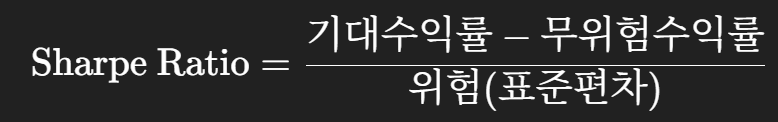

**시뮬레이션에서 샤프지수 계산**

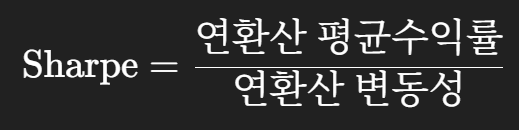

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====[STEP 11] '최적 분산 리츠' 선정 (Sharpe Ratio 기준) (수정본) =====

# 1. port_stats 함수 정의 (Sharpe Ratio 계산 추가, 0~30% 비중)
def port_stats(pf, reit, w_grid=np.linspace(0, 0.3, 31)):
    """
    [수정] 리츠 비중(w)에 따른 포트폴리오의 연환산 수익/위험/샤프지수를 계산
    - 샤프지수 = 연환산수익 / 연환산위험 (무위험수익률 0% 가정)
    """
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx]
    re2 = reit.loc[idx]

    # 0% 비중 (원본 PF)의 성과를 기준으로 저장
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]] # w=0.0 (Baseline)

    # 1% ~ 30% 비중 계산
    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * re2

        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan

        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# 2. 모든 리츠에 대해 시뮬레이션 실행 및 '최적 리츠' 선정
# (이 코드를 실행하기 전에 reits_list, pf_series, ret_wide_reits가 생성되어 있어야 함)
sim_results_all = {}
sharpe_summary = []

for ticker in reits_list:
    # 1. 해당 리츠로 0~30% 시뮬레이션 실행
    sim_df = port_stats(pf_series, ret_wide_reits[ticker])
    sim_results_all[ticker] = sim_df

    # 2. 이 리츠를 섞었을 때 달성 가능한 '최고의 샤프지수'와 '최적 비중' 찾기
    best_sharpe_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]

    # 3. 논문에서 강조한 15% 비중일 때의 샤프지수 확인
    # (np.isclose는 0.15000001 같은 부동소수점 오차를 방지하기 위함)
    sharpe_at_15_row = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = sharpe_at_15_row["sharpe_ratio"].iloc[0] if not sharpe_at_15_row.empty else np.nan

    sharpe_summary.append([
        ticker,
        best_sharpe_row["sharpe_ratio"], # (A) 최고 샤프지수
        best_sharpe_row["w_reit"],       # (B) 최고 샤프지수를 달성한 비중
        sharpe_at_15                     # (C) 15% 비중일 때의 샤프지수
    ])

# 3. '최적 리츠' 선정 결과표 생성
# (이 코드를 실행하기 전에 ticker_to_name_map이 생성되어 있어야 함)
sharpe_summary_table = pd.DataFrame(
    sharpe_summary,
    columns=["ticker", "best_sharpe", "best_w_reit", "sharpe_at_15pct"]
)
sharpe_summary_table["리츠명"] = sharpe_summary_table["ticker"].map(ticker_to_name_map)
sharpe_summary_table = sharpe_summary_table.sort_values("best_sharpe", ascending=False) # 최고 샤프지수 기준 정렬

# '최고의 샤프지수'를 달성한 상위 2개 리츠 선정
best_2_reits_sharpe = sharpe_summary_table.head(2)
sim_tickers = best_2_reits_sharpe["ticker"].tolist()

print("--- [STEP 11] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준) ---")
print("  * 각 리츠를 0~30% 편입 시 달성 가능한 '최고 샤프지수' 기준 정렬")
display(sharpe_summary_table)

print(f"\n→ 최종 시뮬레이션 대상 (종합 1, 2위):")
print(f"  1위: {best_2_reits_sharpe.iloc[0]['리츠명']} (최고 샤프: {best_2_reits_sharpe.iloc[0]['best_sharpe']:.4f} at {best_2_reits_sharpe.iloc[0]['best_w_reit']*100:.0f}%)")
print(f"  2위: {best_2_reits_sharpe.iloc[1]['리츠명']} (최고 샤프: {best_2_reits_sharpe.iloc[1]['best_sharpe']:.4f} at {best_2_reits_sharpe.iloc[1]['best_w_reit']*100:.0f}%)")


# =====[STEP 12] 시각화: (위험) + (수익률) + (샤프지수) 동시 확인 (수정본) =====

print("\n--- [STEP 12] 시뮬레이션 그래프 ---")
for t in sim_tickers:
    sim = sim_results_all[t]
    reit_name = ticker_to_name_map.get(t, t)

    plt.figure(figsize=(15, 4)) # 3개 그래프를 위해 너비 확장

    # 1. [위험(Std) 그래프]
    plt.subplot(1, 3, 1)
    plt.plot(sim["w_reit"], sim["std_annual"], marker="o", c="blue")
    plt.title(f"[{reit_name}] 편입 시 [위험] 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 표준편차 (Risk)")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1, label="15% 비중")
    plt.grid(True)

    # 2. [수익률(Mean) 그래프]
    plt.subplot(1, 3, 2)
    plt.plot(sim["w_reit"], sim["mean_annual"], marker="o", c="green")
    plt.title(f"[{reit_name}] 편입 시 [수익률] 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 평균 수익률 (Return)")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1, label="15% 비중")
    plt.grid(True)

    # 3. 샤프지수(Sharpe)
    plt.subplot(1, 3, 3)
    plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker="o", c="red")
    plt.title(f"[{reit_name}] 편입 시 [Sharpe Ratio] 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("Sharpe Ratio (Return/Risk)")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1, label="15% 비중")
    plt.grid(True)

    plt.tight_layout() # 그래프 간격 자동 조절
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====[STEP 11] 최적 분산 리츠 선정 (Sharpe Ratio 기준, 시나리오 1) =====
# 전제:
# - pf_series        : 시나리오 1의 "주식 5개 균등 PF" 일별 수익률 (STEP 5에서 만든 것)
# - ret_wide_reits   : 리츠 수익률 wide (index=date, columns=ticker, values=ret) (STEP 6)
# - ticker_to_name_map: 리츠 티커 → 이름 매핑 (STEP 5.5)
# - port_stats()     : PF + REIT 혼합 Sharpe 계산 함수 (이미 위에서 정의되어 있음)

sim_results_all = {}
sharpe_summary  = []

for ticker in reits_list:
    # 1) 해당 리츠(ticker)를 0~30% 편입한 시뮬레이션 실행
    sim_df = port_stats(pf_series, ret_wide_reits[ticker])
    sim_results_all[ticker] = sim_df

    # 2) Sharpe Ratio가 최대가 되는 지점 (w_reit*) 찾기
    best_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]

    # 3) 논문에서 강조한 15% 비중에서의 Sharpe 확인
    row_15 = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = row_15["sharpe_ratio"].iloc[0] if not row_15.empty else np.nan

    sharpe_summary.append([
        ticker,
        best_row["sharpe_ratio"],   # (A) 최고 Sharpe
        best_row["w_reit"],         # (B) 그때의 리츠 비중
        sharpe_at_15                # (C) 15% 비중 Sharpe
    ])

# 4) 결과 테이블로 정리
sharpe_summary_table = pd.DataFrame(
    sharpe_summary,
    columns=["ticker", "best_sharpe", "best_w_reit", "sharpe_at_15pct"]
)

# 리츠명 붙이기
sharpe_summary_table["리츠명"] = sharpe_summary_table["ticker"].map(ticker_to_name_map)
sharpe_summary_table = sharpe_summary_table.sort_values("best_sharpe", ascending=False)

print("--- [STEP 11] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준, 시나리오 1) ---")
display(sharpe_summary_table)

print("\n→ 최종 시뮬레이션 대상 (종합 1, 2위):")
display(sharpe_summary_table.head(2))


**-> 기간 전체가 안 좋았는데, 그나마 조합했을 때 피해를 덜 키우는 리츠가 누구인지 확인**

### Sharpe 1위 리츠 vs 리츠 종합지수

In [ ]:
# ===================================================================
# =====[STEP 11.5] 시나리오 1: 주식 PF + (Best 리츠 vs 리츠지수) 비교 =====
# ===================================================================

# 1) Sharpe 기준 1위 리츠 가져오기 (시나리오 1: 기본 주식 PF 기준)
best_reit_ticker_s1 = sharpe_summary_table.iloc[0]["ticker"]
best_reit_name_s1   = sharpe_summary_table.iloc[0]["리츠명"]

print(f"\n[STEP 11.5] 시나리오 1 - Sharpe 기준 1위 리츠: {best_reit_name_s1} ({best_reit_ticker_s1})")

# 2) Best 리츠 수익률 시리즈 (ret_wide_reits에서 가져옴)
best_reit_series_s1 = ret_wide_reits[best_reit_ticker_s1]

# 3) 기본 주식 PF(pf_series)와 공통 기간 맞추기
idx_common_best_s1   = pf_series.index.intersection(best_reit_series_s1.index)
pf_for_best_s1       = pf_series.loc[idx_common_best_s1]
reit_best_for_mix_s1 = best_reit_series_s1.loc[idx_common_best_s1]

# 4) 리츠 종합지수(reit_eq_ret)와 공통 기간
idx_common_idx_s1    = pf_series.index.intersection(reit_eq_ret.index)
pf_for_idx_s1        = pf_series.loc[idx_common_idx_s1]
reit_index_for_mix_s1 = reit_eq_ret.loc[idx_common_idx_s1]

# 5) port_stats로 시뮬레이션
sim_best_s1  = port_stats(pf_for_best_s1,  reit_best_for_mix_s1)
sim_index_s1 = port_stats(pf_for_idx_s1,   reit_index_for_mix_s1)

print("\n[STEP 11.5] 시나리오 1 - Best 리츠 혼합 시뮬레이션 샘플:")
display(sim_best_s1.head())
print("\n[STEP 11.5] 시나리오 1 - 리츠 종합지수 혼합 시뮬레이션 샘플:")
display(sim_index_s1.head())

# 6) 그래프 비교 (위험 / 수익률 / Sharpe)
plt.figure(figsize=(15,4))

# (1) 위험
plt.subplot(1,3,1)
plt.plot(sim_best_s1["w_reit"],  sim_best_s1["std_annual"],  marker="o", label=f"{best_reit_name_s1}")
plt.plot(sim_index_s1["w_reit"], sim_index_s1["std_annual"], marker="x", label="리츠 종합지수")
plt.title("시나리오 1: 위험(Std) 비교\n[주식 5종 균등 PF + 리츠/지수]")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("연환산 표준편차")
plt.grid(True)
plt.legend()

# (2) 수익률
plt.subplot(1,3,2)
plt.plot(sim_best_s1["w_reit"],  sim_best_s1["mean_annual"],  marker="o", label=f"{best_reit_name_s1}")
plt.plot(sim_index_s1["w_reit"], sim_index_s1["mean_annual"], marker="x", label="리츠 종합지수")
plt.title("시나리오 1: 수익률(Mean) 비교")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("연환산 평균 수익률")
plt.grid(True)
plt.legend()

# (3) Sharpe Ratio
plt.subplot(1,3,3)
plt.plot(sim_best_s1["w_reit"],  sim_best_s1["sharpe_ratio"],  marker="o", label=f"{best_reit_name_s1}")
plt.plot(sim_index_s1["w_reit"], sim_index_s1["sharpe_ratio"], marker="x", label="리츠 종합지수")
plt.title("시나리오 1: Sharpe Ratio 비교")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# *참고*

## 삼성전자 단일 종목 + 최적 리츠 1종 vs SK하이닉스 단일 종목 + 최적 리츠 1종

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====[STEP 13] 단일 종목 비교: '삼성전자' vs 'SK하이닉스' (with '에이리츠') =====

print("--- [STEP 13] 단일 종목 비교 분석 (pf_ret + '에이리츠') ---")

# 0. 전제 체크: 필요한 변수들이 있는지 확인
try:
    pf_ret
    ret_wide_reits
    ticker_to_name_map
    port_stats
except NameError as e:
    raise NameError(f"[오류] STEP 13 실행 전 필요한 변수/함수가 정의되어 있어야 합니다: {e}")

# 1. 분석 대상 리츠를 '에이리츠(140910)'로 직접 지정
target_reit_ticker = "140910"
target_reit_name   = ticker_to_name_map.get(target_reit_ticker, "에이리츠")

try:
    # (STEP 6에서 생성된 ret_wide_reits에서 '에이리츠'의 수익률 데이터 가져오기)
    target_reit_series = ret_wide_reits[target_reit_ticker]
    target_reit_series.name = target_reit_ticker
except KeyError:
    raise KeyError(f"[오류] 리츠 수익률 테이블(ret_wide_reits)에 {target_reit_name}({target_reit_ticker})가 없습니다.")

print(f"  * 편입 리츠: [지정 리츠] {target_reit_name} ({target_reit_ticker})")

# 2. pf_ret에서 삼성전자(005930), SK하이닉스(000660) 수익률 시리즈 추출
#    pf_ret는 long 포맷: (date, ticker, price_ret, ...)
samsung_ret_series = None
hynix_ret_series   = None

try:
    samsung_ret_series = (
        pf_ret[pf_ret["ticker"] == "005930"]
        .set_index("date")["price_ret"]
        .sort_index()
    )
    samsung_ret_series.name = "Samsung"
    print("  * '삼성전자' 수익률 시리즈 추출 성공")
except Exception as e:
    print(f"[경고] '삼성전자' 수익률 시리즈를 가져오는 데 실패했습니다: {e}")
    samsung_ret_series = None

try:
    hynix_ret_series = (
        pf_ret[pf_ret["ticker"] == "000660"]
        .set_index("date")["price_ret"]
        .sort_index()
    )
    hynix_ret_series.name = "SK Hynix"
    print("  * 'SK하이닉스' 수익률 시리즈 추출 성공")
except Exception as e:
    print(f"[경고] 'SK하이닉스' 수익률 시리즈를 가져오는 데 실패했습니다: {e}")
    hynix_ret_series = None

# 3. 시뮬레이션 실행 (port_stats 함수는 STEP 11에 정의됨)
sim_results = {}

if samsung_ret_series is not None:
    sim_results["삼성전자"] = port_stats(samsung_ret_series, target_reit_series)

if hynix_ret_series is not None:
    sim_results["SK하이닉스"] = port_stats(hynix_ret_series, target_reit_series)

# 4. 둘 다 없으면 종료
if not sim_results:
    print("[경고] 삼성전자/하이닉스 수익률 시리즈를 찾지 못해 STEP 13을 건너뜁니다.")
else:
    # 5. [위험(Std) 비교 그래프]
    plt.figure(figsize=(14, 3.8))
    if "삼성전자" in sim_results:
        sim = sim_results["삼성전자"]
        plt.plot(sim["w_reit"], sim["std_annual"], marker=".", label=f"삼성전자 + {target_reit_name}")
    if "SK하이닉스" in sim_results:
        sim = sim_results["SK하이닉스"]
        plt.plot(sim["w_reit"], sim["std_annual"], marker=".", label=f"SK하이닉스 + {target_reit_name}")

    plt.title(f"단일 종목 + [{target_reit_name}] 편입 시 [위험] 비교")
    plt.xlabel(f"{target_reit_name} 편입 비중")
    plt.ylabel("연환산 표준편차 (Risk)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 6. [수익률(Mean) 비교 그래프]
    plt.figure(figsize=(14, 3.8))
    if "삼성전자" in sim_results:
        sim = sim_results["삼성전자"]
        plt.plot(sim["w_reit"], sim["mean_annual"], marker=".", label=f"삼성전자 + {target_reit_name}")
    if "SK하이닉스" in sim_results:
        sim = sim_results["SK하이닉스"]
        plt.plot(sim["w_reit"], sim["mean_annual"], marker=".", label=f"SK하이닉스 + {target_reit_name}")

    plt.title(f"단일 종목 + [{target_reit_name}] 편입 시 [수익률] 비교")
    plt.xlabel(f"{target_reit_name} 편입 비중")
    plt.ylabel("연환산 평균 수익률 (Return)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7. [샤프지수(Sharpe) 비교 그래프]
    plt.figure(figsize=(14, 3.8))
    if "삼성전자" in sim_results:
        sim = sim_results["삼성전자"]
        plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker=".", label=f"삼성전자 + {target_reit_name}")
    if "SK하이닉스" in sim_results:
        sim = sim_results["SK하이닉스"]
        plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker=".", label=f"SK하이닉스 + {target_reit_name}")

    plt.title(f"단일 종목 + [{target_reit_name}] 편입 시 [Sharpe Ratio] 비교")
    plt.xlabel(f"{target_reit_name} 편입 비중")
    plt.ylabel("Sharpe Ratio (Return/Risk)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# =====[STEP 14] =====

plt.figure(figsize=(15, 4))  # 전체 사이즈 줄임

# 1) 위험
plt.subplot(1, 3, 1)
if "삼성전자" in sim_results:
    sim = sim_results["삼성전자"]
    plt.plot(sim["w_reit"], sim["std_annual"], marker=".", label="삼성전자")
if "SK하이닉스" in sim_results:
    sim = sim_results["SK하이닉스"]
    plt.plot(sim["w_reit"], sim["std_annual"], marker=".", label="하이닉스")
plt.title("위험(Std) 비교")
plt.xlabel("리츠 비중")
plt.ylabel("연환산 표준편차")
plt.grid(True)
plt.legend()

# 2) 수익률
plt.subplot(1, 3, 2)
if "삼성전자" in sim_results:
    sim = sim_results["삼성전자"]
    plt.plot(sim["w_reit"], sim["mean_annual"], marker=".", label="삼성전자")
if "SK하이닉스" in sim_results:
    sim = sim_results["SK하이닉스"]
    plt.plot(sim["w_reit"], sim["mean_annual"], marker=".", label="하이닉스")
plt.title("수익률(Mean) 비교")
plt.xlabel("리츠 비중")
plt.ylabel("연환산 평균 수익률")
plt.grid(True)
plt.legend()

# 3) Sharpe Ratio
plt.subplot(1, 3, 3)
if "삼성전자" in sim_results:
    sim = sim_results["삼성전자"]
    plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker=".", label="삼성전자")
if "SK하이닉스" in sim_results:
    sim = sim_results["SK하이닉스"]
    plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker=".", label="하이닉스")
plt.title("Sharpe Ratio 비교")
plt.xlabel("리츠 비중")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# **시나리오2**



# 부동산 포트폴리오 + 최적 리츠(샤프 지수)

In [ ]:
# =====[STEP 11-REAL] '최적 분산 리츠' 선정 (Sharpe Ratio 기준, 부동산 PF 기준) =====

sim_results_all_real = {}
sharpe_summary_real = []

for ticker in reits_list_real:
    # 부동산 PF + 개별 리츠 w편입 시 성과
    sim_df = port_stats(pf_real_series_eq, ret_wide_reits_real[ticker])
    sim_results_all_real[ticker] = sim_df

    best_sharpe_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]
    sharpe_at_15_row = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = sharpe_at_15_row["sharpe_ratio"].iloc[0] if not sharpe_at_15_row.empty else np.nan

    sharpe_summary_real.append([
        ticker,
        best_sharpe_row["sharpe_ratio"],
        best_sharpe_row["w_reit"],
        sharpe_at_15
    ])

sharpe_summary_table_real = pd.DataFrame(
    sharpe_summary_real,
    columns=["ticker","best_sharpe","best_w_reit","sharpe_at_15pct"]
)
sharpe_summary_table_real["리츠명"] = sharpe_summary_table_real["ticker"].map(ticker_to_name_map)
sharpe_summary_table_real = sharpe_summary_table_real.sort_values("best_sharpe", ascending=False)

print("\n--- [Scenario 2] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준, 부동산 PF 기준) ---")
display(sharpe_summary_table_real.head())

# 상위 2개 리츠를 시각화 대상 선정
best_2_reits_real = sharpe_summary_table_real.head(2)
sim_tickers_real = best_2_reits_real["ticker"].tolist()

print(f"\n→ [Scenario 2] 최종 시뮬레이션 대상 (상위 2개):")
for i in range(len(best_2_reits_real)):
    row = best_2_reits_real.iloc[i]
    print(f"  {i+1}위: {row['리츠명']} (최고 샤프: {row['best_sharpe']:.4f} at {row['best_w_reit']*100:.0f}%)")


## 부동산 PF 기준 분산 효과(리츠) 1·2위 선정 + 시각화

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====[STEP 11-REAL] 최적 분산 리츠 선정 (Sharpe Ratio 기준, 부동산 PF 기준) =====

sim_results_all_real = {}
sharpe_summary_real  = []

# 부동산 PF 시나리오에서 사용할 리츠 리스트
reits_list_real = ret_wide_reits_real.columns.tolist()

for ticker in reits_list_real:
    # 1) 리츠별 0~30% 편입 시뮬레이션
    sim_df = port_stats(pf_real_series_eq, ret_wide_reits_real[ticker])
    sim_results_all_real[ticker] = sim_df

    # 2) Sharpe Ratio가 최대인 지점
    best_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]

    # 3) 15% 지점 Sharpe 확인
    row_15 = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15 = row_15["sharpe_ratio"].iloc[0] if not row_15.empty else np.nan

    sharpe_summary_real.append([
        ticker,
        best_row["sharpe_ratio"],
        best_row["w_reit"],
        sharpe_at_15
    ])

# 4) 표 생성
sharpe_summary_table_real = pd.DataFrame(
    sharpe_summary_real,
    columns=["ticker", "best_sharpe", "best_w_reit", "sharpe_at_15pct"]
)
sharpe_summary_table_real["리츠명"] = sharpe_summary_table_real["ticker"].map(ticker_to_name_map)
sharpe_summary_table_real = sharpe_summary_table_real.sort_values("best_sharpe", ascending=False)

print("--- [STEP 11-REAL] 최적 분산 리츠 선정 결과 (Sharpe Ratio 기준, 부동산 PF 기준) ---")
display(sharpe_summary_table_real)

print("\n→ 최종 시뮬레이션 대상 (종합 1위, 2위):")
display(sharpe_summary_table_real.head(2))

# =====[STEP 12-REAL] 시각화 (위험 / 수익률 / Sharpe) =====

print("\n--- [STEP 12-REAL] 시뮬레이션 그래프 ---")

# 상위 2개 리츠 선택
best_reits_real = sharpe_summary_table_real.head(2)["ticker"].tolist()

for t in best_reits_real:
    sim = sim_results_all_real[t]
    reit_name = ticker_to_name_map.get(t, t)

    plt.figure(figsize=(15, 4))

    # 1. 위험(Std)
    plt.subplot(1, 3, 1)
    plt.plot(sim["w_reit"], sim["std_annual"], marker="o", c="blue")
    plt.title(f"[{reit_name}] 편입 시 위험 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 표준편차 (Risk)")
    plt.axvline(x=0.15, color='red', linestyle='--')
    plt.grid(True)

    # 2. 수익률(Mean)
    plt.subplot(1, 3, 2)
    plt.plot(sim["w_reit"], sim["mean_annual"], marker="o", c="green")
    plt.title(f"[{reit_name}] 편입 시 수익률 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 평균 수익률 (Return)")
    plt.axvline(x=0.15, color='red', linestyle='--')
    plt.grid(True)

    # 3. Sharpe Ratio
    plt.subplot(1, 3, 3)
    plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker="o", c="red")
    plt.title(f"[{reit_name}] 편입 시 Sharpe Ratio 변화")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("Sharpe Ratio")
    plt.axvline(x=0.15, color='red', linestyle='--')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


## Sharpe 1위 리츠(부동산) vs 리츠 종합지수

In [ ]:
# ===================================================================
# =====[STEP 11-REAL.5] 시나리오 2: 부동산 PF + (Best 리츠 vs 리츠지수) 비교 =====
# ===================================================================

# 1) Sharpe 기준 1위 리츠 (부동산 PF 기준)
best_reit_ticker_s2 = sharpe_summary_table_real.iloc[0]["ticker"]
best_reit_name_s2   = sharpe_summary_table_real.iloc[0]["리츠명"]

print(f"\n[STEP 11-REAL.5] 시나리오 2 - Sharpe 기준 1위 리츠: {best_reit_name_s2} ({best_reit_ticker_s2})")

# 2) 부동산 PF 시나리오에서 사용한 리츠 수익률 wide
#    (ret_wide_reits_real은 STEP 6-REAL에서 생성)
best_reit_series_s2 = ret_wide_reits_real[best_reit_ticker_s2]

# 3) 부동산 PF(pf_real_series_eq)와 Best 리츠의 공통 기간
idx_common_best_s2   = pf_real_series_eq.index.intersection(best_reit_series_s2.index)
pf_real_for_best_s2  = pf_real_series_eq.loc[idx_common_best_s2]
reit_best_for_mix_s2 = best_reit_series_s2.loc[idx_common_best_s2]

# 4) 부동산 PF와 리츠 종합지수(reit_eq_ret)의 공통 기간
#    (reit_eq_ret은 STEP 6.5에서 만든 '기본 리츠 종합지수'를 그대로 사용)
idx_common_idx_s2   = pf_real_series_eq.index.intersection(reit_eq_ret.index)
pf_real_for_idx_s2  = pf_real_series_eq.loc[idx_common_idx_s2]
reit_index_for_mix_s2 = reit_eq_ret.loc[idx_common_idx_s2]

# 5) port_stats로 시뮬레이션: (부동산 PF + Best 리츠) vs (부동산 PF + 리츠지수)
sim_best_s2  = port_stats(pf_real_for_best_s2,  reit_best_for_mix_s2)
sim_index_s2 = port_stats(pf_real_for_idx_s2,   reit_index_for_mix_s2)

print("\n[STEP 11-REAL.5] 시나리오 2 - Best 리츠 혼합 시뮬레이션 샘플:")
display(sim_best_s2.head())
print("\n[STEP 11-REAL.5] 시나리오 2 - 리츠 종합지수 혼합 시뮬레이션 샘플:")
display(sim_index_s2.head())

# 6) 그래프 비교 (위험 / 수익률 / Sharpe)
plt.figure(figsize=(15,4))

# (1) 위험
plt.subplot(1,3,1)
plt.plot(sim_best_s2["w_reit"],  sim_best_s2["std_annual"],  marker="o", label=f"{best_reit_name_s2}")
plt.plot(sim_index_s2["w_reit"], sim_index_s2["std_annual"], marker="x", label="리츠 종합지수")
plt.title("시나리오 2: 위험(Std) 비교\n[부동산 PF + 리츠/지수]")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("연환산 표준편차")
plt.grid(True)
plt.legend()

# (2) 수익률
plt.subplot(1,3,2)
plt.plot(sim_best_s2["w_reit"],  sim_best_s2["mean_annual"],  marker="o", label=f"{best_reit_name_s2}")
plt.plot(sim_index_s2["w_reit"], sim_index_s2["mean_annual"], marker="x", label="리츠 종합지수")
plt.title("시나리오 2: 수익률(Mean) 비교")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("연환산 평균 수익률")
plt.grid(True)
plt.legend()

# (3) Sharpe Ratio
plt.subplot(1,3,3)
plt.plot(sim_best_s2["w_reit"],  sim_best_s2["sharpe_ratio"],  marker="o", label=f"{best_reit_name_s2}")
plt.plot(sim_index_s2["w_reit"], sim_index_s2["sharpe_ratio"], marker="x", label="리츠 종합지수")
plt.title("시나리오 2: Sharpe Ratio 비교")
plt.xlabel("리츠/지수 편입 비중 (w_reit)")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# **시나리오3**

In [ ]:
# =====[STEP 0] yfinance 설치 =====
!pip -q install yfinance

## 코스피&코스닥 지수(비교군)



In [ ]:
# =====[STEP 1] 심볼과 분석 기간 설정 =====
import pandas as pd
import numpy as np
import yfinance as yf

# 기본 심볼
KOSPI_SYMBOL  = "^KS11"
KOSDAQ_SYMBOL = "^KQ11"

# 분석 기간: 네가 이미 만든 데이터(reits_ret/pf_series)가 있다면 그 범위를 따르는 게 좋아요.
# 없으면 임의 기간으로 지정하세요.
try:
    # reits_ret / pf_series가 있으면 공통 기간 기준으로 설정
    min_d = pd.to_datetime(reits_ret["date"]).min()
    max_d = pd.to_datetime(reits_ret["date"]).max()
    START_DATE = (max_d - pd.DateOffset(years=3)).date()  # 최근 3년
    END_DATE   = max_d.date()
except Exception:
    # 없으면 수동 지정
    START_DATE = "2022-01-01"
    END_DATE   = pd.Timestamp.today().date()

START_DATE, END_DATE


In [ ]:
# =====[STEP 2 - FIXED] Yahoo Finance에서 지수 다운로드하고 수익률 계산 =====
import pandas as pd
import numpy as np
import yfinance as yf

def fetch_index_returns_yahoo(symbol, start, end):
    """
    symbol: Yahoo Finance 심볼 (예: ^KS11, ^KQ11)
    start, end: 날짜 (YYYY-MM-DD 또는 date/Timestamp)
    반환: 일별 수익률 Series (index=Timestamp, name=symbol)
    """
    # 문자열로 캐스팅만 확실히
    start = pd.to_datetime(start).date()
    end   = pd.to_datetime(end).date()

    df = yf.download(symbol, start=str(start), end=str(end), auto_adjust=False, progress=False)
    if df.empty:
        raise ValueError(f"{symbol} 다운로드 결과가 비어 있습니다. 심볼/기간을 확인하세요.")

    # 'Adj Close' 우선, 없으면 'Close'
    price_col = "Adj Close" if "Adj Close" in df.columns else "Close"

    # 한 열만 뽑히더라도 간혹 DataFrame으로 남는 경우가 있어 안전 처리
    s = df[price_col].dropna()
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]

    # <-- 여기! rename() 대신 직접 이름 할당
    s.name = symbol

    # 일별 수익률
    ret = s.pct_change().dropna()
    ret.index = pd.to_datetime(ret.index)
    ret.name = symbol
    return ret

# 재시도
kospi_ret  = fetch_index_returns_yahoo(KOSPI_SYMBOL,  START_DATE, END_DATE)
kosdaq_ret = fetch_index_returns_yahoo(KOSDAQ_SYMBOL, START_DATE, END_DATE)

display(kospi_ret.head())
display(kosdaq_ret.head())


In [ ]:
# =====[STEP 3 - optional] 공통 인덱스(교집합) 확인 =====
# reits_ret / pf_series가 준비돼 있다면, 그 인덱스와 교집합을 확인
try:
    # 리츠 wide 수익률 테이블이 있다면:
    reits_idx = ret_wide_reits.index
    common_idx_example = reits_idx.intersection(kospi_ret.index).intersection(kosdaq_ret.index)
    common_idx_example[:5], common_idx_example[-5:]
except Exception as e:
    print("참고: 아직 ret_wide_reits가 없다면 이후 단계에서 자연스레 교집합으로 맞춰집니다.")

In [ ]:
# =====[FIX 1] 안전한 상관계수 계산 유틸 =====
import numpy as np
import pandas as pd

def corr_series_pair_safe(s1: pd.Series, s2: pd.Series, idx: pd.DatetimeIndex):
    """
    s1, s2: 수익률 시계열 (DatetimeIndex)
    idx   : 분석 대상 날짜(윈도우/스트레스 등)
    반환 : 피어슨 상관 (공통 교집합 기준)
    """
    # 1) 각 시리즈-윈도우의 교집합
    i1 = s1.index.intersection(idx)
    i2 = s2.index.intersection(idx)
    # 2) 최종 공통 교집합
    common = i1.intersection(i2)
    if len(common) == 0:
        return np.nan
    s1c = s1.loc[common]
    s2c = s2.loc[common]
    return s1c.corr(s2c)

In [ ]:
# =====[FIX 2] 상관관계 테이블 생성 (safe 함수 사용) =====
def corr_table_vs_indices(
    df_reits_wide: pd.DataFrame,
    pf_series    : pd.Series,
    kospi_ret    : pd.Series,
    kosdaq_ret   : pd.Series,
    stress_quantile: float = 0.80,
    windows: dict | None = None
):
    """
    df_reits_wide: 리츠 수익률 wide (index=date, columns=ticker)
    pf_series    : PF 일수익률
    kospi_ret    : KOSPI 수익률
    kosdaq_ret   : KOSDAQ 수익률
    stress_quantile: |PF| 상위 퍼센트 기준(0.8 => 상위20% 스트레스일)
    windows      : {'라벨': (start_ts, end_ts), ...}
    """
    results = {}

    full_idx = df_reits_wide.index
    abs_pf   = pf_series.loc[full_idx].abs()
    thr      = abs_pf.quantile(stress_quantile)
    stress_idx = abs_pf[abs_pf >= thr].index
    calm_idx   = abs_pf[abs_pf <  thr].index

    def build_corr_block(idx: pd.DatetimeIndex, label: str):
        rows = []
        for t in df_reits_wide.columns:
            r = df_reits_wide[t]
            rows.append([
                t,
                corr_series_pair_safe(r, kospi_ret,  idx),
                corr_series_pair_safe(r, kosdaq_ret, idx),
                corr_series_pair_safe(r, pf_series,  idx),
            ])
        out = (pd.DataFrame(rows, columns=["ticker","corr_kospi","corr_kosdaq","corr_pf"])
                 .set_index("ticker")
                 .sort_values("corr_kospi"))
        results[label] = out

    build_corr_block(full_idx,   "full")
    build_corr_block(stress_idx, "stress")
    build_corr_block(calm_idx,   "calm")

    if windows:
        for label, (s, e) in windows.items():
            # 윈도우가 실제 리츠 인덱스에 없는 날짜를 포함해도 안전하게 필터링
            s = pd.to_datetime(s)
            e = pd.to_datetime(e)
            idx = full_idx[(full_idx >= s) & (full_idx <= e)]
            build_corr_block(idx, f"window_{label}")

    return results

### 리츠 - 연도별 KOSPI, KOSDAQ, PF의 상관관계

In [ ]:
# 1. 구간 정의 (연도별 3개 window로 변경)
print("---  상관관계 분석 실행 ---")

full_min, full_max = ret_wide_reits.index.min(), ret_wide_reits.index.max()

# 리츠 수익률 데이터에 실제로 존재하는 연도만 추출
years = sorted(set(ret_wide_reits.index.year))

windows = {}
for y in years:
    # 해당 연도의 이론적 시작/끝
    start = pd.Timestamp(f"{y}-01-01")
    end   = pd.Timestamp(f"{y}-12-31")

    # 실제 데이터 기간과 겹치는 부분으로 잘라주기
    start = max(start, full_min)
    end   = min(end, full_max)

    # 겹치는 구간이 존재할 때만 window로 채택
    if start <= end:
        windows[str(y)] = (start, end)

print("생성된 연도별 window:")
for label, (s, e) in windows.items():
    print(f"  {label}: {s.date()} ~ {e.date()}")

# 2. 상관관계 계산 (기존과 동일)
corr_results = corr_table_vs_indices(
    df_reits_wide   = ret_wide_reits,
    pf_series       = pf_series,
    kospi_ret       = kospi_ret,
    kosdaq_ret      = kosdaq_ret,
    stress_quantile = 0.80,
    windows         = windows
)

# 3. [!!! 수정된 부분 !!!] 결과 테이블(DataFrame)에 '리츠명' 열 추가
try:
    for label, df in corr_results.items():
        # 1. 인덱스(ticker)를 사용해 '리츠명' 열 추가
        df_with_name = df.copy()  # 원본 수정을 피하기 위해 복사
        df_with_name["리츠명"] = df_with_name.index.map(ticker_to_name_map)

        # 2. 인덱스를 리셋하고 'ticker', '리츠명'을 멀티인덱스로 설정
        df_reset = df_with_name.reset_index().rename(columns={"index": "ticker"})

        # 3. 'ticker', '리츠명'이 컬럼에 있는지 확인 후 인덱스 설정
        cols = list(df_reset.columns)
        other_cols = [c for c in cols if c not in ["ticker", "리츠명"]]
        new_order = ["ticker", "리츠명"] + other_cols
        df_final = df_reset[new_order].set_index(["ticker", "리츠명"])

        # 4. 딕셔너리의 기존 DataFrame을 새 DataFrame으로 교체
        corr_results[label] = df_final

    print("[성공] 상관관계 테이블에 '리츠명'이 추가되었습니다.")

except NameError:
    print("[경고] 'ticker_to_name_map'이 정의되지 않았습니다. [STEP 5.5]를 먼저 실행하세요.")
except Exception as e:
    print(f"[오류] 리츠명 매핑 중 오류 발생: {e}")

# 4. 수정된 결과 출력 (기존과 동일)
print("\n[전체 구간] 리츠-지수 상관관계:")
display(corr_results["full"].head())

print("[스트레스 구간] 리츠-지수 상관관계:")
display(corr_results["stress"].head())

print("[비스트레스 구간] 리츠-지수 상관관계:")
display(corr_results["calm"].head())

# windows는 corr_table_vs_indices 내부에서 'window_연도' 형태로 저장됨
for k in corr_results:
    if k.startswith("window_"):
        print(f"[{k}] 리츠-지수 상관관계:")
        display(corr_results[k].head())


**시각화**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. window_* 만 골라오기
# (corr_results는 이전 단계인 STEP 10에서 생성되었다고 가정합니다)
year_windows = {k: v for k, v in corr_results.items() if k.startswith("window_")}

# 2. 코스피(KOSPI) 상관관계만 모으기
heatmap_kospi_df = pd.DataFrame()

for label, df in year_windows.items():
    year = label.replace("window_", "")

    # [수정] df index는 MultiIndex(ticker, 리츠명)라고 가정합니다.
    if "corr_kospi" in df.columns:
        col = df["corr_kospi"]
        col.name = year
        heatmap_kospi_df = pd.concat([heatmap_kospi_df, col], axis=1)

# 3. 이름 기준으로 정렬 (리츠명 기준)
try:
    heatmap_kospi_df = heatmap_kospi_df.sort_index(level="리츠명")
except:
    heatmap_kospi_df = heatmap_kospi_df.sort_index() # 레벨 없으면 그냥 정렬

# 4. 히트맵 시각화
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_kospi_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
# annot=True: 숫자 표시, fmt=".2f": 소수점 2자리까지

plt.title("연도별 리츠–KOSPI 상관관계 (Heatmap)", fontsize=15)
plt.xlabel("연도", fontsize=12)
plt.ylabel("리츠명", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. window_* 만 골라오기
# (corr_results는 이전 단계인 STEP 10에서 생성되었다고 가정합니다)
year_windows = {k: v for k, v in corr_results.items() if k.startswith("window_")}

# 2. 코스닥(KOSDAQ) 상관관계만 모으기
heatmap_kosdaq_df = pd.DataFrame()

for label, df in year_windows.items():
    year = label.replace("window_", "")

    # [수정] corr_kospi 대신 'corr_kosdaq' 컬럼을 선택합니다.
    # df index는 MultiIndex(ticker, 리츠명)라고 가정합니다.
    if "corr_kosdaq" in df.columns:
        col = df["corr_kosdaq"]
        col.name = year
        heatmap_kosdaq_df = pd.concat([heatmap_kosdaq_df, col], axis=1)

# 3. 이름 기준으로 정렬 (리츠명 기준)
# 인덱스가 (ticker, 리츠명)인 경우 레벨 1(리츠명) 기준으로 정렬하면 보기 좋습니다.
try:
    heatmap_kosdaq_df = heatmap_kosdaq_df.sort_index(level="리츠명")
except:
    heatmap_kosdaq_df = heatmap_kosdaq_df.sort_index() # 레벨 없으면 그냥 정렬

# 4. 히트맵 시각화
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_kosdaq_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
# annot=True: 숫자 표시, fmt=".2f": 소수점 2자리까지

plt.title("연도별 리츠–KOSDAQ 상관관계 (Heatmap)", fontsize=15)
plt.xlabel("연도", fontsize=12)
plt.ylabel("리츠명", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ======================================================================
# [시각화] 연도별 [리츠 ↔ 내 포트폴리오(PF)] 상관관계 히트맵
# ======================================================================

# 1. 연도별 데이터 추출 및 병합
heatmap_pf_df = pd.DataFrame()

# corr_results 딕셔너리에서 'window_'로 시작하는(연도별) 데이터만 꺼냄
for label, df in corr_results.items():
    if label.startswith("window_"):
        year = label.replace("window_", "") # 'window_2022' -> '2022'

        # 'corr_pf' (포트폴리오 상관관계) 컬럼만 선택
        if "corr_pf" in df.columns:
            # '리츠명' 레벨을 직접 가져와 Series의 인덱스로 사용
            col_series = pd.Series(df["corr_pf"].values, index=df.index.get_level_values('리츠명'))
            col_series.name = year # 컬럼 이름을 연도로 변경
            heatmap_pf_df = pd.concat([heatmap_pf_df, col_series], axis=1)

# 2. 리츠명 매핑 및 정렬
# (이제 heatmap_pf_df의 인덱스는 이미 '리츠명'이므로 추가 get_level_values 호출 불필요)
if not heatmap_pf_df.empty:
    # 이름순으로 정렬 (보기 좋게)
    heatmap_pf_df = heatmap_pf_df.sort_index()

    # 3. 히트맵 시각화
    plt.figure(figsize=(8, 5)) # 그래프 크기 설정

    # sns.heatmap: 히트맵 그리기
    # - annot=True: 칸 안에 숫자 표시
    # - fmt=".2f": 소수점 2자리까지 표시
    # - cmap="coolwarm": 파란색(낮음/좋음) ~ 빨간색(높음/나쁨) 색상 적용
    # - center=0: 0을 기준으로 색상 나눔 (0보다 작으면 파랑, 크면 빨강)
    sns.heatmap(heatmap_pf_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-0.5, vmax=1.0)

    plt.title("연도별 [리츠 ↔ 내 포트폴리오(PF)] 상관관계", fontsize=15, pad=20)
    plt.xlabel("연도", fontsize=12)
    plt.ylabel("리츠명", fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("[경고] 연도별(window_) 데이터가 없습니다. STEP 10에서 windows 설정을 확인하세요.")

In [ ]:
import matplotlib.pyplot as plt

target = "330590"  # 예: 롯데리츠 티커

years = []
corr_kospi = []
corr_kosdaq = []

for label, df in year_windows.items():
    year = label.replace("window_", "")
    years.append(year)

    # df index: (ticker, 리츠명)
    try:
        corr_kospi.append(df.loc[(target,), "corr_kospi"])
        corr_kosdaq.append(df.loc[(target,), "corr_kosdaq"])
    except:
        corr_kospi.append(None)
        corr_kosdaq.append(None)

plt.figure(figsize=(8,5))
plt.plot(years, corr_kospi, marker='o', label="KOSPI 상관")
plt.plot(years, corr_kosdaq, marker='o', label="KOSDAQ 상관")

plt.title(f"{target} 연도별 상관관계 변화")
plt.xlabel("연도")
plt.ylabel("상관계수")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 1. 매핑 딕셔너리 다시 정의 (확실하게 하기 위해)
ticker_list = [
    "404990 신한서부티엔디리츠", "396690 미래에셋글로벌리츠", "400760 NH올원리츠",
    "395400 SK리츠", "377190 디앤디플랫폼리츠", "365550 ESR켄달스퀘어리츠",
    "357120 코람코라이프인프라리츠", "357250 미래에셋맵스리츠", "348950 제이알글로벌리츠",
    "350520 이지스레지던스리츠", "334890 이지스밸류플러스리츠", "338100 NH프라임리츠",
    "330590 롯데리츠", "293940 신한알파리츠", "204210 스타에스엠리츠",
    "088260 이리츠코크렙", "145270 케이탑리츠", "140910 에이리츠"
]
ticker_to_name_map = {x.split(" ")[0]: " ".join(x.split(" ")[1:]) for x in ticker_list}

# ======================================================================
# [시각화 1] 평상시(Full) vs 위기시(Stress) 상관관계 산점도 (수정본)
# ======================================================================

# 데이터 준비
df_scatter = corr_results["full"][["corr_pf"]].rename(columns={"corr_pf": "Full"})
df_scatter = df_scatter.join(corr_results["stress"][["corr_pf"]].rename(columns={"corr_pf": "Stress"}))

# [수정] 리츠명 매핑 (안전장치 추가)
# df_scatter.index는 MultiIndex (ticker, 리츠명)이므로, '리츠명' 레벨 값을 직접 사용
df_scatter["Name"] = df_scatter.index.get_level_values('리츠명')

plt.figure(figsize=(10, 8))

# 산점도 그리기
sns.scatterplot(data=df_scatter, x="Full", y="Stress", s=100, color='blue', alpha=0.7)

# 기준선 (y=x)
min_val = min(df_scatter["Full"].min(), df_scatter["Stress"].min()) - 0.1
max_val = max(df_scatter["Full"].max(), df_scatter["Stress"].max()) + 0.1
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='변화 없음 (y=x)')

# 텍스트 표시
for i, row in df_scatter.iterrows():
    plt.text(row["Full"]+0.01, row["Stress"], str(row["Name"]), fontsize=9)

plt.title("포트폴리오와의 상관관계: 평상시(Full) vs 위기시(Stress)", fontsize=15)
plt.xlabel("평상시 상관관계 (Full Period)", fontsize=12)
plt.ylabel("위기시 상관관계 (Stress Period)", fontsize=12)
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## KOSPI 상위 50개 종목 최대 샤프지수 포트폴리오

In [ ]:
# ===================================================================
# =====[STEP 15] KOSPI 대형주 50개 + Max Sharpe 최적 포트폴리오 =====
# ===================================================================

# 15-1. KOSPI 대형주 50개 (KOSPI100 스타일 바스켓)
kospi100_krx = [
    "005930", "000660", "207940", "373220", "006400", "051910", "035420", "035720", "005380", "000270",
    "028260", "055550", "105560", "086790", "004020", "010130", "000810", "012330", "066570", "017670",
    "034730", "096770", "032830", "011170", "051900", "090430", "003550", "015760", "010950", "003490",
    "011200", "005940", "000880", "009150", "000120", "034220", "001040", "006360", "078930", "000990",
    "030200", "024110", "016360", "086280", "010140", "047810", "267250", "021240", "033780", "032640"
]

# [!!! 추가됨 !!!] KOSPI 50개 이름 매핑
kospi100_map = {
    "005930": "삼성전자", "000660": "SK하이닉스", "207940": "삼성바이오로직스",
    "373220": "LG에너지솔루션", "006400": "삼성SDI", "051910": "LG화학",
    "035420": "NAVER", "035720": "카카오", "005380": "현대차",
    "000270": "기아", "028260": "삼성물산", "055550": "신한지주",
    "105560": "KB금융", "086790": "하나금융지주", "004020": "현대제철",
    "010130": "고려아연", "000810": "삼성화재", "012330": "현대모비스",
    "066570": "LG전자", "017670": "SK텔레콤", "034730": "SK",
    "096770": "SK이노베이션", "032830": "삼성생명", "011170": "롯데케미칼",
    "051900": "LG생활건강", "090430": "아모레퍼시픽", "003550": "LG",
    "015760": "한국전력", "010950": "S-Oil", "003490": "대한항공",
    "011200": "HMM", "005940": "NH투자증권", "000880": "한화",
    "009150": "삼성전기", "000120": "CJ대한통운", "034220": "LG디스플레이",
    "001040": "CJ", "006360": "GS건설", "078930": "GS",
    "000990": "DB하이텍", "030200": "KT", "024110": "기업은행",
    "016360": "삼성증권", "086280": "현대글로비스", "010140": "삼성중공업",
    "047810": "한국항공우주", "267250": "현대중공업지주", "021240": "코웨이",
    "033780": "KT&G", "032640": "LG유플러스"
}

kospi100_yahoo = [code + ".KS" for code in kospi100_krx]

print("\n[STEP 15] KOSPI 대형주 50개 (KOSPI100 스타일) 심볼 개수:", len(kospi100_yahoo))
print(kospi100_yahoo[:10])

# 15-2. 기간 설정
reits_dates = pd.to_datetime(reits_ret["date"].unique())
end_date_k100 = reits_dates.max().date()
start_date_k100 = (reits_dates.max() - pd.DateOffset(years=3)).date()
print("KOSPI 대형주 데이터 수집 기간:", start_date_k100, "~", end_date_k100)

# 15-3. yfinance에서 가격 다운로드
k100_price = yf.download(
    kospi100_yahoo,
    start=str(start_date_k100),
    end=str(end_date_k100),
    auto_adjust=False,
    progress=False
)

if isinstance(k100_price.columns, pd.MultiIndex):
    if "Adj Close" in k100_price.columns.get_level_values(0):
        k100_price = k100_price["Adj Close"]
    else:
        k100_price = k100_price["Close"]
else:
    if "Adj Close" in k100_price.columns:
        k100_price = k100_price[["Adj Close"]]
    elif "Close" in k100_price.columns:
        k100_price = k100_price[["Close"]]
    else:
        raise ValueError("다운로드한 데이터에 'Adj Close'나 'Close'가 없습니다.")

valid_cols = k100_price.columns[k100_price.notna().sum() > 200]
k100_price = k100_price[valid_cols]

print("\n[STEP 15] KOSPI 대형주 가격 데이터 (전처리 후) 샘플:")
display(k100_price.iloc[:5, :5])

# 15-4. 일별 수익률 계산
k100_ret = k100_price.pct_change().dropna(how="all")
new_cols = [c.replace(".KS", "") for c in k100_ret.columns]
k100_ret_krx = k100_ret.copy()
k100_ret_krx.columns = new_cols

print("\n[STEP 15] KOSPI 대형주 일별 수익률(k100_ret_krx) 샘플:")
display(k100_ret_krx.iloc[:5, :5])


# 15-5. Max Sharpe 최적 가중치 함수 정의
import scipy.optimize as sco

def portfolio_performance(w, mean_ret, cov_mat):
    port_ret = np.dot(w, mean_ret)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    return port_ret, port_vol

def neg_sharpe(w, mean_ret, cov_mat, rf=0.0):
    port_ret, port_vol = portfolio_performance(w, mean_ret, cov_mat)
    if port_vol == 0:
        return 0
    return -(port_ret - rf) / port_vol

def get_max_sharpe_weights(ret_df, rf=0.0):
    rets = ret_df.dropna(how="all")
    rets = rets.loc[:, rets.notna().sum() > 0]

    mean_daily = rets.mean()
    mean_annual = mean_daily * 252
    cov_daily = rets.cov()
    cov_annual = cov_daily * 252

    n = len(mean_annual)
    init_w = np.repeat(1/n, n)
    bounds = tuple((0.0, 1.0) for _ in range(n))
    cons   = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)

    res = sco.minimize(
        neg_sharpe,
        init_w,
        args=(mean_annual.values, cov_annual.values, rf),
        method="SLSQP",
        bounds=bounds,
        constraints=cons
    )

    if not res.success:
        print("[경고] KOSPI 대형주 포트폴리오 최적화 실패, 균등비중 사용:", res.message)
        w_opt = init_w
    else:
        w_opt = res.x

    return pd.Series(w_opt, index=mean_annual.index, name="w_opt")

# 15-6. Max Sharpe 가중치 + 최적 포트폴리오 수익률
w_opt_k100 = get_max_sharpe_weights(k100_ret_krx, rf=0.0)

# [!!! 수정된 부분 !!!] 결과표에 종목명 추가
w_opt_df = w_opt_k100.to_frame("weight")
w_opt_df["종목명"] = w_opt_df.index.map(kospi100_map)

# 가중치가 0.1% 이상인 종목만 필터링해서 보여주기 (너무 작은 비중 제외)
w_opt_df_show = w_opt_df[w_opt_df["weight"] > 0.001].sort_values("weight", ascending=False)

print("\n[STEP 15] KOSPI 대형주 Max Sharpe 최적 비중 (상위 종목):")
display(w_opt_df_show)

pf_k100_opt_series = (k100_ret_krx * w_opt_k100).sum(axis=1)
pf_k100_opt_series.name = "pf_k100_opt"

pf_k100_opt_lag1 = pf_k100_opt_series.shift(1)

print("\n[STEP 15] KOSPI 대형주 Max Sharpe PF 수익률 샘플:")
display(pf_k100_opt_series.head())

### 최적 KOSPI PF + 최적 리츠

In [ ]:
# =====[STEP 16] 최적 KOSPI PF + 개별 리츠 : GARCH-M, 상관관계, Sharpe =====

# 16-1. 리츠 수익률(ret_wide_reits)과 KOSPI 최적 PF 공통 기간 맞추기
common_idx_k100 = ret_wide_reits.index.intersection(pf_k100_opt_lag1.dropna().index)
ret_wide_reits_k100 = ret_wide_reits.loc[common_idx_k100]
pf_k100_opt_series  = pf_k100_opt_series.loc[common_idx_k100]
pf_k100_opt_lag1    = pf_k100_opt_lag1.loc[common_idx_k100]

reits_list_k100 = ret_wide_reits_k100.columns.tolist()

print(f"\n[STEP 16] 최적 KOSPI PF 기준 리츠 종목 수: {len(reits_list_k100)}")
print("공통 기간:", common_idx_k100.min().date(), "~", common_idx_k100.max().date())

# 16-2. GARCH-M In-Mean 회귀 (r_reit,t = α + β r_PF,t-1 + δ σ_t + ε_t)
rows_k100 = []
sigma_cache_k100 = {}

for t in reits_list_k100:
    r = ret_wide_reits_k100[t]

    if t not in sigma_cache_k100:
        sigma_cache_k100[t] = sigma_engine(r, prefer="garch")

    sigma_t = sigma_cache_k100[t]
    res     = inmean_regression(r, pf_k100_opt_lag1, sigma_t)

    rows_k100.append([
        t,
        res.params.get("r_pf_lag1", np.nan),
        res.tvalues.get("r_pf_lag1", np.nan),
        res.pvalues.get("r_pf_lag1", np.nan),
        res.params.get("sigma_t", np.nan),
        res.tvalues.get("sigma_t", np.nan),
        res.pvalues.get("sigma_t", np.nan),
        res.rsquared
    ])

beta_table_k100 = pd.DataFrame(
    rows_k100,
    columns=["ticker","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
)
beta_table_k100["리츠명"] = beta_table_k100["ticker"].map(ticker_to_name_map)
beta_table_k100 = beta_table_k100[
    ["ticker","리츠명","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
].sort_values("beta")

print("\n[STEP 16] KOSPI 최적 PF 기준 GARCH-M In-Mean 회귀 결과 (β 오름차순):")
display(beta_table_k100.head())

# 16-3. 상관관계 (전체 vs 스트레스)
abs_pf_k100 = pf_k100_opt_series.abs()
thr_k100    = abs_pf_k100.quantile(0.80)
stress_idx_k100 = abs_pf_k100[abs_pf_k100 >= thr_k100].index
full_idx_k100   = ret_wide_reits_k100.index

def corr_against_pf_k100(df_reits, base_series, idx):
    out = {}
    base = base_series.loc[idx]
    for t in df_reits.columns:
        out[t] = df_reits[t].loc[idx].corr(base)
    return pd.Series(out, name="corr")

corr_full_k100   = corr_against_pf_k100(ret_wide_reits_k100, pf_k100_opt_series, full_idx_k100)
corr_stress_k100 = corr_against_pf_k100(ret_wide_reits_k100, pf_k100_opt_series, stress_idx_k100)

correlation_table_k100 = pd.concat([corr_full_k100, corr_stress_k100], axis=1)
correlation_table_k100.columns = ["corr_full", "corr_stress"]
correlation_table_k100["리츠명"] = correlation_table_k100.index.map(ticker_to_name_map)
correlation_table_k100 = correlation_table_k100.reset_index().rename(columns={"index":"ticker"})
correlation_table_k100 = correlation_table_k100[
    ["ticker","리츠명","corr_full","corr_stress"]
].set_index("ticker").sort_values("corr_full")

print("\n[STEP 16] KOSPI 최적 PF 기준 상관관계 (전체 vs 스트레스):")
display(correlation_table_k100.head())

# 16-4. Sharpe 기준 '최적 리츠' 선정 (0~30% 편입)
sim_results_all_k100 = {}
sharpe_summary_k100  = []

for ticker in reits_list_k100:
    sim_df = port_stats(pf_k100_opt_series, ret_wide_reits_k100[ticker])
    sim_results_all_k100[ticker] = sim_df

    best_row = sim_df.loc[sim_df["sharpe_ratio"].idxmax()]
    sharpe_at_15_r = sim_df[np.isclose(sim_df["w_reit"], 0.15)]
    sharpe_at_15   = sharpe_at_15_r["sharpe_ratio"].iloc[0] if not sharpe_at_15_r.empty else np.nan

    sharpe_summary_k100.append([
        ticker,
        best_row["sharpe_ratio"],
        best_row["w_reit"],
        sharpe_at_15
    ])

sharpe_summary_table_k100 = pd.DataFrame(
    sharpe_summary_k100,
    columns=["ticker","best_sharpe","best_w_reit","sharpe_at_15pct"]
)
sharpe_summary_table_k100["리츠명"] = sharpe_summary_table_k100["ticker"].map(ticker_to_name_map)
sharpe_summary_table_k100 = sharpe_summary_table_k100.sort_values("best_sharpe", ascending=False)

print("\n[STEP 16] KOSPI 최적 PF 기준 Sharpe 기준 최적 리츠:")
display(sharpe_summary_table_k100.head())

best_2_reits_k100 = sharpe_summary_table_k100.head(2)
sim_tickers_k100  = best_2_reits_k100["ticker"].tolist()

print("\n→ [STEP 16] 시뮬레이션 대상 (상위 2개 리츠):")
for i in range(len(best_2_reits_k100)):
    row = best_2_reits_k100.iloc[i]
    print(f"  {i+1}위: {row['리츠명']} (최고 Sharpe: {row['best_sharpe']:.4f} at {row['best_w_reit']*100:.0f}%)")

# 16-5. 시각화 (위험 / 수익률 / Sharpe)
print("\n--- [STEP 16] KOSPI 최적 PF + 리츠 시뮬레이션 그래프 ---")
for t in sim_tickers_k100:
    sim = sim_results_all_k100[t]
    reit_name = ticker_to_name_map.get(t, t)

    plt.figure(figsize=(15,4))

    # 위험
    plt.subplot(1,3,1)
    plt.plot(sim["w_reit"], sim["std_annual"], marker="o")
    plt.title(f"[{reit_name}] 편입 시 위험 변화 (KOSPI 최적 PF 기준)")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 표준편차")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1)
    plt.grid(True)

    # 수익률
    plt.subplot(1,3,2)
    plt.plot(sim["w_reit"], sim["mean_annual"], marker="o")
    plt.title(f"[{reit_name}] 편입 시 수익률 변화 (KOSPI 최적 PF 기준)")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("연환산 평균 수익률")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1)
    plt.grid(True)

    # Sharpe
    plt.subplot(1,3,3)
    plt.plot(sim["w_reit"], sim["sharpe_ratio"], marker="o")
    plt.title(f"[{reit_name}] 편입 시 Sharpe Ratio 변화 (KOSPI 최적 PF 기준)")
    plt.xlabel("리츠 편입 비중 (w_reit)")
    plt.ylabel("Sharpe Ratio")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1)
    plt.grid(True)

    plt.tight_layout()
    plt.show()


### 최적 리츠 Vs 리츠 종합지수

In [ ]:

# =====[STEP 17] Best REIT vs 리츠 종합지수(REIT_EQ_TR_RET) 비교 =====

# 17-1. Best REIT (Sharpe 기준 1위, KOSPI 최적 PF 기준)
best_reit_ticker_k100 = sharpe_summary_table_k100.iloc[0]["ticker"]
best_reit_name_k100   = sharpe_summary_table_k100.iloc[0]["리츠명"]
best_reit_series_all  = ret_wide_reits_k100[best_reit_ticker_k100]

print(f"\n[STEP 17] Sharpe 기준 1위 리츠: {best_reit_name_k100} ({best_reit_ticker_k100})")

# 17-2. KOSPI 최적 PF + Best REIT 혼합 (공통 기간 정렬)
idx_common_best  = pf_k100_opt_series.index.intersection(best_reit_series_all.index)
pf_k100_for_best = pf_k100_opt_series.loc[idx_common_best]
best_reit_for_mix = best_reit_series_all.loc[idx_common_best]

sim_best = port_stats(pf_k100_for_best, best_reit_for_mix)

# 17-3. KOSPI 최적 PF + 리츠 종합지수(reit_eq_ret) 혼합
idx_common_idx = pf_k100_opt_series.index.intersection(reit_eq_ret.index)
pf_k100_for_idx   = pf_k100_opt_series.loc[idx_common_idx]
reit_index_series = reit_eq_ret.loc[idx_common_idx]

sim_index = port_stats(pf_k100_for_idx, reit_index_series)

print("\n[STEP 17] Best REIT 혼합 시뮬레이션 샘플:")
display(sim_best.head())
print("\n[STEP 17] REIT 종합지수 혼합 시뮬레이션 샘플:")
display(sim_index.head())

# 17-4. 그래프로 비교 (위험 / 수익률 / Sharpe)
plt.figure(figsize=(15,4))

# 위험
plt.subplot(1,3,1)
plt.plot(sim_best["w_reit"],  sim_best["std_annual"],  marker="o", label=f"{best_reit_name_k100}")
plt.plot(sim_index["w_reit"], sim_index["std_annual"], marker="x", label="REIT 종합지수")
plt.title("위험(Std) 비교: Best REIT vs REIT 종합지수")
plt.xlabel("편입 비중 (w_reit)")
plt.ylabel("연환산 표준편차")
plt.grid(True)
plt.legend()

# 수익률
plt.subplot(1,3,2)
plt.plot(sim_best["w_reit"],  sim_best["mean_annual"],  marker="o", label=f"{best_reit_name_k100}")
plt.plot(sim_index["w_reit"], sim_index["mean_annual"], marker="x", label="REIT 종합지수")
plt.title("수익률(Mean) 비교: Best REIT vs REIT 종합지수")
plt.xlabel("편입 비중 (w_reit)")
plt.ylabel("연환산 평균 수익률")
plt.grid(True)
plt.legend()

# Sharpe
plt.subplot(1,3,3)
plt.plot(sim_best["w_reit"],  sim_best["sharpe_ratio"],  marker="o", label=f"{best_reit_name_k100}")
plt.plot(sim_index["w_reit"], sim_index["sharpe_ratio"], marker="x", label="REIT 종합지수")
plt.title("Sharpe Ratio 비교: Best REIT vs REIT 종합지수")
plt.xlabel("편입 비중 (w_reit)")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# 지표 및 시각화 정리

**KOSPI 100 지수 구성 종목들 포트폴리오 최적화 다시**
---

In [ ]:
import pandas as pd

# 1. 기존 파일 읽기 (한국 CSV는 대부분 euc-kr 또는 cp949)
df = pd.read_csv("kospi100_list_6digit.csv", dtype=str, encoding="utf-8-sig")
# df = pd.read_csv("kospi100_list.csv", dtype=str, encoding="euc-kr")  # 대체 옵션

# 2. 첫 번째 컬럼이 티커라고 가정
ticker_col = df.columns[0]

# 3. 숫자만 추출해서 6자리로 변환
df[ticker_col] = (
    df[ticker_col]
      .astype(str)
      .str.extract(r"(\d+)")[0]
      .str.zfill(6)
)

# 4. 새 파일로 저장 (CSV + XLSX)
df.to_csv("kospi100_list_6digit.csv", index=False, encoding="utf-8-sig")
df.to_excel("kospi100_list_6digit.xlsx", index=False)

print("완료! kospi100_list_6digit.csv / .xlsx 저장됨.")

In [ ]:
def load_kospi100_codes(path="kospi100_list_6digit.csv"):
    """
    6자리로 정리된 kospi100_list_6digit.csv에서
    KRX 코드 리스트를 읽어온다.
    """
    import pandas as pd

    df = pd.read_csv(path, dtype=str, encoding="utf-8-sig")
    # 첫 컬럼이 티커라고 가정
    ticker_col = df.columns[0]

    codes = (
        df[ticker_col]
        .astype(str)
        .str.strip()
        .str.zfill(6)
        .tolist()
    )

    # 공백/중복 제거
    codes = [c for c in codes if c != ""]
    codes = sorted(set(codes))

    print(f"[STEP 15] 로드한 KOSPI100 코드 개수: {len(codes)}")
    return codes


In [ ]:
kospi100_krx = load_kospi100_codes("kospi100_list_6digit.csv")
kospi100_yahoo = [code + ".KS" for code in kospi100_krx]

In [ ]:
import yfinance as yf
import numpy as np
import scipy.optimize as sco

# 15-2. 기간 설정: 리츠 데이터 기준 최근 3년
reits_dates = pd.to_datetime(reits_ret["date"].unique())
end_date_k100 = reits_dates.max().date()
start_date_k100 = (reits_dates.max() - pd.DateOffset(years=3)).date()
print("KOSPI100 데이터 수집 기간:", start_date_k100, "~", end_date_k100)

# 15-3. yfinance에서 가격 다운로드 (Adj Close 우선)
k100_price_raw = yf.download(
    kospi100_yahoo,
    start=str(start_date_k100),
    end=str(end_date_k100),
    auto_adjust=False,
    progress=False
)

if isinstance(k100_price_raw.columns, pd.MultiIndex):
    if "Adj Close" in k100_price_raw.columns.get_level_values(0):
        k100_price = k100_price_raw["Adj Close"]
    else:
        k100_price = k100_price_raw["Close"]
else:
    if "Adj Close" in k100_price_raw.columns:
        k100_price = k100_price_raw[["Adj Close"]]
    elif "Close" in k100_price_raw.columns:
        k100_price = k100_price_raw[["Close"]]
    else:
        raise ValueError("다운로드한 데이터에 'Adj Close'나 'Close'가 없습니다.")

# NaN이 너무 많은 종목 제거 (상장/상폐 이슈 등)
valid_cols = k100_price.columns[k100_price.notna().sum() > 200]
k100_price = k100_price[valid_cols]

print("\n[STEP 15] KOSPI100 가격 데이터 (전처리 후) 샘플:")
display(k100_price.iloc[:5, :5])

# 15-4. 일별 수익률 계산 & .KS 제거
k100_ret = k100_price.pct_change().dropna(how="all")

new_cols = [c.replace(".KS", "") for c in k100_ret.columns]
k100_ret_krx = k100_ret.copy()
k100_ret_krx.columns = new_cols

print("\n[STEP 15] KOSPI100 일별 수익률(k100_ret_krx) 샘플:")
display(k100_ret_krx.iloc[:5, :5])

# 15-5. Max Sharpe 최적 가중치 함수 (네가 쓰던 그대로)
def portfolio_performance(w, mean_ret, cov_mat):
    port_ret = np.dot(w, mean_ret)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    return port_ret, port_vol

def neg_sharpe(w, mean_ret, cov_mat, rf=0.0):
    port_ret, port_vol = portfolio_performance(w, mean_ret, cov_mat)
    if port_vol == 0:
        return 0
    return -(port_ret - rf) / port_vol

def get_max_sharpe_weights(ret_df, rf=0.0):
    rets = ret_df.dropna(how="all")
    rets = rets.loc[:, rets.notna().sum() > 0]

    mean_daily  = rets.mean()
    mean_annual = mean_daily * 252
    cov_daily   = rets.cov()
    cov_annual  = cov_daily * 252

    n = len(mean_annual)
    init_w = np.repeat(1/n, n)
    bounds = tuple((0.0, 1.0) for _ in range(n))
    cons   = ({"type": "eq", "fun": lambda w: np.sum(w) - 1},)

    res = sco.minimize(
        neg_sharpe,
        init_w,
        args=(mean_annual.values, cov_annual.values, rf),
        method="SLSQP",
        bounds=bounds,
        constraints=cons
    )

    if not res.success:
        print("[경고] KOSPI100 포트폴리오 최적화 실패, 균등비중 사용:", res.message)
        w_opt = init_w
    else:
        w_opt = res.x

    return pd.Series(w_opt, index=mean_annual.index, name="w_opt")

# 15-6. Max Sharpe 최적 포트폴리오 & 수익률
w_opt_k100 = get_max_sharpe_weights(k100_ret_krx, rf=0.0)

print("\n[STEP 15] KOSPI100 Max Sharpe 최적 비중:")
display(w_opt_k100.to_frame("weight"))

pf_k100_opt_series = (k100_ret_krx * w_opt_k100).sum(axis=1)
pf_k100_opt_series.name = "pf_k100_opt"

pf_k100_opt_lag1 = pf_k100_opt_series.shift(1)

print("\n[STEP 15] KOSPI100 Max Sharpe PF 수익률 샘플:")
display(pf_k100_opt_series.head())


In [ ]:
import pandas as pd

# KOSPI100 메타데이터 읽기 (티커 + 종목명)
# csv 안에 'ticker', 'name'이라는 컬럼이 있다고 가정
kospi_meta = pd.read_csv("kospi100_list_6digit.csv", dtype=str, encoding="utf-8-sig")

# 혹시 모를 공백 제거 + 6자리 패딩
kospi_meta["ticker"] = kospi_meta["ticker"].str.strip().str.zfill(6)

display(kospi_meta.head())


In [ ]:
# 수치적으로 0에 아주 가까운 애들까지 제거하고 싶으면 threshold 사용
threshold = 1e-6

w_nonzero = w_opt_k100[w_opt_k100 > threshold].rename("weight")
print(f"실제로 편입된 종목 수: {len(w_nonzero)} / 전체 {len(w_opt_k100)}")

display(w_nonzero)


In [ ]:
# Series → DataFrame으로 변환
df_w = w_nonzero.reset_index()
df_w = df_w.rename(columns={"index": "ticker"})  # 혹시 index라는 이름이면

# 혹시 티커가 숫자형이어서 깨질 위험 대비
df_w["ticker"] = df_w["ticker"].astype(str).str.zfill(6)

# 메타데이터와 merge해서 name 붙이기
df_merged = df_w.merge(
    kospi_meta[["ticker", "name"]],
    on="ticker",
    how="left"
)

# 보기 좋은 순서로 정리 + 비중 내림차순 정렬
df_merged = df_merged[["ticker", "name", "weight"]].sort_values("weight", ascending=False)

print("\n[Max Sharpe 결과] 실제로 편입된 종목(비중>0)만 정리:")
display(df_merged)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# [STEP 1-1] 실제 편입된 종목 리스트
# -----------------------------
# df_merged: 앞에서 만든 ticker, name, weight 테이블 (비중>0인 종목만)
selected_tickers = df_merged["ticker"].astype(str).str.zfill(6).tolist()
print("실제 편입 종목 수:", len(selected_tickers))

# -----------------------------
# [STEP 1-2] 해당 종목들의 수익률만 필터링
# -----------------------------
# k100_ret_krx: date index, columns=ticker (KRX 6자리)
ret_sel = k100_ret_krx[selected_tickers].copy()

# PF 수익률과 날짜 교집합 맞추기
common_idx = ret_sel.index.intersection(pf_k100_opt_series.index)
ret_sel = ret_sel.loc[common_idx]
pf_k100_aligned = pf_k100_opt_series.loc[common_idx]

print("공통 기간:", common_idx.min().date(), "~", common_idx.max().date())
print("ret_sel shape:", ret_sel.shape)


In [ ]:
# -----------------------------
# [STEP 2-1] 최대낙폭 계산 함수
# -----------------------------
def max_drawdown(return_series: pd.Series) -> float:
    """
    단순 누적수익률 기준 최대낙폭 계산
    """
    cum = (1 + return_series).cumprod()
    peak = cum.cummax()
    dd = (cum / peak) - 1.0
    return dd.min()  # 음수 (ex: -0.35 → -35%)


# -----------------------------
# [STEP 2-2] 기초 통계량 테이블 생성 함수
# -----------------------------
def basic_stats_table(ret_df: pd.DataFrame, pf_series: pd.Series, rf: float = 0.0):
    """
    ret_df : date x 종목 (일별 수익률)
    pf_series : 동일 기간 PF 수익률
    rf : 무위험 수익률 (연간, 여기선 0 가정)
    반환: index = [티커 ... , 'PF'], columns = 지표들
    """
    rows = []

    # 1) 개별 종목
    for t in ret_df.columns:
        r = ret_df[t].dropna()
        if r.empty:
            continue

        mean_d = r.mean()
        std_d  = r.std()

        mean_a = mean_d * 252
        std_a  = std_d * np.sqrt(252)

        sharpe = (mean_a - rf) / std_a if std_a != 0 else np.nan

        rows.append([
            t,
            mean_d,
            mean_a,
            std_d,
            std_a,
            sharpe,
            r.skew(),
            r.kurt(),
            r.min(),
            r.max(),
            max_drawdown(r),
            len(r)
        ])

    # 2) 포트폴리오 전체 (PF)
    r_pf = pf_series.dropna()
    mean_d = r_pf.mean()
    std_d  = r_pf.std()
    mean_a = mean_d * 252
    std_a  = std_d * np.sqrt(252)
    sharpe = (mean_a - rf) / std_a if std_a != 0 else np.nan

    rows.append([
        "PF",  # 티커 대신 'PF'로 표시
        mean_d,
        mean_a,
        std_d,
        std_a,
        sharpe,
        r_pf.skew(),
        r_pf.kurt(),
        r_pf.min(),
        r_pf.max(),
        max_drawdown(r_pf),
        len(r_pf)
    ])

    cols = [
        "ticker",
        "mean_daily",
        "mean_annual",
        "std_daily",
        "std_annual",
        "sharpe",
        "skew",
        "kurtosis",
        "min_ret",
        "max_ret",
        "max_drawdown",
        "n_obs"
    ]

    out = pd.DataFrame(rows, columns=cols).set_index("ticker")
    return out

In [ ]:
# -----------------------------
# [STEP 3-1] 기초 통계량 계산 (Full sample)
# -----------------------------
stats_full = basic_stats_table(ret_sel, pf_k100_aligned, rf=0.0)

# -----------------------------
# [STEP 3-2] 종목명(name) 붙이기
# df_merged: ticker, name, weight
# -----------------------------
meta = df_merged[["ticker", "name"]].copy()
meta["ticker"] = meta["ticker"].astype(str).str.zfill(6)

# PF 행은 따로 처리
stats_stocks = stats_full.drop(index="PF")
stats_pf_row = stats_full.loc[["PF"]]

# 티커 기준 merge
stats_stocks_reset = stats_stocks.reset_index().rename(columns={"ticker": "ticker"})
stats_stocks_merged = stats_stocks_reset.merge(
    meta,
    on="ticker",
    how="left"
)

# 순서 정리: ticker, name, 나머지 지표들
cols_order = ["ticker", "name"] + [c for c in stats_stocks_merged.columns if c not in ["ticker", "name"]]
stats_stocks_merged = stats_stocks_merged[cols_order].set_index("ticker")

print("\n[기초 통계량 - 종목별]:")
display(stats_stocks_merged)

print("\n[기초 통계량 - 포트폴리오(PF)]:")
display(stats_pf_row)

# (선택) CSV로 저장
stats_stocks_merged.to_csv("k100_opt_selected_basic_stats_stocks.csv", encoding="utf-8-sig")
stats_pf_row.to_csv("k100_opt_pf_basic_stats.csv", encoding="utf-8-sig")

In [ ]:
# -----------------------------
# [STEP 4-1] 스트레스 / 평시 날짜 분리
# -----------------------------
abs_pf = pf_k100_aligned.abs()
thr = abs_pf.quantile(0.80)  # 상위 20%를 스트레스
stress_idx = abs_pf[abs_pf >= thr].index
calm_idx   = abs_pf[abs_pf <  thr].index

print("스트레스 일수:", len(stress_idx), " / 평시 일수:", len(calm_idx))

# -----------------------------
# [STEP 4-2] 구간별 기초 통계량 함수
# -----------------------------
def basic_stats_on_period(ret_df, pf_series, idx, rf=0.0):
    """
    idx: 사용할 날짜 subset (stress 또는 calm)
    """
    ret_sub = ret_df.loc[idx]
    pf_sub  = pf_series.loc[idx]
    return basic_stats_table(ret_sub, pf_sub, rf=rf)

# 전체 / 스트레스 / 평시
stats_stress = basic_stats_on_period(ret_sel, pf_k100_aligned, stress_idx)
stats_calm   = basic_stats_on_period(ret_sel, pf_k100_aligned, calm_idx)

print("\n[스트레스 구간 기초통계 - PF 포함]:")
display(stats_stress.loc[["PF"]])

print("\n[평시 구간 기초통계 - PF 포함]:")
display(stats_calm.loc[["PF"]])

# (선택) 종목별까지 보고싶으면:
# display(stats_stress.head())
# display(stats_calm.head())


In [ ]:
# -----------------------------
# [STEP 5-1] 누적 수익률 계산
# -----------------------------
# 전체 종목 + PF 한 번에 묶기
ret_all_for_cum = ret_sel.copy()
ret_all_for_cum["PF"] = pf_k100_aligned

cum_ret = (1 + ret_all_for_cum).cumprod()

# -----------------------------
# [STEP 5-2] 비중 상위 N개 + PF만 시각화
# -----------------------------
top_n = 10
top_tickers = (
    df_merged.sort_values("weight", ascending=False)
             .head(top_n)["ticker"]
             .astype(str).str.zfill(6)
             .tolist()
)

plt.figure(figsize=(10, 6))

for t in top_tickers:
    plt.plot(cum_ret.index, cum_ret[t], alpha=0.8, label=f"{t} ({df_merged.set_index('ticker').loc[t, 'name']})")

# PF 라인을 굵게
plt.plot(cum_ret.index, cum_ret["PF"], linewidth=2.5, label="PF (최적 KOSPI 포트폴리오)")

plt.title(f"누적 수익률: 비중 상위 {top_n} 종목 + PF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Base=1)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------
# [STEP 6-1] Full sample 기초통계에서 리턴/변동성만 추출
# -----------------------------
# stats_full: STEP 2에서 만든 것 (index: ticker + 'PF')
stats_rr = stats_full.copy()

# -----------------------------
# [STEP 6-2] 스캐터 플롯
# -----------------------------
plt.figure(figsize=(8, 6))

# 1) 종목들 (PF 제외)
for t in stats_rr.index:
    if t == "PF":
        continue
    x = stats_rr.loc[t, "std_annual"]
    y = stats_rr.loc[t, "mean_annual"]
    plt.scatter(x, y, alpha=0.7)
    # 너무 복잡하면 라벨은 생략하거나, 상위 N개만 표시 가능
    # plt.text(x, y, t, fontsize=8)

# 2) PF 포인트 (별 모양 + 굵게 표시)
x_pf = stats_rr.loc["PF", "std_annual"]
y_pf = stats_rr.loc["PF", "mean_annual"]
plt.scatter(x_pf, y_pf, marker="*", s=200, label="PF (최적 KOSPI)", edgecolors="black")

plt.title("리스크–리턴 스캐터 (연환산 기준)\nKOSPI Max Sharpe PF vs 편입 종목들")
plt.xlabel("Annualized Volatility (σ)")
plt.ylabel("Annualized Return (μ)")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# [전제] 이미 준비되어 있어야 하는 것들
# ---------------------------------
# 1) 최적 KOSPI100 포트폴리오
#    - pf_k100_opt_series: Series (index=date, values=return)
# 2) 리츠 수익률 (KOSPI PF와 공통기간 맞춘 wide)
#    - ret_wide_reits_k100: DataFrame (index=date, columns=ticker)
# 3) 리츠 티커 → 이름 매핑
#    - ticker_to_name_map: dict { "293940": "신한알파리츠", ... }
# 4) (선택) EWMA / GARCH sigma 추정 함수
#    - 없으면 아래에서 다시 정의

# 혹시 sigma 관련 함수가 없다면 안전하게 재정의
try:
    sigma_engine
except NameError:
    from arch import arch_model

    def ewma_sigma(series, lam=0.94):
        sq = series**2
        ew = sq.ewm(alpha=(1-lam), adjust=False).mean()
        return np.sqrt(ew)

    def garch_sigma(series):
        s = series.dropna()
        am = arch_model(s * 100.0, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
        res = am.fit(disp="off")
        sig = res.conditional_volatility / 100.0
        sig.name = "sigma_garch"
        return sig.reindex(series.index)

    def sigma_engine(series, prefer="garch"):
        if prefer == "ewma":
            return ewma_sigma(series)
        try:
            return garch_sigma(series)
        except Exception as e:
            print(f"[경고] GARCH 실패로 EWMA 사용: {e}")
            return ewma_sigma(series)

# PF와 리츠 공통 기간 맞추기
common_idx_k100 = ret_wide_reits_k100.index.intersection(pf_k100_opt_series.index)
ret_wide_reits_k100 = ret_wide_reits_k100.loc[common_idx_k100]
pf_k100_opt_series  = pf_k100_opt_series.loc[common_idx_k100]

print("공통 기간:", common_idx_k100.min().date(), "~", common_idx_k100.max().date())
print("리츠 수:", len(ret_wide_reits_k100.columns))


In [ ]:
# ---------------------------------
# [STEP 1] PF + REIT 혼합 GARCH 기반 위험/수익률 계산
# ---------------------------------

def garch_port_stats(pf: pd.Series,
                     reit: pd.Series,
                     w_grid=np.linspace(0, 0.30, 7),
                     rf: float = 0.0) -> pd.DataFrame:
    """
    pf   : 기준 포트폴리오 수익률 (Series)
    reit : 편입할 리츠 수익률 (Series)
    w_grid: 리츠 편입 비중 리스트 (0~0.30, 0.05 간격 등)
    rf   : 연간 무위험수익률 (여기선 0 가정)

    반환: DataFrame
        columns = [
          'w_reit',                # 리츠 비중
          'mean_annual',           # 연환산 수익률 (sample mean)
          'std_annual',            # 연환산 표준편차 (sample std)
          'sharpe',                # 샤프지수 (mean/std)
          'avg_sigma_garch',       # GARCH 조건부 변동성의 평균
          'max_sigma_garch'        # GARCH 조건부 변동성의 최댓값
        ]
    """
    # 공통 기간
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx]
    re2 = reit.loc[idx]

    rows = []

    for w in w_grid:
        # 혼합 수익률
        r_mix = (1.0 - w) * pf2 + w * re2

        # sample 기반 연환산 수익률/위험
        mean_d = r_mix.mean()
        std_d  = r_mix.std()
        mean_a = mean_d * 252
        std_a  = std_d * np.sqrt(252)
        sharpe = (mean_a - rf) / std_a if std_a != 0 else np.nan

        # GARCH(1,1) 기반 조건부 변동성
        sigma_t = sigma_engine(r_mix, prefer="garch")
        avg_sigma = sigma_t.mean()
        max_sigma = sigma_t.max()

        rows.append([
            w,
            mean_a,
            std_a,
            sharpe,
            avg_sigma,
            max_sigma
        ])

    out = pd.DataFrame(
        rows,
        columns=[
            "w_reit",
            "mean_annual",
            "std_annual",
            "sharpe",
            "avg_sigma_garch",
            "max_sigma_garch",
        ]
    )
    return out


In [ ]:
# ---------------------------------
# [STEP 2] 모든 리츠에 대해 GARCH 기반 혼합 성과 계산
#          → "변동성 최소 REIT" 선택
# ---------------------------------

w_grid = np.linspace(0, 0.30, 7)  # 0, 5, 10, ..., 30%

sim_results_garch = {}       # 각 리츠에 대한 w별 결과 (DataFrame)
garch_summary_k100 = []      # 요약 테이블용

# 기준 PF만 따로 GARCH sigma 계산 (w=0인 기준 비교용)
sigma_pf_only = sigma_engine(pf_k100_opt_series, prefer="garch")
pf_sigma_avg = sigma_pf_only.mean()
pf_sigma_max = sigma_pf_only.max()

for t in ret_wide_reits_k100.columns:
    reit_r = ret_wide_reits_k100[t]

    sim_df = garch_port_stats(pf_k100_opt_series, reit_r, w_grid=w_grid, rf=0.0)
    sim_results_garch[t] = sim_df

    # 이 리츠에 대해 "GARCH 평균변동성"이 최소가 되는 지점 찾기
    idx_min = sim_df["avg_sigma_garch"].idxmin()
    row_min = sim_df.loc[idx_min]

    garch_summary_k100.append([
        t,
        row_min["w_reit"],
        row_min["mean_annual"],
        row_min["std_annual"],
        row_min["sharpe"],
        row_min["avg_sigma_garch"],
        row_min["max_sigma_garch"],
    ])

garch_summary_k100 = pd.DataFrame(
    garch_summary_k100,
    columns=[
        "ticker",
        "best_w_reit",         # GARCH 평균 변동성을 최소로 만드는 리츠 비중
        "mean_annual_at_best",
        "std_annual_at_best",
        "sharpe_at_best",
        "avg_sigma_garch_at_best",
        "max_sigma_garch_at_best",
    ]
)

# 리츠 이름 붙이기
garch_summary_k100["리츠명"] = garch_summary_k100["ticker"].map(ticker_to_name_map)

# GARCH 평균 변동성이 가장 작은 리츠 기준 정렬
garch_summary_k100 = garch_summary_k100.sort_values("avg_sigma_garch_at_best")

print("\n[STEP 2] GARCH-M 기준 '변동성 최소' 리츠 요약 (상위 5개):")
display(garch_summary_k100.head())

# 최종 선택: GARCH 평균변동성이 가장 낮은 리츠
best_reit_garch_ticker = garch_summary_k100.iloc[0]["ticker"]
best_reit_garch_name   = garch_summary_k100.iloc[0]["리츠명"]
best_reit_garch_w      = garch_summary_k100.iloc[0]["best_w_reit"]

print(f"\n→ GARCH-M 기준 '변동성 최소' 리츠: {best_reit_garch_name} ({best_reit_garch_ticker}), "
      f"최적 비중 약 {best_reit_garch_w*100:.1f}%")


In [ ]:
# ---------------------------------
# [STEP 3] 리츠 종합지수 (동일가중) 생성 + GARCH 기반 혼합 성과
# ---------------------------------

# 1) KOSPI PF 공통기간에서 리츠 동일가중 수익률
reit_eq_ret_k100 = ret_wide_reits_k100.mean(axis=1)
reit_eq_ret_k100.name = "REIT_EQ"

# 2) PF + 리츠종합지수 혼합 성과 (GARCH 기반)
sim_reit_index_garch = garch_port_stats(
    pf_k100_opt_series,
    reit_eq_ret_k100,
    w_grid = w_grid,
    rf = 0.0
)

# 3) 리츠지수의 'GARCH 평균변동성 최소' 지점
idx_min_idx = sim_reit_index_garch["avg_sigma_garch"].idxmin()
row_min_idx = sim_reit_index_garch.loc[idx_min_idx]

best_w_reit_index = row_min_idx["w_reit"]

print("\n[STEP 3] 리츠 종합지수 기준 'GARCH 평균변동성 최소' 지점 요약:")
display(row_min_idx.to_frame().T)
print(f"→ 리츠 종합지수 최적 비중 (GARCH 기준): {best_w_reit_index*100:.1f}%")


In [ ]:
# ---------------------------------
# [STEP 4] GARCH 기반 포트폴리오 성과 시각화
#          - Best REIT vs 리츠 종합지수
# ---------------------------------

# Best REIT에 대한 w별 결과
sim_best_reit = sim_results_garch[best_reit_garch_ticker]

plt.figure(figsize=(15, 4))

# (1) 연환산 표준편차 (sample std 기준)
plt.subplot(1, 3, 1)
plt.plot(sim_best_reit["w_reit"], sim_best_reit["std_annual"], marker="o", label=f"{best_reit_garch_name}")
plt.plot(sim_reit_index_garch["w_reit"], sim_reit_index_garch["std_annual"], marker="x", label="REIT 종합지수")
plt.axvline(best_reit_garch_w, color="red", linestyle="--", linewidth=1, label="Best REIT 최적 w")
plt.axvline(best_w_reit_index, color="green", linestyle="--", linewidth=1, label="Index 최적 w")
plt.title("연환산 표준편차 (Sample Std)")
plt.xlabel("리츠 비중 (w)")
plt.ylabel("Annualized Std")
plt.grid(True)
plt.legend()

# (2) GARCH 평균 변동성
plt.subplot(1, 3, 2)
plt.plot(sim_best_reit["w_reit"], sim_best_reit["avg_sigma_garch"], marker="o", label=f"{best_reit_garch_name}")
plt.plot(sim_reit_index_garch["w_reit"], sim_reit_index_garch["avg_sigma_garch"], marker="x", label="REIT 종합지수")
plt.axvline(best_reit_garch_w, color="red", linestyle="--", linewidth=1)
plt.axvline(best_w_reit_index, color="green", linestyle="--", linewidth=1)
plt.title("GARCH 평균 조건부 변동성")
plt.xlabel("리츠 비중 (w)")
plt.ylabel("Avg σ_t (GARCH)")
plt.grid(True)
plt.legend()

# (3) 샤프지수
plt.subplot(1, 3, 3)
plt.plot(sim_best_reit["w_reit"], sim_best_reit["sharpe"], marker="o", label=f"{best_reit_garch_name}")
plt.plot(sim_reit_index_garch["w_reit"], sim_reit_index_garch["sharpe"], marker="x", label="REIT 종합지수")
plt.axvline(best_reit_garch_w, color="red", linestyle="--", linewidth=1)
plt.axvline(best_w_reit_index, color="green", linestyle="--", linewidth=1)
plt.title("Sharpe Ratio (Return / Risk)")
plt.xlabel("리츠 비중 (w)")
plt.ylabel("Sharpe")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------
# [STEP 5] 핵심 지표 바 플롯 (Before vs After)
# ---------------------------------

# 1) PF 단독 (w=0) 기준 지표 (GARCH, sample 둘 다)
#    - 이미 위에서 계산한 sigma_pf_only, pf_sigma_avg 사용
mean_d_pf = pf_k100_opt_series.mean()
std_d_pf  = pf_k100_opt_series.std()
mean_a_pf = mean_d_pf * 252
std_a_pf  = std_d_pf * np.sqrt(252)
sharpe_pf = mean_a_pf / std_a_pf if std_a_pf != 0 else np.nan

# 2) Best REIT 혼합 (GARCH 최소 지점)
best_row_reit = sim_best_reit.loc[np.isclose(sim_best_reit["w_reit"], best_reit_garch_w)].iloc[0]

# 3) REIT Index 혼합 (GARCH 최소 지점)
best_row_idx  = sim_reit_index_garch.loc[np.isclose(sim_reit_index_garch["w_reit"], best_w_reit_index)].iloc[0]

# 테이블로 정리
compare_table = pd.DataFrame([
    ["PF only",          mean_a_pf, std_a_pf, sharpe_pf, pf_sigma_avg],
    [f"PF + {best_reit_garch_name} ({best_reit_garch_w*100:.0f}%)",
                         best_row_reit["mean_annual"],
                         best_row_reit["std_annual"],
                         best_row_reit["sharpe"],
                         best_row_reit["avg_sigma_garch"]],
    [f"PF + REIT Index ({best_w_reit_index*100:.0f}%)",
                         best_row_idx["mean_annual"],
                         best_row_idx["std_annual"],
                         best_row_idx["sharpe"],
                         best_row_idx["avg_sigma_garch"]],
],
    columns=["case", "mean_annual", "std_annual", "sharpe", "avg_sigma_garch"]
).set_index("case")

print("\n[STEP 5] Before vs After 비교 테이블:")
display(compare_table)

# ---- 바 플롯 (std & GARCH sigma) ----
plt.figure(figsize=(10, 4))

x = np.arange(len(compare_table.index))

# 표준편차
plt.subplot(1, 2, 1)
plt.bar(x, compare_table["std_annual"])
plt.xticks(x, compare_table.index, rotation=15)
plt.title("연환산 표준편차 비교")
plt.ylabel("Annualized Std")
plt.grid(axis="y", alpha=0.3)

# GARCH 평균 변동성
plt.subplot(1, 2, 2)
plt.bar(x, compare_table["avg_sigma_garch"])
plt.xticks(x, compare_table.index, rotation=15)
plt.title("GARCH 평균 조건부 변동성 비교")
plt.ylabel("Avg σ_t (GARCH)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------------
# [STEP 6] GARCH σ_t 시계열 비교 (PF vs PF+Best REIT)
# ---------------------------------

# 혼합 수익률 (Best REIT, 최적 w 기준)
reit_best_series = ret_wide_reits_k100[best_reit_garch_ticker]
idx_mix = pf_k100_opt_series.index.intersection(reit_best_series.index)
pf_for_mix = pf_k100_opt_series.loc[idx_mix]
reit_for_mix = reit_best_series.loc[idx_mix]

r_mix_best = (1.0 - best_reit_garch_w) * pf_for_mix + best_reit_garch_w * reit_for_mix

# GARCH σ_t
sigma_pf_path   = sigma_engine(pf_for_mix,   prefer="garch")
sigma_mix_path  = sigma_engine(r_mix_best,   prefer="garch")

plt.figure(figsize=(12, 5))
plt.plot(sigma_pf_path.index, sigma_pf_path, label="PF only σ_t", alpha=0.7)
plt.plot(sigma_mix_path.index, sigma_mix_path, label=f"PF + {best_reit_garch_name} σ_t", alpha=0.7)
plt.title("GARCH 조건부 변동성 경로 비교")
plt.xlabel("Date")
plt.ylabel("σ_t (일간)")
plt.legend()
plt.grid(True)
plt.show()


**기초 통계량**
---

In [ ]:
import pandas as pd
import numpy as np

def summary_stats(series: pd.Series):
    """기초통계량: 평균, 표준편차, 중위수, 최소, 최대"""
    return pd.Series({
        'mean': series.mean(),
        'std': series.std(),
        'median': series.median(),
        'min': series.min(),
        'max': series.max()
    })

In [ ]:
import pandas as pd
import numpy as np

# 1) 리츠 전체
df_reits = ret_wide_reits.copy()

# 2) 주식 PF 구성종목
df_stock = ret_wide_pf[pf_choice].copy()

# 3) 부동산 PF 구성종목
df_real = ret_wide_real_pf.copy()

# 4) 리츠 종합지수
df_reit_index = pd.DataFrame({'reit_index': reit_eq_ret})

# === 전체 통합 ===
df_all_assets = pd.concat([df_reits, df_stock, df_real, df_reit_index], axis=1)

In [ ]:
summary_all = df_all_assets.apply(summary_stats, axis=0).T
summary_all.index.name = 'asset'
summary_all = summary_all.reset_index()

print("=== 전체 자산 기초통계량 ===")
display(summary_all)


In [ ]:
# 코스피 변동률을 가진 series 필요: kospi_ret
high_vol_days = kospi_ret[abs(kospi_ret) > 0.01].index

df_all_highvol = df_all_assets.loc[high_vol_days]


In [ ]:
summary_highvol = df_all_highvol.apply(summary_stats, axis=0).T
summary_highvol.index.name = 'asset'
summary_highvol = summary_highvol.reset_index()

print("=== 급등락 기간 기초통계량 ===")
display(summary_highvol)


In [ ]:
# ================================================================
# [MODEL PART 1] 9개 포트폴리오 시리즈 정리
#   - S1_BASE_STOCK_EQ       : 시나리오1 주식 5종 균등 PF
#   - S1_BESTREIT_15         : 시나리오1 + Sharpe 1위 리츠 15% 편입
#   - S1_REITINDEX_15        : 시나리오1 + 리츠 종합지수 15% 편입
#   - S2_BASE_REAL_EQ        : 시나리오2 부동산 PF 균등
#   - S2_BESTREIT_15         : 시나리오2 + Sharpe 1위 리츠 15% 편입
#   - S2_REITINDEX_15        : 시나리오2 + 리츠 종합지수 15% 편입
#   - S3_BASE_K100_MAXSHARPE : 시나리오3 KOSPI100 Max Sharpe PF
#   - S3_BESTREIT_15         : 시나리오3 + Sharpe 1위 리츠 15% 편입
#   - S3_REITINDEX_15        : 시나리오3 + 리츠 종합지수 15% 편입
# ================================================================
# ============================================================
# [STEP 1-1] 시나리오별 베이스 PF + 베스트 리츠 + 리츠 인덱스 정리
#   전제: 아래 객체들이 이미 존재한다고 가정
#   - pf_series          : 시나리오1 주식 5종 균등 PF 수익률
#   - pf_real_series_eq  : 시나리오2 부동산 PF 균등 수익률
#   - pf_k100_opt_series : 시나리오3 KOSPI100 Max Sharpe PF 수익률
#   - ret_wide_reits     : 리츠 수익률 wide (date x ticker), Train 구간(22~24)
#   - ret_wide_reits_real: (있으면 사용, 없으면 ret_wide_reits로 대체 가능)
#   - reit_eq_ret        : 리츠 동일가중 인덱스 수익률 (Train 구간)
#   - sharpe_summary_table        : 시나리오1 Sharpe 정리 테이블
#   - sharpe_summary_table_real   : 시나리오2 Sharpe 정리 테이블
#   - sharpe_summary_table_k100   : 시나리오3 Sharpe 정리 테이블
# ============================================================

# 혹시 pf_series_eq만 있고 pf_series가 없다면 pf_series에 복사해 두기
try:
    pf_series
except NameError:
    pf_series = pf_series_eq.copy()
    pf_series.name = "pf_ret_eq"

# 시나리오별 베스트 리츠 티커 추출
best_reit_ticker_s1 = sharpe_summary_table.iloc[0]["ticker"]
best_reit_ticker_s2 = sharpe_summary_table_real.iloc[0]["ticker"]
best_reit_ticker_s3 = sharpe_summary_table_k100.iloc[0]["ticker"]

# 시나리오 1: 주식 5종 PF 기준
best_reit_series_s1 = ret_wide_reits[best_reit_ticker_s1]

# 시나리오 2: 부동산 PF 기준
# (ret_wide_reits_real이 있으면 그걸 쓰고, 없으면 ret_wide_reits 사용)
try:
    best_reit_series_s2 = ret_wide_reits_real[best_reit_ticker_s2]
except NameError:
    best_reit_series_s2 = ret_wide_reits[best_reit_ticker_s2]

# 시나리오 3: KOSPI100 Max Sharpe PF 기준
best_reit_series_s3 = ret_wide_reits[best_reit_ticker_s3]



In [ ]:
# ============================================================
# [STEP 1-2] port_stats 함수 (가중치 0~30% 전 구간 지표 계산)
#   - pf  : 베이스 포트폴리오 수익률 Series
#   - reit: 추가로 섞을 리츠/리츠인덱스 수익률 Series
#   - w_grid: 리츠 비중 grid (기본 0~30%, 1% 단위)
#   반환: w_reit, mean_annual, std_annual, sharpe_ratio 가 포함된 DataFrame
# ============================================================

import numpy as np
import pandas as pd

def port_stats(pf, reit, w_grid=np.linspace(0, 0.3, 31)):
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx].dropna()
    re2 = reit.loc[idx].dropna()
    idx2 = pf2.index.intersection(re2.index)
    pf2 = pf2.loc[idx2]
    re2 = re2.loc[idx2]

    if pf2.empty or re2.empty:
        return pd.DataFrame(columns=["w_reit","mean_annual","std_annual","sharpe_ratio"])

    # 0% 비중(원래 PF)부터 기록
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    # 나머지 grid에 대해 계산
    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * re2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit","mean_annual","std_annual","sharpe_ratio"])


In [ ]:
import numpy as np
import pandas as pd

def make_scenario_table(df_all, scenario_label):
    """
    df_all : grid_5 (5% 간격만 남긴 테이블)
    scenario_label : 'S1_STOCK_PF' 같이 시나리오 이름
    """
    tmp = df_all[df_all['scenario'] == scenario_label].copy()

    # 기준 표준편차 : w_reit = 0%, BEST_REIT (REIT_INDEX 도 동일)
    base_std = (
        tmp.loc[(tmp['w_reit'] == 0.0) & (tmp['mix_type'] == 'BEST_REIT'),
                'std_annual']
        .iloc[0]
    )

    # 표준편차 감소율 (논문 표 7,8의 "표준편차 감소율" 역할)
    tmp['vol_reduction'] = 1 - tmp['std_annual'] / base_std

    # (w_reit) × (mix_type) 형태의 멀티컬럼 피벗
    table = tmp.pivot(
        index='w_reit',
        columns='mix_type',
        values=['mean_annual', 'std_annual', 'sharpe_ratio', 'vol_reduction']
    )

    # 컬럼 순서를 (mix_type, metric) 순으로 보기 좋게
    table = table.swaplevel(0, 1, axis=1).sort_index(axis=1)

    # 보기 좋게 w_reit를 %로 바꾸고 싶으면 주석 해제
    # table.index = (table.index * 100).astype(int)  # 0,5,10 … 30

    return table.round(4)  # 필요하면 반올림

# ============================================================
# Moved from previous cells to resolve NameError: grid_5 not defined
# (Assuming pf_series, pf_real_series_eq, pf_k100_opt_series, ret_wide_reits, reit_eq_ret, best_reit_series_s1, best_reit_series_s2, best_reit_series_s3 are defined globally)
# ============================================================

def port_stats(pf, reit, w_grid=np.linspace(0, 0.3, 31)):
    idx = pf.index.intersection(reit.index)
    pf2 = pf.loc[idx].dropna()
    re2 = reit.loc[idx].dropna()
    idx2 = pf2.index.intersection(re2.index)
    pf2 = pf2.loc[idx2]
    re2 = re2.loc[idx2]

    if pf2.empty or re2.empty:
        return pd.DataFrame(columns=["w_reit","mean_annual","std_annual","sharpe_ratio"])

    # 0% 비중(원래 PF)부터 기록
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    # 나머지 grid에 대해 계산
    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * re2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit","mean_annual","std_annual","sharpe_ratio"])


grid_tables = []

def build_grid_table(scenario_label, mix_type, base_pf, add_series, w_grid=np.linspace(0, 0.3, 31)):
    sim = port_stats(base_pf, add_series, w_grid)
    sim["scenario"] = scenario_label
    sim["mix_type"] = mix_type
    return sim

# --- Scenario 1: 주식 5종 PF ---
grid_tables.append(
    build_grid_table("S1_STOCK_PF", "BEST_REIT",  pf_series, best_reit_series_s1)
)
grid_tables.append(
    build_grid_table("S1_STOCK_PF", "REIT_INDEX", pf_series, reit_eq_ret)
)

# --- Scenario 2: 부동산 PF ---
grid_tables.append(
    build_grid_table("S2_REAL_PF", "BEST_REIT",  pf_real_series_eq, best_reit_series_s2)
)
grid_tables.append(
    build_grid_table("S2_REAL_PF", "REIT_INDEX", pf_real_series_eq, reit_eq_ret)
)

# --- Scenario 3: KOSPI100 Max Sharpe PF ---
grid_tables.append(
    build_grid_table("S3_K100_MAXSHARPE", "BEST_REIT",  pf_k100_opt_series, best_reit_series_s3)
)
grid_tables.append(
    build_grid_table("S3_K100_MAXSHARPE", "REIT_INDEX", pf_k100_opt_series, reit_eq_ret)
)

# 하나의 큰 테이블로 합치기
grid_all = pd.concat(grid_tables, ignore_index=True)[
    ["scenario","mix_type","w_reit","mean_annual","std_annual","sharpe_ratio"]
]

# 0% ~ 30% 사이 5% 간격
weights_5 = np.round(np.arange(0.0, 0.301, 0.05), 3)

# grid_all 에서 5% 간격만 필터링
grid_5 = (
    grid_all
    .loc[grid_all['w_reit'].round(3).isin(weights_5)]
    .sort_values(['scenario', 'mix_type', 'w_reit'])
    .reset_index(drop=True)
)

# 시나리오별로 한번에 출력
for s in grid_5['scenario'].unique():
    print(f"\n=== {s} : 5% 간격 효율적 투자비중 테이블 (논문형) ===")
    display(make_scenario_table(grid_5, s))

In [ ]:
# ============================================================
# [STEP 1-3] 시나리오별 전체 grid 지표 테이블 생성
#   scenario_label : S1 / S2 / S3
#   mix_type       : BEST_REIT / REIT_INDEX
# ============================================================

grid_tables = []

def build_grid_table(scenario_label, mix_type, base_pf, add_series, w_grid=np.linspace(0, 0.3, 31)):
    sim = port_stats(base_pf, add_series, w_grid)
    sim["scenario"] = scenario_label
    sim["mix_type"] = mix_type
    return sim

# --- Scenario 1: 주식 5종 PF ---
grid_tables.append(
    build_grid_table("S1_STOCK_PF", "BEST_REIT",  pf_series, best_reit_series_s1)
)
grid_tables.append(
    build_grid_table("S1_STOCK_PF", "REIT_INDEX", pf_series, reit_eq_ret)
)

# --- Scenario 2: 부동산 PF ---
grid_tables.append(
    build_grid_table("S2_REAL_PF", "BEST_REIT",  pf_real_series_eq, best_reit_series_s2)
)
grid_tables.append(
    build_grid_table("S2_REAL_PF", "REIT_INDEX", pf_real_series_eq, reit_eq_ret)
)

# --- Scenario 3: KOSPI100 Max Sharpe PF ---
grid_tables.append(
    build_grid_table("S3_K100_MAXSHARPE", "BEST_REIT",  pf_k100_opt_series, best_reit_series_s3)
)
grid_tables.append(
    build_grid_table("S3_K100_MAXSHARPE", "REIT_INDEX", pf_k100_opt_series, reit_eq_ret)
)

# 하나의 큰 테이블로 합치기
grid_all = pd.concat(grid_tables, ignore_index=True)[
    ["scenario","mix_type","w_reit","mean_annual","std_annual","sharpe_ratio"]
]

print("\n=== [GRID_ALL] 시나리오별 / mix별 / 가중치별 지표 테이블 ===")
display(grid_all.head(186))   # 앞부분 예시

In [ ]:
import numpy as np
import pandas as pd

# 0% ~ 30% 사이 5% 간격
weights_5 = np.round(np.arange(0.0, 0.301, 0.05), 3)

# grid_all 에서 5% 간격만 필터링
grid_5 = (
    grid_all
    .loc[grid_all['w_reit'].round(3).isin(weights_5)]
    .sort_values(['scenario', 'mix_type', 'w_reit'])
    .reset_index(drop=True)
)

print("=== [GRID_5] 시나리오별 / mix별 / 5% 간격 지표 테이블 ===")
display(grid_5)
print("rows:", len(grid_5))

In [ ]:
# ============================================================
# [STEP 1-4] 시각화: 시나리오별 (BEST_REIT vs REIT_INDEX) 비교 그래프
# ============================================================

import matplotlib.pyplot as plt

def plot_scenario_grid(sim_best, sim_index, title_prefix, best_name_label="Best REIT"):
    plt.figure(figsize=(15,4))

    # 1. 위험(연변동성)
    plt.subplot(1,3,1)
    plt.plot(sim_best["w_reit"],  sim_best["std_annual"],  marker="o", label=best_name_label)
    plt.plot(sim_index["w_reit"], sim_index["std_annual"], marker="x", label="REIT Index")
    plt.title(f"{title_prefix} - Risk (Vol)")
    plt.xlabel("REIT weight (w_reit)")
    plt.ylabel("Annualized Volatility")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1, label="15%")
    plt.grid(True)
    plt.legend()

    # 2. 수익률
    plt.subplot(1,3,2)
    plt.plot(sim_best["w_reit"],  sim_best["mean_annual"],  marker="o", label=best_name_label)
    plt.plot(sim_index["w_reit"], sim_index["mean_annual"], marker="x", label="REIT Index")
    plt.title(f"{title_prefix} - Return")
    plt.xlabel("REIT weight (w_reit)")
    plt.ylabel("Annualized Return")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.legend()

    # 3. Sharpe
    plt.subplot(1,3,3)
    plt.plot(sim_best["w_reit"],  sim_best["sharpe_ratio"],  marker="o", label=best_name_label)
    plt.plot(sim_index["w_reit"], sim_index["sharpe_ratio"], marker="x", label="REIT Index")
    plt.title(f"{title_prefix} - Sharpe Ratio")
    plt.xlabel("REIT weight (w_reit)")
    plt.ylabel("Sharpe Ratio")
    plt.axvline(x=0.15, color='red', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# ---- 시나리오 1 ----
sim_s1_best  = grid_all[(grid_all["scenario"]=="S1_STOCK_PF") & (grid_all["mix_type"]=="BEST_REIT")]
sim_s1_index = grid_all[(grid_all["scenario"]=="S1_STOCK_PF") & (grid_all["mix_type"]=="REIT_INDEX")]
plot_scenario_grid(sim_s1_best, sim_s1_index, title_prefix="[Scenario 1] Stock PF")

# ---- 시나리오 2 ----
sim_s2_best  = grid_all[(grid_all["scenario"]=="S2_REAL_PF") & (grid_all["mix_type"]=="BEST_REIT")]
sim_s2_index = grid_all[(grid_all["scenario"]=="S2_REAL_PF") & (grid_all["mix_type"]=="REIT_INDEX")]
plot_scenario_grid(sim_s2_best, sim_s2_index, title_prefix="[Scenario 2] Real Estate PF")

# ---- 시나리오 3 ----
sim_s3_best  = grid_all[(grid_all["scenario"]=="S3_K100_MAXSHARPE") & (grid_all["mix_type"]=="BEST_REIT")]
sim_s3_index = grid_all[(grid_all["scenario"]=="S3_K100_MAXSHARPE") & (grid_all["mix_type"]=="REIT_INDEX")]
plot_scenario_grid(sim_s3_best, sim_s3_index, title_prefix="[Scenario 3] KOSPI100 MaxSharpe PF")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_scenario_with_opt(sim_best, sim_index, scenario_title):
    """
    sim_best  : BEST_REIT 결과 DataFrame  (cols: w_reit, mean_annual, std_annual, sharpe_ratio)
    sim_index : REIT_INDEX 결과 DataFrame
    """

    # 5% 단위 위치
    weights_5 = np.round(np.arange(0.0, 0.301, 0.05), 3)

    # 각 경우 Sharpe 최대가 되는 w*
    w_star_best  = float(sim_best.loc[sim_best['sharpe_ratio'].idxmax(),  'w_reit'])
    w_star_index = float(sim_index.loc[sim_index['sharpe_ratio'].idxmax(), 'w_reit'])

    metrics = [
        ('std_annual',   'Annualised Volatility', 'Risk (Vol)'),
        ('mean_annual',  'Annualised Return',     'Return'),
        ('sharpe_ratio', 'Sharpe Ratio',          'Sharpe'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

    for ax, (col, ylabel, title_suffix) in zip(axes, metrics):
        # 0~30% 전체 구간 라인
        ax.plot(sim_best['w_reit'],  sim_best[col],  marker='o', markersize=3, label='Best REIT')
        ax.plot(sim_index['w_reit'], sim_index[col], marker='x', markersize=3, label='REIT Index')

        # 5% 단위만 점을 크게 표시
        best_5 = sim_best[sim_best['w_reit'].round(3).isin(weights_5)]
        idx_5  = sim_index[sim_index['w_reit'].round(3).isin(weights_5)]

        ax.scatter(best_5['w_reit'], best_5[col], s=60, zorder=3)
        ax.scatter(idx_5['w_reit'],  idx_5[col],  s=60, marker='D', zorder=3)

        # Sharpe 최대 비중 w* 하이라이트
        ax.axvline(w_star_best,  linestyle=':',  linewidth=1.2,
                   label=f"Best REIT* {w_star_best*100:.0f}%")
        ax.axvline(w_star_index, linestyle='--', linewidth=1.2,
                   label=f"REIT Index* {w_star_index*100:.0f}%")

        # (선택) 15% 기준선도 참고용으로 남기고 싶으면 아래 주석 유지
        ax.axvline(0.15, color='grey', linestyle='-.', linewidth=1, alpha=0.8)

        ax.set_xlabel("REIT weight (w_reit)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"[{scenario_title}] {title_suffix}")

    # 공통 범례
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()


In [ ]:
# Scenario 1: Stock PF
sim_best_s1  = grid_all[(grid_all['scenario'] == 'S1_STOCK_PF') &
                        (grid_all['mix_type'] == 'BEST_REIT')]
sim_index_s1 = grid_all[(grid_all['scenario'] == 'S1_STOCK_PF') &
                        (grid_all['mix_type'] == 'REIT_INDEX')]

plot_scenario_with_opt(sim_best_s1, sim_index_s1, "Scenario 1 Stock PF")


# Scenario 2: Real Estate PF
sim_best_s2  = grid_all[(grid_all['scenario'] == 'S2_REAL_PF') &
                        (grid_all['mix_type'] == 'BEST_REIT')]
sim_index_s2 = grid_all[(grid_all['scenario'] == 'S2_REAL_PF') &
                        (grid_all['mix_type'] == 'REIT_INDEX')]

plot_scenario_with_opt(sim_best_s2, sim_index_s2, "Scenario 2 Real Estate PF")


# Scenario 3: KOSPI100 MaxSharpe PF
sim_best_s3  = grid_all[(grid_all['scenario'] == 'S3_K100_MAXSHARPE') &
                        (grid_all['mix_type'] == 'BEST_REIT')]
sim_index_s3 = grid_all[(grid_all['scenario'] == 'S3_K100_MAXSHARPE') &
                        (grid_all['mix_type'] == 'REIT_INDEX')]

plot_scenario_with_opt(sim_best_s3, sim_index_s3, "Scenario 3 KOSPI100 MaxSharpe PF")


# 시나리오 1 다시

In [ ]:
# =====[S1-1] 시나리오 1 기준 GARCH-M In-Mean 회귀로 β 추정 =====

reits_list = list(ret_wide_reits.columns)

# 시나리오 1 포트폴리오 수익률 (이미 있다면 그 변수 사용)
r_pf_s1 = pf_series.copy()
pf_lag1_s1 = r_pf_s1.shift(1)

rows = []
sigma_cache = {}

for t in reits_list:
    r = ret_wide_reits[t].dropna()

    # 공통 구간만 사용 (날짜 맞추기)
    tmp = pd.concat([r_pf_s1, pf_lag1_s1, r], axis=1, join="inner").dropna()
    if tmp.empty:
        continue

    r_pf_use   = tmp.iloc[:,0]   # pf_series
    pf_lag_use = tmp.iloc[:,1]   # lagged pf
    r_use      = tmp.iloc[:,2]   # REIT return

    # sigma_t 계산 (GARCH 등) - 캐시 활용
    if t not in sigma_cache:
        sigma_cache[t] = sigma_engine(r_use, prefer="garch")
    sigma_t = sigma_cache[t].loc[r_use.index]

    res = inmean_regression(r_use, pf_lag_use, sigma_t)

    rows.append([
        t,
        res.params.get("r_pf_lag1", np.nan),   # β
        res.tvalues.get("r_pf_lag1", np.nan),
        res.pvalues.get("r_pf_lag1", np.nan),
        res.params.get("sigma_t", np.nan),     # δ
        res.tvalues.get("sigma_t", np.nan),
        res.pvalues.get("sigma_t", np.nan),
        res.rsquared
    ])

beta_s1 = pd.DataFrame(
    rows,
    columns=["ticker","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]
)

# 리츠명 붙이기
beta_s1["리츠명"] = beta_s1["ticker"].map(ticker_to_name_map)
beta_s1 = beta_s1[["ticker","리츠명","beta","t_beta","p_beta","delta","t_delta","p_delta","R2"]]

# β 오름차순 (헤지에 좋은 = PF에 덜 민감한 순서)
beta_s1 = beta_s1.sort_values("beta")

print("=== [Scenario 1] GARCH-M In-Mean β 결과 (β 오름차순) ===")
display(beta_s1)


In [ ]:
# =====[S1-2] GARCH-M 기준 최적 리츠 선택 =====

# 1) 기본: β가 가장 작은 리츠
best_row = beta_s1.iloc[0]
best_ticker = best_row["ticker"]
best_name   = best_row["리츠명"]

print("시나리오1 GARCH-M 기준 최적 리츠:")
print(f"  Ticker = {best_ticker}, Name = {best_name}, beta = {best_row['beta']:.4f}")


In [ ]:
# =====[S1-3-1] 혼합 포트폴리오 성과 계산 유틸 =====

def mix_stats_two_assets(r_pf, r_reit, w_grid, rf_annual=0.0):
    """
    r_pf, r_reit : 일별 수익률 Series (날짜 index)
    w_grid       : 리츠 비중 리스트 (예: [0, 0.05, ..., 0.30])
    rf_annual    : 연 무위험이자율 (여기선 0 가정)
    반환         : DataFrame[w_reit, mean_annual, std_annual, sharpe_ratio]
    """
    # 공통 날짜만 사용
    df = pd.concat([r_pf, r_reit], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_reit"]

    # 연 무위험 수익률 → 일간으로 변환
    rf_daily = (1 + rf_annual) ** (1/252) - 1

    rows = []
    for w in w_grid:
        mix = w * df["r_reit"] + (1 - w) * df["r_pf"]
        mean_daily = mix.mean()
        std_daily  = mix.std()

        mean_annual = mean_daily * 252
        std_annual  = std_daily * np.sqrt(252)
        sharpe = (mean_daily - rf_daily) / std_daily if std_daily != 0 else np.nan

        rows.append([w, mean_annual, std_annual, sharpe])

    out = pd.DataFrame(rows, columns=["w_reit","mean_annual","std_annual","sharpe_ratio"])
    return out


In [ ]:
# =====[S1-3-2] 시나리오1: 최적 리츠 & 리츠 지수 수익률 준비 =====

# 1) 최적 리츠의 일별 수익률
r_best_reit = ret_wide_reits[best_ticker]

# 2) 리츠 지수(또는 동일가중 리츠 포트폴리오) 수익률
#    이미 만들어 둔 게 있으면 그걸 쓰고, 없으면 예시처럼 동일가중으로 만들 수도 있음.
#    (이 부분은 네가 쓰는 변수 이름에 맞춰서 교체해줘)
try:
    r_reit_index = reits_index_series  # 예: 미리 만들어 둔 리츠 인덱스 수익률
except NameError:
    # 없으면: 단순 동일가중 리츠 인덱스 예시
    r_reit_index = ret_wide_reits.mean(axis=1)
    r_reit_index.name = "REIT_EQ_INDEX"


In [ ]:
# =====[S1-3-3] 0~30% (5% 간격) 그리드 성과표 =====

w_grid_5 = np.arange(0.0, 0.31, 0.05)  # 0, 0.05, ..., 0.30

grid_best = mix_stats_two_assets(r_pf_s1, r_best_reit, w_grid_5, rf_annual=0.0)
grid_best["scenario"] = "S1_STOCK_PF"
grid_best["mix_type"] = "BEST_REIT"

grid_index = mix_stats_two_assets(r_pf_s1, r_reit_index, w_grid_5, rf_annual=0.0)
grid_index["scenario"] = "S1_STOCK_PF"
grid_index["mix_type"] = "REIT_INDEX"

grid_s1 = pd.concat([grid_best, grid_index], ignore_index=True)

print("=== [S1] 편입비(0~30%, 5% 간격)별 성과표 ===")
display(grid_s1.head(10))


In [ ]:
# =====[S1-4] Sharpe 지수 기준 최적 편입비 =====

def neg_sharpe_w(w, r_pf, r_reit, rf_annual=0.0):
    w = float(w)
    df = pd.concat([r_pf, r_reit], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_reit"]
    rf_daily = (1 + rf_annual) ** (1/252) - 1
    mix = w * df["r_reit"] + (1 - w) * df["r_pf"]
    m = mix.mean()
    s = mix.std()
    if s == 0:
        return 0.0
    sharpe = (m - rf_daily) / s
    return -sharpe

# 0~30% 범위 안에서 최적 Sharpe 찾기
res_opt = sco.minimize_scalar(
    neg_sharpe_w,
    bounds=(0.0, 0.30),
    args=(r_pf_s1, r_best_reit, 0.0),
    method="bounded"
)

w_star_cont = res_opt.x
print(f"연속 Sharpe 기준 최적 편입비 (BEST_REIT): {w_star_cont:.4f}")

# 가장 가까운 5% 격자 값
w_star_grid = w_grid_5[np.argmin(np.abs(w_grid_5 - w_star_cont))]
print(f"5% 격자에서의 최적 편입비 (BEST_REIT): {w_star_grid:.2f}")


In [ ]:
# =====[S1-5] 시나리오 1 시각화 =====

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 리스크(연 변동성)
ax = axes[0]
sub_best  = grid_best.sort_values("w_reit")
sub_index = grid_index.sort_values("w_reit")
ax.plot(sub_best["w_reit"],  sub_best["std_annual"],  "o-", label=f"Best REIT ({best_name})")
ax.plot(sub_index["w_reit"], sub_index["std_annual"], "x--", label="REIT Index")
ax.axvline(w_star_grid, color="red", linestyle="--", label=f"최적비중 ≈ {w_star_grid:.2f}")
ax.set_title("[Scenario 1] Stock PF - Risk (Vol)")
ax.set_xlabel("REIT weight (w_reit)")
ax.set_ylabel("Annualized Volatility")
ax.legend()

# (2) 수익률(연환산)
ax = axes[1]
ax.plot(sub_best["w_reit"],  sub_best["mean_annual"],  "o-", label=f"Best REIT ({best_name})")
ax.plot(sub_index["w_reit"], sub_index["mean_annual"], "x--", label="REIT Index")
ax.axvline(w_star_grid, color="red", linestyle="--")
ax.set_title("[Scenario 1] Stock PF - Return")
ax.set_xlabel("REIT weight (w_reit)")
ax.set_ylabel("Annualized Return")

# (3) Sharpe Ratio
ax = axes[2]
ax.plot(sub_best["w_reit"],  sub_best["sharpe_ratio"],  "o-", label=f"Best REIT ({best_name})")
ax.plot(sub_index["w_reit"], sub_index["sharpe_ratio"], "x--", label="REIT Index")
ax.axvline(w_star_grid, color="red", linestyle="--")
ax.set_title("[Scenario 1] Stock PF - Sharpe Ratio")
ax.set_xlabel("REIT weight (w_reit)")
ax.set_ylabel("Sharpe Ratio")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

def describe_return_series(r, name="series", years=3.0):
    """
    r      : 일별 수익률 Series
    name   : 결과 index 이름
    years  : 기간(년수) - CAGR 계산용 (3년이면 3.0)
    """
    r = r.dropna()
    mean_daily = r.mean()
    std_daily  = r.std()
    min_daily  = r.min()
    max_daily  = r.max()
    skew       = r.skew()
    kurt       = r.kurt()

    mean_annual = mean_daily * 252
    std_annual  = std_daily * np.sqrt(252)

    cum = (1 + r).prod() - 1
    cagr = (1 + cum) ** (1/years) - 1

    out = pd.DataFrame(
        [[mean_daily, mean_annual,
          std_daily, std_annual,
          min_daily, max_daily,
          skew, kurt,
          cum, cagr, len(r)]],
        columns=[
            "mean_daily","mean_annual",
            "std_daily","std_annual",
            "min_daily","max_daily",
            "skew","kurt",
            "cum_ret","cagr","n_obs"
        ],
        index=[name]
    )
    return out


In [ ]:
# 전체 기간 / 혹은 3년 구간만 자를 수도 있음
# 예: 3년 분석 구간만 쓰려면 pf_series[(idx>=start_date)&(idx<=end_date)] 로 잘라줘
pf_desc = describe_return_series(pf_series, name="PF_equal_weight(Price_Ret)", years=3.0)

print("=== 균등 비중 PF 기초통계량 ===")
display(pf_desc)


In [ ]:
kospi_desc  = describe_return_series(kospi_ret,  name="KOSPI",  years=3.0)
reit_idx_desc = describe_return_series(r_reit_index, name="REIT_INDEX", years=3.0)

basic_stats_all = pd.concat([pf_desc, kospi_desc, reit_idx_desc])
print("=== PF & 지수 기초통계량 테이블 ===")
display(basic_stats_all)

basic_stats_all.to_csv("pf_index_basic_stats.csv", encoding="utf-8-sig")


In [ ]:
def mix_stats_two_assets(r_pf, r_other, w_grid, rf_annual=0.0):
    """
    r_pf    : 기준 포트폴리오 수익률 (Series)
    r_other : 편입할 자산(지수/리츠 등)의 수익률 (Series)
    w_grid  : other 비중 리스트 (예: np.arange(0,0.31,0.05))
    """
    df = pd.concat([r_pf, r_other], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_other"]

    rf_daily = (1 + rf_annual)**(1/252) - 1

    rows = []
    for w in w_grid:
        mix = w*df["r_other"] + (1-w)*df["r_pf"]
        mean_daily = mix.mean()
        std_daily  = mix.std()

        mean_annual = mean_daily * 252
        std_annual  = std_daily  * np.sqrt(252)
        sharpe = (mean_daily - rf_daily)/std_daily if std_daily!=0 else np.nan

        rows.append([w, mean_annual, std_annual, sharpe])

    out = pd.DataFrame(rows, columns=["w_other","mean_annual","std_annual","sharpe_ratio"])
    return out


In [ ]:
# 리츠 개별 수익률 wide (총수익률 ret)
# index: date, columns: 각 리츠 ticker
ret_wide_reits   # STEP 6 에서 만든 것

# 리츠 종합지수: 동일가중 총수익률 인덱스
reit_eq_ret      # Series, name="REIT_EQ_TR_RET"
reit_eq_index    # Series, name="REIT_EQ_TR_INDEX"

# 기본 PF (5개 종목 균등 비중) 일별 수익률
pf_series        # Series, 이름은 아무거나 상관없음


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# [1-1] 두 시계열 공통 구간 맞추기
# -----------------------------------------
idx_common = pf_series.dropna().index.intersection(reit_eq_ret.dropna().index)
pf_ret_use    = pf_series.loc[idx_common]
reit_ret_use  = reit_eq_ret.loc[idx_common]

print("공통 기간:", idx_common.min().date(), "~", idx_common.max().date())
print("관측치 수:", len(idx_common))

# -----------------------------------------
# [1-2] 기초통계량 계산 유틸
# -----------------------------------------
def basic_stats(ret: pd.Series, name: str):
    """
    ret: 일별 수익률 Series
    name: 자산 이름 (표에 쓰기용)
    """
    mean_daily = ret.mean()
    std_daily  = ret.std()
    min_daily  = ret.min()
    max_daily  = ret.max()
    skew       = ret.skew()
    kurt       = ret.kurt()

    mean_annual = mean_daily * 252
    std_annual  = std_daily * np.sqrt(252)
    sharpe      = mean_annual / std_annual if std_annual != 0 else np.nan

    return pd.Series({
        "asset"       : name,
        "mean_daily"  : mean_daily,
        "std_daily"   : std_daily,
        "min_daily"   : min_daily,
        "max_daily"   : max_daily,
        "skew"        : skew,
        "kurt"        : kurt,
        "mean_annual" : mean_annual,
        "std_annual"  : std_annual,
        "sharpe"      : sharpe,
        "n_obs"       : len(ret)
    })

# -----------------------------------------
# [1-3] PF 균등 / 리츠 종합지수 통계 테이블
# -----------------------------------------
row_pf   = basic_stats(pf_ret_use,   "PF_equal_weight(Price_Ret)")
row_reit = basic_stats(reit_ret_use, "REIT_EQ_TR_INDEX")

basic_stats_table = pd.DataFrame([row_pf, row_reit]).set_index("asset")

print("\n=== [기초통계량: PF 균등 vs 리츠 종합지수] ===")
display(basic_stats_table)


In [ ]:
# ---------------------------------------------------
# [2-1] 리츠 지수 편입 비중(w_reit) 그리드 설정
#   - 0% ~ 30% 까지 5% 단위 (필요하면 범위/간격 바꿔도 됨)
# ---------------------------------------------------
w_grid = np.arange(0.0, 0.35, 0.05)   # 0.00, 0.05, ..., 0.30

rows_mix = []

for w in w_grid:
    # PF+REIT 지수 혼합 포트폴리오 일별 수익률
    #   r_mix = w * r_REIT + (1-w) * r_PF
    r_mix = w * reit_ret_use + (1.0 - w) * pf_ret_use

    mean_daily = r_mix.mean()
    std_daily  = r_mix.std()
    min_daily  = r_mix.min()
    max_daily  = r_mix.max()

    mean_annual = mean_daily * 252
    std_annual  = std_daily * np.sqrt(252)
    sharpe      = mean_annual / std_annual if std_annual != 0 else np.nan

    # 3년 누적수익률 / CAGR 도 같이 보고 싶으면
    cum_ret = (1 + r_mix).prod() - 1
    years   = len(r_mix) / 252
    cagr    = (1 + cum_ret) ** (1/years) - 1 if years > 0 else np.nan

    rows_mix.append([
        w,
        mean_daily, mean_annual,
        std_daily, std_annual,
        min_daily, max_daily,
        sharpe,
        cum_ret, cagr,
        len(r_mix)
    ])

mix_table = pd.DataFrame(
    rows_mix,
    columns=[
        "w_reit",
        "mean_daily", "mean_annual",
        "std_daily",  "std_annual",
        "min_daily",  "max_daily",
        "sharpe",
        "cum_ret_all", "cagr_all",
        "n_obs"
    ]
)

print("\n=== [리츠 지수 편입 비중별 성과 테이블] ===")
display(mix_table)


In [ ]:
# ---------------------------------------------------
# [3-1] 샤프지수가 최대가 되는 최적 비중 찾기
# ---------------------------------------------------
idx_best = mix_table["sharpe"].idxmax()
w_best   = mix_table.loc[idx_best, "w_reit"]

print(f"샤프지수 최대 비중 (w_reit): {w_best:.2%}")

# ---------------------------------------------------
# [3-2] Risk(Vol), Return, Sharpe 그래프
# ---------------------------------------------------
plt.figure(figsize=(15,4))

# 1) 리스크 (연환산 변동성)
plt.subplot(1,3,1)
plt.plot(mix_table["w_reit"], mix_table["std_annual"], marker="o")
plt.scatter(
    w_best, mix_table.loc[idx_best, "std_annual"],
    s=80, marker="D", label="Best Sharpe", zorder=3
)
plt.title("[Risk] 연환산 변동성 vs REIT 편입비중")
plt.xlabel("REIT weight (w_reit)")
plt.ylabel("Annualized Volatility")
plt.grid(True)
plt.legend()

# 2) 수익률 (연환산)
plt.subplot(1,3,2)
plt.plot(mix_table["w_reit"], mix_table["mean_annual"], marker="o")
plt.scatter(
    w_best, mix_table.loc[idx_best, "mean_annual"],
    s=80, marker="D", label="Best Sharpe", zorder=3
)
plt.title("[Return] 연환산 평균수익률 vs REIT 편입비중")
plt.xlabel("REIT weight (w_reit)")
plt.ylabel("Annualized Return")
plt.grid(True)
plt.legend()

# 3) 샤프 지수
plt.subplot(1,3,3)
plt.plot(mix_table["w_reit"], mix_table["sharpe"], marker="o")
plt.scatter(
    w_best, mix_table.loc[idx_best, "sharpe"],
    s=80, marker="D", label="Best Sharpe", zorder=3
)
plt.title("[Sharpe] Sharpe Ratio vs REIT 편입비중")
plt.xlabel("REIT weight (w_reit)")
plt.ylabel("Sharpe Ratio (rf=0)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# 시나리오 2 다시

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 공통 기초통계량 함수 ===
def basic_stats(ret: pd.Series, name: str):
    ret = ret.dropna()
    mean_daily = ret.mean()
    std_daily  = ret.std()
    min_daily  = ret.min()
    max_daily  = ret.max()
    skew       = ret.skew()
    kurt       = ret.kurt()

    mean_annual = mean_daily * 252
    std_annual  = std_daily * np.sqrt(252)
    sharpe      = mean_annual / std_annual if std_annual != 0 else np.nan

    return pd.Series({
        "asset"       : name,
        "mean_daily"  : mean_daily,
        "std_daily"   : std_daily,
        "min_daily"   : min_daily,
        "max_daily"   : max_daily,
        "skew"        : skew,
        "kurt"        : kurt,
        "mean_annual" : mean_annual,
        "std_annual"  : std_annual,
        "sharpe"      : sharpe,
        "n_obs"       : len(ret)
    })


In [ ]:
# ====================================================================
# SCENARIO 2 – 부동산 PF + 리츠 동일가중 인덱스(REIT_EQ_TR_RET)
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize as sco

print("\n==============================")
print("   [SCENARIO 2] REAL ESTATE PF + REIT INDEX")
print("==============================")

# ---------------------------------------------------------
# 1) 시나리오 2에 사용할 변수들 (너의 whos 결과 기반)
# ---------------------------------------------------------

# 부동산 PF 수익률 시리즈 (균등비중)
real_pf_series = pf_real_series_eq.copy()

# lag1 버전 (GARCH 회귀 등에서 사용 가능)
real_pf_lag1 = pf_real_lag1.copy()

# 리츠 동일가중 인덱스 수익률 (already exists)
reit_index_ret = reit_eq_ret.copy()     # Series

print("[INFO] 변수 연결 완료:")
print(" - real_pf_series =", len(real_pf_series))
print(" - reit_index_ret =", len(reit_index_ret))

# ---------------------------------------------------------
# 2) 공통 날짜 정렬
# ---------------------------------------------------------

idx_common_s2 = real_pf_series.dropna().index.intersection(reit_index_ret.dropna().index)

real_pf_s2  = real_pf_series.loc[idx_common_s2]
reit_ret_s2 = reit_index_ret.loc[idx_common_s2]

print("\n공통 날짜 범위:", idx_common_s2.min().date(), "~", idx_common_s2.max().date())
print("데이터 길이:", len(idx_common_s2))

# ---------------------------------------------------------
# 3) 두 자산 혼합 성과 계산 함수
# ---------------------------------------------------------

def mix_stats_two_assets(r_pf, r_other, w_grid, rf_annual=0.0):
    """
    두 자산 섞었을 때 성과표 생성
    """
    r = pd.concat([r_pf, r_other], axis=1, join="inner")
    r.columns = ["r_pf", "r_other"]
    r = r.dropna()

    rf_daily = (1 + rf_annual)**(1/252) - 1

    rows = []
    for w in w_grid:
        r_mix = w * r["r_other"] + (1 - w) * r["r_pf"]
        mean_d = r_mix.mean()
        mean_a = mean_d * 252
        std_d  = r_mix.std()
        std_a  = std_d * np.sqrt(252)

        sharpe = (mean_d - rf_daily) / std_d if std_d > 0 else np.nan

        rows.append([w, mean_d, mean_a, std_d, std_a, sharpe])

    return pd.DataFrame(rows, columns=["w_reit","mean_daily","mean_annual",
                                      "std_daily","std_annual","sharpe_ratio"])

# ---------------------------------------------------------
# 4) 0~30% 범위 5% step 혼합 성과표 생성
# ---------------------------------------------------------

w_grid_5 = np.arange(0, 0.31, 0.05)

grid_s2_index = mix_stats_two_assets(real_pf_s2, reit_ret_s2, w_grid_5, rf_annual=0.0)
grid_s2_index["scenario"] = "S2_REAL_PF"
grid_s2_index["mix"] = "REIT_INDEX"

print("\n=== [Scenario 2] 5% Grid 성과표 ===")
display(grid_s2_index)

# ---------------------------------------------------------
# 5) Sharpe 기준 최적 비중 탐색
# ---------------------------------------------------------

def neg_sharpe_s2(w, r_pf, r_idx, rf_annual=0.0):
    w = float(w)
    df = pd.concat([r_pf, r_idx], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_idx"]

    rf_daily = (1 + rf_annual)**(1/252) - 1
    r_mix = w * df["r_idx"] + (1 - w) * df["r_pf"]
    m = r_mix.mean()
    s = r_mix.std()
    if s == 0:
        return 0
    return -(m - rf_daily) / s

res2 = sco.minimize_scalar(
    neg_sharpe_s2,
    bounds=(0.0, 0.30),
    args=(real_pf_s2, reit_ret_s2, 0.0),
    method="bounded"
)

w_star_cont_s2 = res2.x
w_star_grid_s2 = w_grid_5[np.argmin(np.abs(w_grid_5 - w_star_cont_s2))]

print(f"\n[S2] 연속 최적 Sharpe 비중: {w_star_cont_s2:.4f}")
print(f"[S2] 5% 격자 최적 Sharpe 비중: {w_star_grid_s2:.2f}")

# ---------------------------------------------------------
# 6) 시각화: 위험 / 수익률 / Sharpe
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sub = grid_s2_index.sort_values("w_reit")

# --- Risk ---
ax = axes[0]
ax.plot(sub["w_reit"], sub["std_annual"], "o-", label="RealPF + REIT Index")
ax.axvline(w_star_grid_s2, color="red", linestyle="--")
ax.set_title("[S2] Risk (Vol)")
ax.set_xlabel("REIT Index weight")
ax.set_ylabel("Annualized Volatility")
ax.legend()
ax.grid(True)

# --- Return ---
ax = axes[1]
ax.plot(sub["w_reit"], sub["mean_annual"], "o-", label="RealPF + REIT Index")
ax.axvline(w_star_grid_s2, color="red", linestyle="--")
ax.set_title("[S2] Return")
ax.set_xlabel("REIT Index weight")
ax.set_ylabel("Annualized Return")
ax.grid(True)

# --- Sharpe ---
ax = axes[2]
ax.plot(sub["w_reit"], sub["sharpe_ratio"], "o-", label="RealPF + REIT Index")
ax.axvline(w_star_grid_s2, color="red", linestyle="--")
ax.set_title("[S2] Sharpe Ratio")
ax.set_xlabel("REIT Index weight")
ax.set_ylabel("Sharpe")
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================
# [S2-A] 시나리오 2 공통 인덱스 맞추기 + 기본 세팅
#   - 부동산 PF 수익률:  pf_real_series_eq
#   - 리츠 동일가중 지수 수익률: reit_eq_ret
#   - GARCH-M 기반 '최적 리츠' 수익률: best_reit_series_s2
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize as sco

# 1) 원천 시리즈 가져오기
real_pf_series = pf_real_series_eq.copy()     # 부동산 PF (균등 비중)
reit_index_ret = reit_eq_ret.copy()          # 리츠 동일가중 TR 인덱스
reit_best_raw = best_reit_series_s2.copy()   # 시나리오2에서 GARCH-M으로 고른 '최적 리츠' 수익률

# 2) 공통 날짜 맞추기
idx_common_all = (
    real_pf_series.dropna().index
    .intersection(reit_index_ret.dropna().index)
    .intersection(reit_best_raw.dropna().index)
)

r_pf   = real_pf_series.loc[idx_common_all]
r_idx  = reit_index_ret.loc[idx_common_all]
r_best = reit_best_raw.loc[idx_common_all]

print("[S2-A] 공통 날짜 범위:", idx_common_all.min().date(), "~", idx_common_all.max().date())
print("길이:", len(idx_common_all))

# 3) 0~30% 5% 단위 weight grid
w_grid_5 = np.arange(0, 0.31, 0.05)
print("w_grid_5:", w_grid_5)


In [ ]:
# ==============================================================
# [S2-B] 기초 통계량 함수 & 자산별 기초 통계량 테이블
# ==============================================================

def basic_stats_s2(r: pd.Series, name: str):
    """단일 수익률 시리즈의 기초 통계량을 Series로 반환"""
    r = r.dropna()
    mean_d = r.mean()
    std_d  = r.std()

    mean_a = mean_d * 252
    std_a  = std_d * np.sqrt(252)

    cum_ret = (1 + r).prod() - 1
    years   = len(r) / 252
    cagr    = (1 + cum_ret)**(1/years) - 1 if years > 0 else np.nan

    sharpe = (mean_d / std_d) * np.sqrt(252) if std_d > 0 else np.nan

    out = pd.Series(
        {
            "mean_daily":  mean_d,
            "mean_annual": mean_a,
            "std_daily":   std_d,
            "std_annual":  std_a,
            "cum_ret":     cum_ret,
            "cagr":        cagr,
            "min_daily":   r.min(),
            "max_daily":   r.max(),
            "sharpe":      sharpe,
            "n_obs":       len(r),
        },
        name=name,
    )
    return out

# 1) 부동산 PF / 리츠 지수 / 최적 리츠 각각 기초 통계량
stats_pf   = basic_stats_s2(r_pf,   "REAL_PF")
stats_idx  = basic_stats_s2(r_idx,  "REIT_EQ_INDEX")
stats_best = basic_stats_s2(r_best, "BEST_REIT(GARCH-M)")

basic_stats_assets_s2 = pd.concat([stats_pf, stats_idx, stats_best], axis=1).T

print("\n[S2-B] 자산별 기초 통계량:")
display(basic_stats_assets_s2)


In [ ]:
# ==============================================================
# [S2-C] 혼합 포트폴리오 성과표 (PF + 리츠지수 / PF + 최적리츠)
# ==============================================================

def mix_stats_two_assets(r_pf, r_other, w_grid, rf_annual=0.0, label=""):
    """
    두 자산 혼합 성과표 (시나리오1에서 쓰던 구조를 S2용으로 재사용)
    r_pf   : 기준 PF 수익률
    r_other: 섞을 자산 (리츠 지수 또는 개별 리츠)
    w_grid : 리츠 비중 grid
    """
    df = pd.concat([r_pf, r_other], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_other"]

    rf_daily = (1 + rf_annual)**(1/252) - 1

    rows = []
    for w in w_grid:
        r_mix = w * df["r_other"] + (1 - w) * df["r_pf"]
        mean_d = r_mix.mean()
        std_d  = r_mix.std()
        mean_a = mean_d * 252
        std_a  = std_d * np.sqrt(252)
        sharpe = (mean_d - rf_daily) / std_d * np.sqrt(252) if std_d > 0 else np.nan

        rows.append([w, mean_d, mean_a, std_d, std_a, sharpe])

    out = pd.DataFrame(
        rows,
        columns=["w_reit","mean_daily","mean_annual","std_daily","std_annual","sharpe"]
    )
    out["label"] = label
    return out

# 1) PF + 리츠 동일가중 지수
grid_s2_index_full = mix_stats_two_assets(r_pf, r_idx, w_grid_5, rf_annual=0.0, label="PF + REIT_EQ_INDEX")

# 2) PF + GARCH-M 최적 리츠
grid_s2_best_full  = mix_stats_two_assets(r_pf, r_best, w_grid_5, rf_annual=0.0, label="PF + BEST_REIT")

print("\n[S2-C] PF + 리츠지수 성과표:")
display(grid_s2_index_full)

print("\n[S2-C] PF + 최적리츠 성과표:")
display(grid_s2_best_full)


In [ ]:
# ==============================================================
# [S2-D] Sharpe 최대 비중 탐색 (리츠 지수 / 최적 리츠)
# ==============================================================

def neg_sharpe_mix(w, r_pf, r_other, rf_annual=0.0):
    w = float(w)
    df = pd.concat([r_pf, r_other], axis=1, join="inner").dropna()
    df.columns = ["r_pf", "r_other"]
    rf_daily = (1 + rf_annual)**(1/252) - 1

    r_mix = w * df["r_other"] + (1 - w) * df["r_pf"]
    m = r_mix.mean()
    s = r_mix.std()
    if s == 0:
        return 0
    # 연 Sharpe로 보정
    return - ( (m - rf_daily) / s * np.sqrt(252) )

# 1) PF + 리츠 지수
res_idx = sco.minimize_scalar(
    neg_sharpe_mix,
    bounds=(0.0, 0.30),
    args=(r_pf, r_idx, 0.0),
    method="bounded"
)
w_star_cont_idx = res_idx.x
w_star_grid_idx = w_grid_5[np.argmin(np.abs(w_grid_5 - w_star_cont_idx))]

# 2) PF + 최적 리츠
res_best = sco.minimize_scalar(
    neg_sharpe_mix,
    bounds=(0.0, 0.30),
    args=(r_pf, r_best, 0.0),
    method="bounded"
)
w_star_cont_best = res_best.x
w_star_grid_best = w_grid_5[np.argmin(np.abs(w_grid_5 - w_star_cont_best))]

print(f"[S2-D] 리츠지수 Sharpe 최적 비중 (연속): {w_star_cont_idx:.4f}, 5% grid: {w_star_grid_idx:.2f}")
print(f"[S2-D] 최적리츠 Sharpe 최적 비중 (연속): {w_star_cont_best:.4f}, 5% grid: {w_star_grid_best:.2f}")


In [ ]:
# ==============================================================
# [S2-E] PF 단독 vs PF+지수 vs PF+최적리츠 성과 비교 테이블
# ==============================================================

# 1) 최적비중 기반 혼합 수익률 시리즈 생성
r_mix_idx  = w_star_grid_idx  * r_idx  + (1 - w_star_grid_idx)  * r_pf
r_mix_best = w_star_grid_best * r_best + (1 - w_star_grid_best) * r_pf

# 2) 각 시리즈 기초통계
stats_pf_only   = basic_stats_s2(r_pf,        "PF_ONLY")
stats_pf_idx    = basic_stats_s2(r_mix_idx,   f"PF+IDX(w={w_star_grid_idx:.2f})")
stats_pf_best   = basic_stats_s2(r_mix_best,  f"PF+BEST(w={w_star_grid_best:.2f})")

compare_table_s2 = pd.concat([stats_pf_only, stats_pf_idx, stats_pf_best], axis=1).T

print("\n[S2-E] PF 단독 vs 지수편입 vs 최적리츠편입 비교:")
display(compare_table_s2)


In [ ]:
# ==============================================================
# [S2-F] 누적수익률 지수(=100 기준) 시각화
# ==============================================================

def to_index_100(r: pd.Series, name: str = "INDEX"):
    r = r.dropna()
    idx = (1 + r).cumprod() * 100
    idx.name = name
    return idx

idx_pf       = to_index_100(r_pf,       "PF_ONLY")
idx_pf_idx   = to_index_100(r_mix_idx,  f"PF+IDX({w_star_grid_idx:.2f})")
idx_pf_best  = to_index_100(r_mix_best, f"PF+BEST({w_star_grid_best:.2f})")

idx_df = pd.concat([idx_pf, idx_pf_idx, idx_pf_best], axis=1)

plt.figure(figsize=(10,5))
plt.plot(idx_df.index, idx_df.iloc[:,0], label=idx_df.columns[0])
plt.plot(idx_df.index, idx_df.iloc[:,1], label=idx_df.columns[1])
plt.plot(idx_df.index, idx_df.iloc[:,2], label=idx_df.columns[2])

plt.title("[S2-F] PF vs PF+REIT_INDEX vs PF+BEST_REIT (Index=100)")
plt.xlabel("Date")
plt.ylabel("Index (Start=100)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ==============================================================
# [S2-G] Grid 기반 Risk-Return / Sharpe 시각화
# ==============================================================

# 1) 리츠지수 시나리오
sub_idx  = grid_s2_index_full.sort_values("w_reit")
# 2) 최적리츠 시나리오
sub_best = grid_s2_best_full.sort_values("w_reit")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# --- (왼쪽) Vol vs Return ---
ax = axes[0]
ax.plot(sub_idx["std_annual"],  sub_idx["mean_annual"],  "o-", label="PF + REIT_INDEX")
ax.plot(sub_best["std_annual"], sub_best["mean_annual"], "s--", label="PF + BEST_REIT")

ax.set_xlabel("Annualized Volatility")
ax.set_ylabel("Annualized Return")
ax.set_title("[S2-G] Risk-Return by w_reit")
ax.grid(True)
ax.legend()

# --- (오른쪽) weight별 Sharpe ---
ax = axes[1]
ax.plot(sub_idx["w_reit"],  sub_idx["sharpe"], "o-", label="PF + REIT_INDEX")
ax.plot(sub_best["w_reit"], sub_best["sharpe"], "s--", label="PF + BEST_REIT")

ax.axvline(w_star_grid_idx,  color="C0", linestyle=":", label=f"IDX* {w_star_grid_idx:.2f}")
ax.axvline(w_star_grid_best, color="C1", linestyle=":", label=f"BEST* {w_star_grid_best:.2f}")

ax.set_xlabel("REIT weight")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("[S2-G] Sharpe vs REIT weight")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
def basic_stats_for_series(r: pd.Series):
    """
    r: 일별 수익률 시리즈 (index = date, values = return)
    """
    r = r.dropna()
    n = len(r)
    if n == 0:
        return [np.nan]*10

    mean_d = r.mean()
    std_d  = r.std()
    min_d  = r.min()
    max_d  = r.max()

    mean_a = mean_d * 252
    std_a  = std_d * np.sqrt(252)

    cum_ret = (1 + r).prod() - 1          # 전체 기간 누적 수익률
    years   = n / 252
    if years > 0:
        cagr = (1 + cum_ret)**(1/years) - 1
    else:
        cagr = np.nan

    sharpe = (mean_d / std_d) * np.sqrt(252) if std_d > 0 else np.nan

    return [mean_d, std_d, min_d, max_d, mean_a, std_a, cum_ret, cagr, sharpe, n]


In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# [S2-B-1] 시나리오2 공통 기간 맞추기
#   - ret_wide_real_pf : 부동산 PF 4개 종목 일별 수익률 (wide)
#   - reit_eq_ret      : 리츠 동일가중 TR 지수 일별 수익률 (Series)
#   - pf_real_series_eq: 부동산 PF 4종 균등 포트 일별 수익률 (Series)
# ============================================================

idx_common_s2 = ret_wide_real_pf.dropna(how="all").index.intersection(
    reit_eq_ret.dropna().index
)

# 개별 자산 (부동산 PF 종목) 수익률
ret_real_assets_s2 = ret_wide_real_pf.loc[idx_common_s2]

# 부동산 PF 균등 포트 수익률 (시나리오2 기본 PF)
pf_real_s2 = pf_real_series_eq.loc[idx_common_s2]

# 리츠 동일가중 TR 지수 수익률
reit_eq_ret_s2 = reit_eq_ret.loc[idx_common_s2]

print("S2 공통 기간:", idx_common_s2.min().date(), "~", idx_common_s2.max().date())


# ============================================================
# [S2-B-2] 단일 시계열(자산/포트/지수) 기초 통계량 함수
# ============================================================

def basic_stats_for_series(r: pd.Series):
    """
    r: 일별 수익률 시리즈 (index=date, values=return)
    반환: [mean_d, std_d, min_d, max_d, mean_a, std_a, cum_ret, cagr, sharpe, n_obs]
    """
    r = r.dropna()
    n = len(r)
    if n == 0:
        return [np.nan] * 10

    # 일별
    mean_d = r.mean()
    std_d  = r.std()
    min_d  = r.min()
    max_d  = r.max()

    # 연환산
    mean_a = mean_d * 252
    std_a  = std_d * np.sqrt(252)

    # 누적 수익률 및 CAGR
    cum_ret = (1 + r).prod() - 1
    years   = n / 252
    if years > 0:
        cagr = (1 + cum_ret) ** (1 / years) - 1
    else:
        cagr = np.nan

    # 샤프 비율 (무위험수익률 0 가정)
    sharpe = (mean_d / std_d) * np.sqrt(252) if std_d > 0 else np.nan

    return [mean_d, std_d, min_d, max_d, mean_a, std_a, cum_ret, cagr, sharpe, n]


# ============================================================
# [S2-B-3] 부동산 PF 개별 종목 기초 통계량 테이블
# ============================================================

rows = []
for t in ret_real_assets_s2.columns:
    r = ret_real_assets_s2[t]
    stats = basic_stats_for_series(r)
    rows.append([t] + stats)

cols = [
    "ticker",
    "mean_daily", "std_daily", "min_daily", "max_daily",
    "mean_annual", "std_annual",
    "cum_ret", "cagr", "sharpe",
    "n_obs"
]

stats_real_assets_s2 = pd.DataFrame(rows, columns=cols)

# ============================================================
# [S2-B-4] 티커 → 종목명 매핑 (df_real 컬럼 이름 자동 탐색 버전)
#   - df_real 에 'name' 이 없어서 에러가 났으므로,
#     ['name','종목명','Name','NAME'] 중 존재하는 걸 찾아 사용
# ============================================================

# 1) name 컬럼 후보들 중 실제 존재하는 것 찾기
name_col_candidates = ["name", "종목명", "Name", "NAME"]
REAL_NAME_COL = None
for c in name_col_candidates:
    if c in df_real.columns:
        REAL_NAME_COL = c
        break

if REAL_NAME_COL is not None:
    # df_real 에 ticker + 종목명 컬럼이 있을 때: 그걸로 매핑
    ticker_to_real_name = (
        df_real[["ticker", REAL_NAME_COL]]
        .drop_duplicates("ticker")
        .set_index("ticker")[REAL_NAME_COL]
        .to_dict()
    )
    stats_real_assets_s2["name"] = stats_real_assets_s2["ticker"].map(ticker_to_real_name)
else:
    # name 컬럼이 아예 없으면, 일단 ticker 자체를 name으로 둔 뒤
    # 나중에 수동으로 바꾸면 됨
    print("[경고] df_real 안에 'name' 또는 '종목명' 컬럼이 없어 ticker만 표시합니다.")
    stats_real_assets_s2["name"] = stats_real_assets_s2["ticker"]

# 보기 좋게 컬럼 순서 정리
stats_real_assets_s2 = stats_real_assets_s2[
    [
        "ticker", "name",
        "mean_daily", "std_daily", "min_daily", "max_daily",
        "mean_annual", "std_annual",
        "cum_ret", "cagr", "sharpe",
        "n_obs",
    ]
]

print("\n[S2-B] 부동산 PF 개별 종목 기초 통계량:")
display(stats_real_assets_s2)


# ============================================================
# [S2-B-5] PF 전체 + 리츠 지수까지 한 표에 합치기
# ============================================================

# 1) 부동산 PF 균등 포트 자체 통계
pf_row_vals = basic_stats_for_series(pf_real_s2)
pf_row = ["PF_equal_w", "부동산PF 균등포트"] + pf_row_vals
pf_row = pd.DataFrame([pf_row], columns=stats_real_assets_s2.columns)

# 2) 리츠 동일가중 TR 지수 통계
reit_row_vals = basic_stats_for_series(reit_eq_ret_s2)
reit_row = ["REIT_EQ_TR", "리츠 동일가중 TR 지수"] + reit_row_vals
reit_row = pd.DataFrame([reit_row], columns=stats_real_assets_s2.columns)

# 3) 합치기: PF / 리츠지수 / 개별 부동산 PF 종목
stats_s2_full = pd.concat(
    [pf_row, reit_row, stats_real_assets_s2],
    ignore_index=True
)

print("\n[S2-B-FULL] 시나리오2: PF / 리츠지수 / 개별 종목 기초 통계량:")
display(stats_s2_full)


In [ ]:
# ============================================================
# [S2-C] 부동산 PF vs 리츠 개별 종목 상관관계
#   - pf_real_s2        : 부동산 PF 4종 균등 포트 수익률 (S2)
#   - ret_wide_reits_real : 리츠 개별 수익률 (S2에서 사용)
# ============================================================

# 1) 공통 날짜 맞추기
idx_common_corr_s2 = ret_wide_reits_real.index.intersection(
    pf_real_s2.dropna().index
)

pf_for_corr_s2 = pf_real_s2.loc[idx_common_corr_s2]

rows_corr = []
for t in ret_wide_reits_real.columns:
    r_t = ret_wide_reits_real.loc[idx_common_corr_s2, t]
    corr_val = pf_for_corr_s2.corr(r_t)
    rows_corr.append([t, corr_val])

corr_table_s2 = pd.DataFrame(rows_corr, columns=["ticker", "corr_pf"])

# 리츠 이름 붙이기 (ticker_to_name_map은 이미 위에서 만든 dict 사용)
corr_table_s2["리츠명"] = corr_table_s2["ticker"].map(ticker_to_name_map)

# 보기 좋게 정렬
corr_table_s2 = corr_table_s2[["ticker", "리츠명", "corr_pf"]].sort_values("corr_pf")

print("\n[S2-C] 부동산 PF vs 리츠 상관관계 (오름차순):")
display(corr_table_s2)


In [ ]:
# ============================================================
# [S2-D] GARCH-M In-Mean 회귀
#   - 각 리츠 r_it 를 종속변수로,
#   - 설명변수: 부동산 PF 전일 수익률 (pf_real_lag1), GARCH σ_t
#   - 결과: β(베타), δ(변동성 민감도), R^2 등
# ============================================================

# 1) 공통 인덱스 맞추기 (리츠 수익률 vs PF lag1)
idx_common_garch_s2 = ret_wide_reits_real.index.intersection(
    pf_real_lag1.dropna().index
)

pf_lag_use_s2 = pf_real_lag1.loc[idx_common_garch_s2]

rows_beta_s2 = []
sigma_cache_s2 = {}

for t in ret_wide_reits_real.columns:
    # 종목별 리츠 수익률
    r_t = ret_wide_reits_real.loc[idx_common_garch_s2, t]

    # GARCH 기반 sigma_t 계산 (캐시 활용)
    if t not in sigma_cache_s2:
        sigma_cache_s2[t] = sigma_engine(r_t, prefer="garch")

    sigma_t = sigma_cache_s2[t]
    sigma_t = sigma_t.loc[idx_common_garch_s2]

    # In-Mean 회귀 실행
    res = inmean_regression(r_t, pf_lag_use_s2, sigma_t)

    rows_beta_s2.append([
        t,
        res.params.get("r_pf_lag1",  np.nan),  # β: PF lag1 계수
        res.tvalues.get("r_pf_lag1", np.nan),
        res.pvalues.get("r_pf_lag1", np.nan),
        res.params.get("sigma_t",    np.nan),  # δ: σ_t 계수
        res.tvalues.get("sigma_t",   np.nan),
        res.pvalues.get("sigma_t",   np.nan),
        res.rsquared
    ])

beta_table_s2 = pd.DataFrame(
    rows_beta_s2,
    columns=[
        "ticker",
        "beta", "t_beta", "p_beta",
        "delta", "t_delta", "p_delta",
        "R2"
    ]
)

# 리츠명 붙이고 정렬
beta_table_s2["리츠명"] = beta_table_s2["ticker"].map(ticker_to_name_map)
beta_table_s2 = beta_table_s2[
    ["ticker", "리츠명", "beta", "t_beta", "p_beta",
     "delta", "t_delta", "p_delta", "R2"]
].sort_values("beta")

print("\n[S2-D] 부동산 PF 기준 GARCH-M In-Mean 회귀 결과 (β 오름차순):")
display(beta_table_s2)


In [ ]:
# ============================================================
# [S2-E-1] GARCH 기반 포트폴리오 통계 함수 (S2용)
#   - r_pf   : 부동산 PF 수익률 (Series)
#   - r_reit : 개별 리츠 수익률 (Series)
#   - w_grid : 리츠 비중 후보 (0~0.3 사이 5% 간격 등)
# ============================================================

w_grid_5 = np.linspace(0.0, 0.30, 7)  # 0, 5%, 10%, ..., 30%

def garch_port_stats_s2(r_pf: pd.Series, r_reit: pd.Series, w_grid=w_grid_5):
    """
    각 w마다:
      r_mix = (1-w)*r_pf + w*r_reit
    에 대해
      - 기본 통계 (mean_annual, std_annual, sharpe)
      - GARCH σ_t 경로 → 연환산 평균 변동성(garch_sigma_ann)
    을 계산해 테이블로 반환.
    """
    rows = []
    for w in w_grid:
        r_mix = (1 - w) * r_pf + w * r_reit
        r_mix = r_mix.dropna()

        if len(r_mix) < 50:
            # 데이터가 너무 적으면 스킵
            rows.append([w] + [np.nan] * 4)
            continue

        # 기본 통계 (앞에서 만든 함수 재사용)
        stats = basic_stats_for_series(r_mix)
        mean_a = stats[4]   # mean_annual
        std_a  = stats[5]   # std_annual
        sharpe = stats[8]   # sharpe

        # GARCH 기반 변동성 경로
        sigma_path = sigma_engine(r_mix, prefer="garch")
        # 일별 σ_t 평균을 연으로 환산
        garch_sigma_ann = sigma_path.mean() * np.sqrt(252)

        rows.append([w, mean_a, std_a, sharpe, garch_sigma_ann])

    return pd.DataFrame(
        rows,
        columns=["w_reit", "mean_annual", "std_annual", "sharpe", "garch_sigma_ann"]
    )


# ============================================================
# [S2-E-2] 모든 리츠에 대해 최적 w 및 리츠 선택
# ============================================================

sim_results_s2 = {}
summary_rows_s2 = []

# 시나리오2에서 쓸 리츠 리스트 (이미 존재하는 변수 사용)
tickers_reits_s2 = ret_wide_reits_real.columns.tolist()

for t in tickers_reits_s2:
    # PF와 해당 리츠의 공통 인덱스 맞추기
    idx_common_t = pf_real_s2.dropna().index.intersection(
        ret_wide_reits_real[t].dropna().index
    )
    r_pf_use   = pf_real_s2.loc[idx_common_t]
    r_reit_use = ret_wide_reits_real.loc[idx_common_t, t]

    grid = garch_port_stats_s2(r_pf_use, r_reit_use, w_grid_5)
    sim_results_s2[t] = grid

    # GARCH 연환산 변동성이 최소인 w 선택
    idx_min = grid["garch_sigma_ann"].idxmin()
    best_row = grid.loc[idx_min]

    summary_rows_s2.append([
        t,
        best_row["w_reit"],
        best_row["garch_sigma_ann"],
        best_row["sharpe"]
    ])

garch_summary_s2 = pd.DataFrame(
    summary_rows_s2,
    columns=["ticker", "best_w_reit", "min_garch_sigma", "sharpe_at_best"]
)

# 리츠 이름 붙이고 변동성 기준 정렬
garch_summary_s2["리츠명"] = garch_summary_s2["ticker"].map(ticker_to_name_map)
garch_summary_s2 = garch_summary_s2[
    ["ticker", "리츠명", "best_w_reit", "min_garch_sigma", "sharpe_at_best"]
].sort_values("min_garch_sigma")

print("\n[S2-E] GARCH-M 기준 최적 리츠 및 최적 비중 요약 (변동성 최소):")
display(garch_summary_s2.head())

# 최적 리츠 하나 픽
best_row_s2 = garch_summary_s2.iloc[0]
best_reit_ticker_s2 = best_row_s2["ticker"]
best_reit_name_s2   = best_row_s2["리츠명"]
best_w_reit_s2      = best_row_s2["best_w_reit"]

print(f"\n[선택된 최적 리츠 (S2)] {best_reit_ticker_s2} / {best_reit_name_s2}, "
      f"최적 비중 w_reit ≈ {best_w_reit_s2:.2f}")

# 해당 리츠에 대한 w별 시뮬레이션 결과 테이블도 같이 확인
best_grid_s2 = sim_results_s2[best_reit_ticker_s2]
print(f"\n[{best_reit_name_s2}] 리츠 편입비율별 GARCH 기반 포트폴리오 통계:")
display(best_grid_s2)


In [ ]:
# 1) 베타가 낮은 리츠들 중에서 몇 개 쓸지 결정 (예: 상위 1~2개)
top_n = 1  # 또는 2, 3 등 네가 원하는 개수
best_reits = beta_table_s2.nsmallest(top_n, "beta")["ticker"].tolist()

# 2) 공통 인덱스 맞추기 (PF 수익률 vs 선택 리츠)
idx_common_s3 = pf_real_series_eq.dropna().index.intersection(
    ret_wide_reits_real[best_reits].dropna().index
)

rets_pf   = pf_real_series_eq.loc[idx_common_s3]
rets_reit = ret_wide_reits_real.loc[idx_common_s3, best_reits]

# 3) 포트폴리오 최적화용 수익률 행렬 (PF + 리츠)
R = pd.concat(
    [rets_pf.rename("PF"), rets_reit],
    axis=1
).dropna()

# 일간 기대수익률, 공분산
mu  = R.mean()    # 일간 평균수익률
cov = R.cov()     # 일간 공분산
rf  = 0.0         # 일간 무위험이자율(필요하면 바꿔도 됨)


# 배당주 Vs 리츠

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================================
# [수정] clean_wide_prices 함수 (인코딩 자동 감지 기능 추가)
# ======================================================================
def clean_wide_prices(path_in):
    """
    CSV 파일을 읽어 (date, ticker, close, cash_div) 롱형으로 변환합니다.
    ★ 수정사항: 'utf-8'로 읽기 실패 시 'cp949'로 자동 재시도합니다.
    """
    # 1. 파일 읽기 (인코딩 예외 처리)
    try:
        df = pd.read_csv(path_in) # 기본 시도
    except UnicodeDecodeError:
        print(f"[알림] '{path_in}' 인코딩 오류 감지. 'cp949'로 재시도합니다.")
        try:
            df = pd.read_csv(path_in, encoding='cp949') # 한국어 인코딩 시도
        except Exception as e:
            print(f"[오류] 파일 읽기 실패: {e}")
            return None
    except FileNotFoundError:
        print(f"[오류] '{path_in}' 파일을 찾을 수 없습니다.")
        return None

    # 2. 날짜 열 확인 및 정렬
    if "Date" not in df.columns:
        # 대소문자 이슈 대응
        if "date" in df.columns: df.rename(columns={"date": "Date"}, inplace=True)
        else: return None

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # 3. 불필요 열 제거
    drop_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
    if drop_cols: df = df.drop(columns=drop_cols)

    # 4. 컬럼 분류 (Close, ticker, cash_div)
    def get_cols_sorted(prefix, all_cols):
        cols = [c for c in all_cols if str(c).startswith(prefix)]
        return sorted(cols, key=lambda x: int(x.split('.')[-1]) if '.' in x else 0)

    all_cols = df.columns
    close_cols = get_cols_sorted("Close", all_cols)
    tick_cols  = get_cols_sorted("ticker", all_cols)
    div_cols   = get_cols_sorted("cash_div", all_cols)

    if not close_cols or not tick_cols: return None
    has_div = len(div_cols) > 0

    # 5. 티커 포맷 통일 (000000)
    for tc in tick_cols:
        mode_val = df[tc].dropna().mode()
        if len(mode_val) > 0: df[tc] = mode_val.iloc[0]
        # 숫자를 6자리 문자열로 변환 (예: 5930 -> 005930)
        df[tc] = df[tc].apply(lambda x: f"{int(float(x)):06d}" if pd.notnull(x) and str(x).replace('.','').isdigit() else str(x))

    # 6. 롱형 변환
    out_list = []
    for i in range(len(close_cols)):
        if i >= len(tick_cols): break
        cols = ["Date", close_cols[i], tick_cols[i]]
        renames = {"Date": "date", close_cols[i]: "close", tick_cols[i]: "ticker"}

        if has_div and i < len(div_cols):
            cols.append(div_cols[i])
            renames[div_cols[i]] = "cash_div"

        temp = df[cols].rename(columns=renames)
        out_list.append(temp)

    if not out_list: return None

    out = pd.concat(out_list, ignore_index=True).dropna(subset=["close"])
    out["date"] = pd.to_datetime(out["date"])
    out["cash_div"] = out["cash_div"].fillna(0.0) if has_div else 0.0

    return out.sort_values(["ticker","date"]).reset_index(drop=True)


# ======================================================================
# [ADD-1] 배당주 데이터 로드 및 정제 (실행)
# ======================================================================

# 1. 파일 로드
cash_file_path = "cash.csv"

# 2. 데이터 읽기 & 정제 (수정된 함수 사용)
cash_prices = clean_wide_prices(cash_file_path)

if cash_prices is not None:
    print("\n--- 배당주 원시 데이터 샘플 ---")
    display(cash_prices.head())

    # 3. 수익률 계산 (add_returns 함수는 이미 정의되어 있다고 가정)
    # (만약 정의되지 않았다면 STEP 4 코드를 먼저 실행하세요)
    try:
        cash_ret_df = add_returns(cash_prices, has_div=True)
        cash_ret_df["ret"] = cash_ret_df["total_ret"] # 총수익률 사용

        print("\n--- 배당주 수익률 데이터 샘플 ---")
        display(cash_ret_df.head())

        # 4. '1등 배당주' 선택
        target_div_ticker = cash_ret_df["ticker"].unique()[0]
        div_stock_series = cash_ret_df.pivot(index="date", columns="ticker", values="ret")[target_div_ticker]

        # 이름 매핑 (티커 사용)
        div_stock_name = f"배당주({target_div_ticker})"
        print(f"\n[선택된 배당주]: {div_stock_name}")

    except NameError:
        print("[오류] 'add_returns' 함수가 없습니다. [STEP 4] 코드를 먼저 실행해주세요.")
else:
    print("[오류] 배당주 데이터를 불러오지 못했습니다. 파일 경로를 확인하세요.")

In [ ]:
# =====[ADD-2] 시나리오별 배당주 혼합 시뮬레이션 추가 =====

# (port_stats 함수는 이미 정의되어 있다고 가정)

# 1. 배당주 시뮬레이션 실행 함수
def run_div_simulation(scenario_label, base_pf_series):
    # 공통 날짜 맞추기
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]

    # 시뮬레이션 (0~30%)
    sim = port_stats(pf_use, div_use)
    sim["scenario"] = scenario_label
    sim["mix_type"] = "DIV_STOCK" # 배당주 타입 지정
    return sim

# Collect all simulation results into a list of dataframes to be concatenated
all_sim_dfs = []

# Scenario 1 (Stock PF): Best REIT vs REIT Index
# These were generated in cell P-wk1NaQnvpF (STEP 11.5) as sim_best_s1 and sim_index_s1
sim_best_s1["scenario"] = "S1_STOCK_PF"
sim_best_s1["mix_type"] = "BEST_REIT"
all_sim_dfs.append(sim_best_s1)

sim_index_s1["scenario"] = "S1_STOCK_PF"
sim_index_s1["mix_type"] = "REIT_INDEX"
all_sim_dfs.append(sim_index_s1)

# Scenario 2 (Real Estate PF): Best REIT vs REIT Index
# These were generated in cell 512686n3ojiF (STEP 11-REAL.5) as sim_best_s2 and sim_index_s2
sim_best_s2["scenario"] = "S2_REAL_PF"
sim_best_s2["mix_type"] = "BEST_REIT"
all_sim_dfs.append(sim_best_s2)

sim_index_s2["scenario"] = "S2_REAL_PF"
sim_index_s2["mix_type"] = "REIT_INDEX"
all_sim_dfs.append(sim_index_s2)

# Scenario 3 (KOSPI Opt PF): Best REIT vs REIT Index
# These were generated in cell lJkZD8JwlLCr (STEP 17) as sim_best and sim_index
sim_best["scenario"] = "S3_K100_MAXSHARPE"
sim_best["mix_type"] = "BEST_REIT"
all_sim_dfs.append(sim_best)

sim_index["scenario"] = "S3_K100_MAXSHARPE"
sim_index["mix_type"] = "REIT_INDEX"
all_sim_dfs.append(sim_index)

# 2. 각 시나리오에 배당주 추가
div_grid_tables = []

# S1 (주식 PF) + 배당주
div_grid_tables.append(run_div_simulation("S1_STOCK_PF", pf_series))

# S2 (부동산 PF) + 배당주
div_grid_tables.append(run_div_simulation("S2_REAL_PF", pf_real_series_eq))

# S3 (KOSPI 최적 PF) + 배당주
div_grid_tables.append(run_div_simulation("S3_K100_MAXSHARPE", pf_k100_opt_series))

# 3. 기존 grid_all에 합치기
# Concatenate all simulation results including the dividend stock simulations
grid_all_final = pd.concat(all_sim_dfs + div_grid_tables, ignore_index=True)

print("\n=== [GRID_ALL_FINAL] 배당주 포함 전체 결과 테이블 ===")
display(grid_all_final.tail()) # 배당주 결과가 잘 들어갔는지 확인

# =====[ADD-3] 3파전 비교 시각화 함수 (수정) =====

def plot_scenario_comparison_3(scenario_label, title):
    # 데이터 필터링
    data = grid_all_final[grid_all_final["scenario"] == scenario_label]

    sim_best = data[data["mix_type"] == "BEST_REIT"]
    sim_index = data[data["mix_type"] == "REIT_INDEX"]
    sim_div = data[data["mix_type"] == "DIV_STOCK"] # 배당주 데이터

    plt.figure(figsize=(15, 4))

    # 1. 위험 (Risk)
    plt.subplot(1, 3, 1)
    plt.plot(sim_best["w_reit"], sim_best["std_annual"], "o-", label="Best REIT")
    plt.plot(sim_index["w_reit"], sim_index["std_annual"], "x--", label="REIT Index")
    plt.plot(sim_div["w_reit"], sim_div["std_annual"], "s-.", label="Div Stock", color="green") # 배당주 추가
    plt.title(f"[{title}] Risk (Vol)")
    plt.xlabel("Weight")
    plt.ylabel("Annualized Volatility")
    plt.legend()
    plt.grid(True)

    # 2. 수익률 (Return)
    plt.subplot(1, 3, 2)
    plt.plot(sim_best["w_reit"], sim_best["mean_annual"], "o-", label="Best REIT")
    plt.plot(sim_index["w_reit"], sim_index["mean_annual"], "x--", label="REIT Index")
    plt.plot(sim_div["w_reit"], sim_div["mean_annual"], "s-.", label="Div Stock", color="green")
    plt.title(f"[{title}] Return")
    plt.xlabel("Weight")
    plt.ylabel("Annualized Return")
    plt.legend()
    plt.grid(True)

    # 3. 샤프지수 (Sharpe)
    plt.subplot(1, 3, 3)
    plt.plot(sim_best["w_reit"], sim_best["sharpe_ratio"], "o-", label="Best REIT")
    plt.plot(sim_index["w_reit"], sim_index["sharpe_ratio"], "x--", label="REIT Index")
    plt.plot(sim_div["w_reit"], sim_div["sharpe_ratio"], "s-.", label="Div Stock", color="green")
    plt.title(f"[{title}] Sharpe Ratio")
    plt.xlabel("Weight")
    plt.ylabel("Sharpe Ratio")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# =====[ADD-4] 실행 및 결과 확인 =====

plot_scenario_comparison_3("S1_STOCK_PF", "Scenario 1: Stock PF vs Reits vs Div")
plot_scenario_comparison_3("S2_REAL_PF", "Scenario 2: Real PF vs Reits vs Div")
plot_scenario_comparison_3("S3_K100_MAXSHARPE", "Scenario 3: Opt PF vs Reits vs Div")

In [ ]:
# ======================================================================
# [ADD-5] 시나리오별 Best REIT 및 배당주 상세 정보 출력 (수정본)
# ======================================================================

# 1. 배당주 정보 출력
print("\n=== [분석에 사용된 배당주 정보] ===")
print(f"• 종목명: {div_stock_name}")
print(f"• 티커: {target_div_ticker}")

# 2. 시나리오별 Best REIT 정보 출력
best_reits_info = {
    "Scenario 1 (Stock PF)": {
        "ticker": best_reit_ticker_s1,
        "name": best_reit_name_s1
    },
    "Scenario 2 (Real Estate PF)": {
        "ticker": best_reit_ticker_s2,
        "name": best_reit_name_s2
    },
    "Scenario 3 (KOSPI Opt PF)": {
        "ticker": best_reit_ticker_k100,
        "name": best_reit_name_k100
    }
}

print("\n=== [각 시나리오별 선정된 Best REIT] ===")
for scenario, info in best_reits_info.items():
    print(f"• {scenario}: {info['name']} ({info['ticker']})")


# 3. 핵심 자산 3년 성과(CAGR) 비교 (오류 수정됨)

# [수정 1] 리츠 종합지수 성과 계산 (안전한 방법)
# reit_eq_ret(Series)를 calculate_stats가 좋아하는 DataFrame 형태로 변환
df_reit_idx_long = reit_eq_ret.to_frame("total_ret").reset_index() # date, total_ret
df_reit_idx_long["ticker"] = "REIT_INDEX" # 가짜 티커 부여

# 계산 후 첫 번째 행(.iloc[0]) 바로 가져오기 (KeyError 방지)
reit_idx_stats = calculate_stats(
    df_reit_idx_long,
    "total_ret",
    category_name="지수명"
).iloc[0]

# [수정 2] 배당주 성과 계산
div_stock_stats = calculate_stats(
    cash_ret_df,
    "total_ret",
    {target_div_ticker: div_stock_name},
    category_name="종목명"
).iloc[0]

print("\n=== [핵심 자산 3년 연평균 성장률(CAGR) 비교] ===")
print(f"• 리츠 종합지수: {reit_idx_stats['cagr_3y']:.2%}")
print(f"• 배당주 ({div_stock_name}): {div_stock_stats['cagr_3y']:.2%}")

# [수정 3] Best REIT 성과 출력 (안전장치 강화)
# reits_3y_total 테이블에서 해당 리츠 정보를 안전하게 찾아서 출력
try:
    # reits_3y_total이 정의되어 있는지 확인
    reits_3y_total
except NameError:
    print("[경고] 'reits_3y_total' 테이블이 없습니다. [STEP A-4]를 먼저 실행하세요.")
    reits_3y_total = pd.DataFrame() # 빈 객체 생성하여 에러 방지

def get_cagr_safe(ticker, name):
    try:
        # 멀티인덱스 (ticker, name)으로 찾기 시도
        if (ticker, name) in reits_3y_total.index:
            return reits_3y_total.loc[(ticker, name), 'cagr_3y']
        # 혹시 이름 매핑이 달라서 실패하면 ticker만으로 찾기 시도 (reset_index 후 검색)
        temp = reits_3y_total.reset_index()
        row = temp[temp['ticker'] == ticker]
        if not row.empty:
            return row.iloc[0]['cagr_3y']
        return None
    except:
        return None

# 각 시나리오별 출력
for scenario, info in best_reits_info.items():
    t, n = info['ticker'], info['name']
    val = get_cagr_safe(t, n)

    if val is not None:
        print(f"• {scenario.split('(')[0].strip()} Best ({n}): {val:.2%}")
    else:
        print(f"• {scenario.split('(')[0].strip()} Best ({n}): 정보 없음")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 먼저 적용 — 반드시 가장 먼저 선언해야 함
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # ✔ 단 1회 호출!

# ====================================================
# 1) 폰트 등록 및 적용
# ====================================================
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 0. 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf: 기준 포트폴리오 수익률(Series)
    asset: 혼합할 자산(리츠/배당주/리츠지수)의 수익률(Series)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 1. 스타일 & 색상 (블루 계열 + 포인트 레드)
# ====================================================
plt.rcParams['axes.unicode_minus'] = False
# ★ 이 줄이 한글 깨지는 원인이었음 → 반드시 제거/주석 처리
# plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'REIT_INDEX': '#9ECAE1',   # 연한 하늘색
    'BEST_REIT':  '#3182BD',   # 중간 파랑
    'DIV_STOCK':  '#08519C',   # 진한 네이비 블루
    'POINT_SHARPE': '#E41A1C', # 포인트 레드 (Max Sharpe)
    'POINT_VOL':   '#B276B2'   # 포인트 퍼플 (Min Vol)
}

# ====================================================
# 2. 시나리오별 Best REIT 티커 고정
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3. 시나리오 1~3: Best REIT / REIT Index 시뮬레이션
# ====================================================

# --- S1: Big5 주식 PF + 신한알파리츠 / 리츠지수 ---
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)
sim_best_s1["scenario"]  = "S1_STOCK_PF"
sim_best_s1["mix_type"]  = "BEST_REIT"
sim_index_s1["scenario"] = "S1_STOCK_PF"
sim_index_s1["mix_type"] = "REIT_INDEX"

# --- S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수 ---
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)
sim_best_s2["scenario"]  = "S2_REAL_PF"
sim_best_s2["mix_type"]  = "BEST_REIT"
sim_index_s2["scenario"] = "S2_REAL_PF"
sim_index_s2["mix_type"] = "REIT_INDEX"

# --- S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수 ---
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)
sim_best_s3["scenario"]  = "S3_K100_MAXSHARPE"
sim_best_s3["mix_type"]  = "BEST_REIT"
sim_index_s3["scenario"] = "S3_K100_MAXSHARPE"
sim_index_s3["mix_type"] = "REIT_INDEX"

# ====================================================
# 4. 배당주 시뮬레이션 함수 & 실행
# ====================================================
def run_div_simulation(scenario_label, base_pf_series):
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use  = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]

    sim = port_stats(pf_use, div_use)
    sim["scenario"] = scenario_label
    sim["mix_type"] = "DIV_STOCK"
    return sim

div_s1 = run_div_simulation("S1_STOCK_PF",       pf_series)
div_s2 = run_div_simulation("S2_REAL_PF",        pf_real_series_eq)
div_s3 = run_div_simulation("S3_K100_MAXSHARPE", pf_k100_opt_series)

# ====================================================
# 5. 전체 결과 통합 테이블(grid_all_final)
# ====================================================
all_sim_dfs = [
    sim_best_s1, sim_index_s1, div_s1,
    sim_best_s2, sim_index_s2, div_s2,
    sim_best_s3, sim_index_s3, div_s3
]

grid_all_final = pd.concat(all_sim_dfs, ignore_index=True)

# ====================================================
# 6. 시각화 함수 (색/마커 반영, Best REIT 기준)
# ====================================================
def plot_professional_analysis(df, scenario_code, title_main):
    data = df[df['scenario'] == scenario_code].copy()
    if data.empty:
        print(f"No data found for scenario: {scenario_code}")
        return

    sim_best  = data[data['mix_type'] == 'BEST_REIT'].sort_values('w_reit')
    sim_index = data[data['mix_type'] == 'REIT_INDEX'].sort_values('w_reit')
    sim_div   = data[data['mix_type'] == 'DIV_STOCK'].sort_values('w_reit')

    # Best REIT 기준 최적 포인트
    idx_sharpe      = sim_best['sharpe_ratio'].idxmax()
    best_sharpe_row = sim_best.loc[idx_sharpe]
    w_sharpe        = best_sharpe_row['w_reit']

    idx_vol      = sim_best['std_annual'].idxmin()
    best_vol_row = sim_best.loc[idx_vol]
    w_vol        = best_vol_row['w_reit']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title_main, fontsize=16, fontweight='bold', y=1.03)

    def style_ax(ax, title, ylabel):
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel("편입 비중 (Weight)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

    # [1] Volatility
    ax = axes[0]
    ax.plot(sim_index['w_reit'], sim_index['std_annual'],
            linestyle='--', color=COLORS['REIT_INDEX'], label='REIT Index', alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['std_annual'],
            linestyle='--', color=COLORS['DIV_STOCK'], label='배당주(Div Stock)', alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['std_annual'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5, label='Best REIT')

    ax.scatter(w_vol, best_vol_row['std_annual'],
               color=COLORS['POINT_VOL'], s=120, marker='o', zorder=5,
               label=f'Min Vol ({w_vol:.0%})')
    ax.axvline(w_vol, color=COLORS['POINT_VOL'], linestyle=':', alpha=0.8)

    style_ax(ax, "포트폴리오 위험 (연 환산 표준편차)", "Volatility")
    ax.legend(loc='upper right', frameon=True)

    # [2] Return
    ax = axes[1]
    ax.plot(sim_index['w_reit'], sim_index['mean_annual'],
            linestyle='--', color=COLORS['REIT_INDEX'], alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['mean_annual'],
            linestyle='--', color=COLORS['DIV_STOCK'], alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['mean_annual'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5)

    style_ax(ax, "포트폴리오 수익률 (연 환산)", "Return")

    # [3] Sharpe Ratio
    ax = axes[2]
    ax.plot(sim_index['w_reit'], sim_index['sharpe_ratio'],
            linestyle='--', color=COLORS['REIT_INDEX'], label='REIT Index', alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['sharpe_ratio'],
            linestyle='--', color=COLORS['DIV_STOCK'], label='배당주(Div Stock)', alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['sharpe_ratio'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5, label='Best REIT')

    ax.scatter(w_sharpe, best_sharpe_row['sharpe_ratio'],
               color=COLORS['POINT_SHARPE'], s=120, marker='o', zorder=5,
               label=f'Max Sharpe ({w_sharpe:.0%})')
    ax.axvline(w_sharpe, color=COLORS['POINT_SHARPE'], linestyle=':', alpha=0.8)

    style_ax(ax, "위험 조정 성과 (샤프지수)", "Sharpe Ratio")
    ax.legend(loc='lower right', frameon=True)

    plt.tight_layout()
    plt.show()

    print(f"[{scenario_code} - Best REIT 분석 결과]")
    print(f"1) Min Vol 비중: {w_vol:.1%} (Std: {best_vol_row['std_annual']:.4f})")
    print(f"2) Max Sharpe 비중: {w_sharpe:.1%} (Sharpe: {best_sharpe_row['sharpe_ratio']:.4f})")
    print("-" * 60)


# === 실행 ===
plot_professional_analysis(
    grid_all_final,
    "S1_STOCK_PF",
    "시나리오 1: 국내 대형주(Big 5) 포트폴리오 분산투자 효과"
)

plot_professional_analysis(
    grid_all_final,
    "S2_REAL_PF",
    "시나리오 2: 개인 부동산 관심 투자자(ETF 혼합) 포트폴리오 효율화"
)

plot_professional_analysis(
    grid_all_final,
    "S3_K100_MAXSHARPE",
    "시나리오 3: KOSPI 최적 포트폴리오(MPT) 대비 추가 개선 효과"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 먼저 적용 — 반드시 가장 먼저 선언해야 함
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # ✔ 단 1회 호출!

# ====================================================
# 1) 폰트 등록 및 적용
# ====================================================
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 0. 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf: 기준 포트폴리오 수익률(Series)
    asset: 혼합할 자산(리츠/배당주/리츠지수)의 수익률(Series)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 1. 색상 설정 (블루 계열 + 포인트 색상)
# ====================================================
plt.rcParams['axes.unicode_minus'] = False

COLORS = {
    'REIT_INDEX':  '#9ECAE1',   # 연한 하늘색
    'BEST_REIT':   '#3182BD',   # 중간 파랑
    'DIV_STOCK':   '#08519C',   # 진한 네이비 블루
    # 포인트 색상: 예시 이미지처럼 진한 파랑 느낌으로 통일
    'POINT_SHARPE': '#08519C',  # Max Sharpe 포인트
    'POINT_VOL':    '#08519C'   # Min Vol 포인트
}

# ====================================================
# 2. 시나리오별 Best REIT 티커 고정
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3. 시나리오 1~3: Best REIT / REIT Index 시뮬레이션
#    (pf_series, pf_real_series_eq, pf_k100_opt_series,
#     ret_wide_reits, reit_index_series, div_stock_series 는 이미 존재한다고 가정)
# ====================================================

# --- S1: Big5 주식 PF + 신한알파리츠 / 리츠지수 ---
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)
sim_best_s1["scenario"]  = "S1_STOCK_PF"
sim_best_s1["mix_type"]  = "BEST_REIT"
sim_index_s1["scenario"] = "S1_STOCK_PF"
sim_index_s1["mix_type"] = "REIT_INDEX"

# --- S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수 ---
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)
sim_best_s2["scenario"]  = "S2_REAL_PF"
sim_best_s2["mix_type"]  = "BEST_REIT"
sim_index_s2["scenario"] = "S2_REAL_PF"
sim_index_s2["mix_type"] = "REIT_INDEX"

# --- S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수 ---
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)
sim_best_s3["scenario"]  = "S3_K100_MAXSHARPE"
sim_best_s3["mix_type"]  = "BEST_REIT"
sim_index_s3["scenario"] = "S3_K100_MAXSHARPE"
sim_index_s3["mix_type"] = "REIT_INDEX"

# ====================================================
# 4. 배당주 시뮬레이션 함수 & 실행
# ====================================================
def run_div_simulation(scenario_label, base_pf_series):
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use  = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]

    sim = port_stats(pf_use, div_use)
    sim["scenario"] = scenario_label
    sim["mix_type"] = "DIV_STOCK"
    return sim

div_s1 = run_div_simulation("S1_STOCK_PF",       pf_series)
div_s2 = run_div_simulation("S2_REAL_PF",        pf_real_series_eq)
div_s3 = run_div_simulation("S3_K100_MAXSHARPE", pf_k100_opt_series)

# ====================================================
# 5. 전체 결과 통합 테이블(grid_all_final)
# ====================================================
all_sim_dfs = [
    sim_best_s1, sim_index_s1, div_s1,
    sim_best_s2, sim_index_s2, div_s2,
    sim_best_s3, sim_index_s3, div_s3
]

grid_all_final = pd.concat(all_sim_dfs, ignore_index=True)

# ====================================================
# 6. 시각화 함수 (색/마커 반영, Best REIT 기준)
#    - 격자 제거
#    - Min Vol / Max Sharpe 범례 제거
#    - 포인트 색상은 진한 파랑
# ====================================================
def plot_professional_analysis(df, scenario_code, title_main):
    data = df[df['scenario'] == scenario_code].copy()
    if data.empty:
        print(f"No data found for scenario: {scenario_code}")
        return

    sim_best  = data[data['mix_type'] == 'BEST_REIT'].sort_values('w_reit')
    sim_index = data[data['mix_type'] == 'REIT_INDEX'].sort_values('w_reit')
    sim_div   = data[data['mix_type'] == 'DIV_STOCK'].sort_values('w_reit')

    # Best REIT 기준 최적 포인트
    idx_sharpe      = sim_best['sharpe_ratio'].idxmax()
    best_sharpe_row = sim_best.loc[idx_sharpe]
    w_sharpe        = best_sharpe_row['w_reit']

    idx_vol      = sim_best['std_annual'].idxmin()
    best_vol_row = sim_best.loc[idx_vol]
    w_vol        = best_vol_row['w_reit']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title_main, fontsize=16, fontweight='bold', y=1.03)

    def style_ax(ax, title, ylabel):
        ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
        ax.set_xlabel("편입 비중 (Weight)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        # 격자 제거
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

    # [1] Volatility
    ax = axes[0]
    ax.plot(sim_index['w_reit'], sim_index['std_annual'],
            linestyle='--', color=COLORS['REIT_INDEX'], label='REIT Index', alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['std_annual'],
            linestyle='--', color=COLORS['DIV_STOCK'], label='배당주(Div Stock)', alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['std_annual'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5, label='Best REIT')

    # Min Vol 포인트 (진한 파랑, 범례 X)
    ax.scatter(w_vol, best_vol_row['std_annual'],
               color=COLORS['POINT_VOL'], s=120, marker='o', zorder=5)
    ax.axvline(w_vol, color=COLORS['POINT_VOL'], linestyle=':', alpha=0.8)

    style_ax(ax, "포트폴리오 위험 (연 환산 표준편차)", "Volatility")

    # [2] Return
    ax = axes[1]
    ax.plot(sim_index['w_reit'], sim_index['mean_annual'],
            linestyle='--', color=COLORS['REIT_INDEX'], alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['mean_annual'],
            linestyle='--', color=COLORS['DIV_STOCK'], alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['mean_annual'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5)

    style_ax(ax, "포트폴리오 수익률 (연 환산)", "Return")

    # [3] Sharpe Ratio
    ax = axes[2]
    ax.plot(sim_index['w_reit'], sim_index['sharpe_ratio'],
            linestyle='--', color=COLORS['REIT_INDEX'], label='REIT Index', alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['sharpe_ratio'],
            linestyle='--', color=COLORS['DIV_STOCK'], label='배당주(Div Stock)', alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['sharpe_ratio'],
            linestyle='-',  color=COLORS['BEST_REIT'], linewidth=2.5, label='Best REIT')

    # Max Sharpe 포인트 (진한 파랑, 범례 X)
    ax.scatter(w_sharpe, best_sharpe_row['sharpe_ratio'],
               color=COLORS['POINT_SHARPE'], s=120, marker='o', zorder=5)
    ax.axvline(w_sharpe, color=COLORS['POINT_SHARPE'], linestyle=':', alpha=0.8)

    style_ax(ax, "위험 조정 성과 (샤프지수)", "Sharpe Ratio")

    plt.tight_layout()
    plt.show()

    print(f"[{scenario_code} - Best REIT 분석 결과]")
    print(f"1) Min Vol 비중: {w_vol:.1%} (Std: {best_vol_row['std_annual']:.4f})")
    print(f"2) Max Sharpe 비중: {w_sharpe:.1%} (Sharpe: {best_sharpe_row['sharpe_ratio']:.4f})")
    print("-" * 60)

# === 실행 ===
plot_professional_analysis(
    grid_all_final,
    "S1_STOCK_PF",
    "시나리오 1: 국내 대형주(Big 5) 포트폴리오 분산투자 효과"
)

plot_professional_analysis(
    grid_all_final,
    "S2_REAL_PF",
    "시나리오 2: 개인 부동산 관심 투자자(ETF 혼합) 포트폴리오 효율화"
)

plot_professional_analysis(
    grid_all_final,
    "S3_K100_MAXSHARPE",
    "시나리오 3: KOSPI 최적 포트폴리오(MPT) 대비 추가 개선 효과"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base   = pf2.std() * np.sqrt(252)
    mean_base  = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠 / 리츠지수
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)

# S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)

# 배당주(공통)
def run_div_simulation(base_pf_series):
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use  = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]
    return port_stats(pf_use, div_use)

div_s1 = run_div_simulation(pf_series)
div_s2 = run_div_simulation(pf_real_series_eq)
div_s3 = run_div_simulation(pf_k100_opt_series)

# ====================================================
# 4) 색상 정의
# ====================================================
COLOR_REIT_INDEX = '#9ECAE1'   # 연한 하늘색
COLOR_BEST_REIT  = '#3182BD'   # 중간 파랑
COLOR_DIV_STOCK  = '#08519C'   # 진한 네이비
POINT_COLOR      = '#003f5c'   # 포인트(별/점) 진한 남색

# ====================================================
# 5) 시나리오별 3패널 그래프 함수
#    - 패널1: Volatility
#    - 패널2: Return
#    - 패널3: Sharpe Ratio
#    - grid 없음, 범례 없음, 포인트는 진한 남색
# ====================================================
def _style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("편입 비중 (Weight)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

def plot_scenario_tripanel(sim_best, sim_index, sim_div, title_main):
    # 정렬
    sim_best  = sim_best.sort_values('w_reit').copy()
    sim_index = sim_index.sort_values('w_reit').copy()
    sim_div   = sim_div.sort_values('w_reit').copy()

    # Min Vol / Max Sharpe (Best REIT 기준)
    idx_vol    = sim_best['std_annual'].idxmin()
    best_vol   = sim_best.loc[idx_vol]
    w_vol      = best_vol['w_reit']

    idx_sharpe = sim_best['sharpe_ratio'].idxmax()
    best_sharp = sim_best.loc[idx_sharpe]
    w_sharp    = best_sharp['w_reit']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title_main, fontsize=16, fontweight='bold', y=1.03)

    # -------- 패널 1: Volatility --------
    ax = axes[0]
    ax.plot(sim_index['w_reit'], sim_index['std_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['std_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['std_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # Min Vol 포인트 & 수직선 (진한 남색)
    ax.scatter(w_vol, best_vol['std_annual'],
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_vol, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "포트폴리오 위험 (연 환산 표준편차)", "Volatility")

    # -------- 패널 2: Return --------
    ax = axes[1]
    ax.plot(sim_index['w_reit'], sim_index['mean_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['mean_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['mean_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    _style_ax(ax, "포트폴리오 수익률 (연 환산)", "Return")

    # -------- 패널 3: Sharpe Ratio --------
    ax = axes[2]
    ax.plot(sim_index['w_reit'], sim_index['sharpe_ratio'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['sharpe_ratio'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['sharpe_ratio'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # Max Sharpe 포인트 & 수직선 (진한 남색)
    ax.scatter(w_sharp, best_sharp['sharpe_ratio'],
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_sharp, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "위험 조정 성과 (샤프지수)", "Sharpe Ratio")

    plt.tight_layout()
    plt.show()

    # 콘솔 요약 출력
    print(f"\n[{title_main}]")
    print(f"  · Min Vol 비중  : {w_vol:.3f} ({w_vol*100:.1f}%)"
          f"  / Std = {best_vol['std_annual']:.4f}")
    print(f"  · Max Sharpe 비중: {w_sharp:.3f} ({w_sharp*100:.1f}%)"
          f"  / Sharpe = {best_sharp['sharpe_ratio']:.4f}")
    print("-" * 60)

# ====================================================
# 6) 시나리오별 3패널 그래프 실행
# ====================================================

plot_scenario_tripanel(
    sim_best_s1, sim_index_s1, div_s1,
    "시나리오 1: 국내 대형주(Big 5) 포트폴리오 분산투자 효과"
)

plot_scenario_tripanel(
    sim_best_s2, sim_index_s2, div_s2,
    "시나리오 2: 개인 부동산 관심 투자자(ETF 혼합) 포트폴리오 효율화"
)

plot_scenario_tripanel(
    sim_best_s3, sim_index_s3, div_s3,
    "시나리오 3: KOSPI 최적 포트폴리오(MPT) 대비 추가 개선 효과"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base   = pf2.std() * np.sqrt(252)
    mean_base  = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠 / 리츠지수
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)

# S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)

# 배당주(공통)
def run_div_simulation(base_pf_series):
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use  = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]
    return port_stats(pf_use, div_use)

div_s1 = run_div_simulation(pf_series)
div_s2 = run_div_simulation(pf_real_series_eq)
div_s3 = run_div_simulation(pf_k100_opt_series)

# ====================================================
# 4) 색상 정의
# ====================================================
COLOR_REIT_INDEX = '#9ECAE1'   # 연한 하늘색
COLOR_BEST_REIT  = '#3182BD'   # 중간 파랑
COLOR_DIV_STOCK  = '#08519C'   # 진한 네이비
POINT_COLOR      = '#003f5c'   # 포인트(별/점) 진한 남색

# ====================================================
# 5) 시나리오별 3패널 그래프 함수
#    - 패널1: Volatility
#    - 패널2: Return
#    - 패널3: Sharpe Ratio
#    - grid 없음, 범례 없음, 포인트는 진한 남색
# ====================================================
def _style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("편입 비중 (Weight)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

def plot_scenario_tripanel(sim_best, sim_index, sim_div, title_main):
    # 정렬
    sim_best  = sim_best.sort_values('w_reit').copy()
    sim_index = sim_index.sort_values('w_reit').copy()
    sim_div   = sim_div.sort_values('w_reit').copy()

    # Min Vol / Max Sharpe (Best REIT 기준)
    idx_vol    = sim_best['std_annual'].idxmin()
    best_vol   = sim_best.loc[idx_vol]
    w_vol      = best_vol['w_reit']

    idx_sharpe = sim_best['sharpe_ratio'].idxmax()
    best_sharp = sim_best.loc[idx_sharpe]
    w_sharp    = best_sharp['w_reit']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title_main, fontsize=16, fontweight='bold', y=1.03)

    # -------- 패널 1: Volatility --------
    ax = axes[0]
    ax.plot(sim_index['w_reit'], sim_index['std_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['std_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['std_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # Min Vol 포인트 & 수직선 (진한 남색)
    ax.scatter(w_vol, best_vol['std_annual'],
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_vol, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "포트폴리오 위험 (연 환산 표준편차)", "Volatility")

    # -------- 패널 2: Return --------
    ax = axes[1]
    ax.plot(sim_index['w_reit'], sim_index['mean_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['mean_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['mean_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    _style_ax(ax, "포트폴리오 수익률 (연 환산)", "Return")

    # -------- 패널 3: Sharpe Ratio --------
    ax = axes[2]
    ax.plot(sim_index['w_reit'], sim_index['sharpe_ratio'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['sharpe_ratio'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['sharpe_ratio'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # Max Sharpe 포인트 & 수직선 (진한 남색)
    ax.scatter(w_sharp, best_sharp['sharpe_ratio'],
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_sharp, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "위험 조정 성과 (샤프지수)", "Sharpe Ratio")

    plt.tight_layout()
    plt.show()

    # 콘솔 요약 출력
    print(f"\n[{title_main}]")
    print(f"  · Min Vol 비중  : {w_vol:.3f} ({w_vol*100:.1f}%)"
          f"  / Std = {best_vol['std_annual']:.4f}")
    print(f"  · Max Sharpe 비중: {w_sharp:.3f} ({w_sharp*100:.1f}%)"
          f"  / Sharpe = {best_sharp['sharpe_ratio']:.4f}")
    print("-" * 60)

# ====================================================
# 6) 시나리오별 3패널 그래프 실행
# ====================================================

plot_scenario_tripanel(
    sim_best_s1, sim_index_s1, div_s1,
    "시나리오 1: 국내 대형주(Big 5) 포트폴리오 분산투자 효과"
)

plot_scenario_tripanel(
    sim_best_s2, sim_index_s2, div_s2,
    "시나리오 2: 개인 부동산 관심 투자자(ETF 혼합) 포트폴리오 효율화"
)

plot_scenario_tripanel(
    sim_best_s3, sim_index_s3, div_s3,
    "시나리오 3: KOSPI 최적 포트폴리오(MPT) 대비 추가 개선 효과"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix   = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠 / 리츠지수
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)

# S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)

# 배당주(공통)
def run_div_simulation(base_pf_series):
    idx = base_pf_series.index.intersection(div_stock_series.index)
    pf_use  = base_pf_series.loc[idx]
    div_use = div_stock_series.loc[idx]
    return port_stats(pf_use, div_use)

div_s1 = run_div_simulation(pf_series)
div_s2 = run_div_simulation(pf_real_series_eq)
div_s3 = run_div_simulation(pf_k100_opt_series)

# ====================================================
# 4) 색상 정의
# ====================================================
COLOR_REIT_INDEX = '#9ECAE1'   # 연한 하늘색
COLOR_BEST_REIT  = '#3182BD'   # 중간 파랑
COLOR_DIV_STOCK  = '#08519C'   # 진한 네이비
POINT_COLOR      = '#003f5c'   # 포인트 진한 남색

# ====================================================
# 5) 공통 스타일 함수
# ====================================================
def _style_ax(ax, title, ylabel):
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel("편입 비중 (Weight)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

# ====================================================
# 6) 표준편차 감소율 기준 최적 비중을 찾는 함수
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction_weight(sim_best):
    sim_best = sim_best.sort_values('w_reit').copy()
    std_vals = sim_best['std_annual'].values
    w_vals   = sim_best['w_reit'].values

    std_reduction = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_reduction[i] = (prev_std - curr_std) / prev_std
        else:
            std_reduction[i] = np.nan

    sim_best['std_reduction'] = std_reduction

    idx_red = np.nanargmax(std_reduction)   # 감소율이 최대인 구간의 끝점 인덱스
    w_opt   = w_vals[idx_red]

    return w_opt, sim_best.iloc[idx_red]['std_annual'], sim_best

# ====================================================
# 7) 시나리오별 3패널 그래프 함수
# ====================================================
def plot_scenario_tripanel(sim_best, sim_index, sim_div, title_main):
    # 정렬
    sim_best  = sim_best.sort_values('w_reit').copy()
    sim_index = sim_index.sort_values('w_reit').copy()
    sim_div   = sim_div.sort_values('w_reit').copy()

    # 위험 최소 비중: 표준편차 감소율이 최대가 되는 구간 기준
    w_vol, std_at_w_vol, sim_best_with_red = compute_max_std_reduction_weight(sim_best)

    # Sharpe 최대 비중 (그대로 유지)
    idx_sharpe = sim_best['sharpe_ratio'].idxmax()
    best_sharp = sim_best.loc[idx_sharpe]
    w_sharp    = best_sharp['w_reit']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title_main, fontsize=16, fontweight='bold', y=1.03)

    # -------- 패널 1: Volatility --------
    ax = axes[0]
    ax.plot(sim_index['w_reit'], sim_index['std_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['std_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['std_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # 표준편차 감소율 최대 지점 포인트
    ax.scatter(w_vol, std_at_w_vol,
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_vol, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "포트폴리오 위험 (연 환산 표준편차)", "Volatility")

    # -------- 패널 2: Return --------
    ax = axes[1]
    ax.plot(sim_index['w_reit'], sim_index['mean_annual'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['mean_annual'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['mean_annual'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    _style_ax(ax, "포트폴리오 수익률 (연 환산)", "Return")

    # -------- 패널 3: Sharpe Ratio --------
    ax = axes[2]
    ax.plot(sim_index['w_reit'], sim_index['sharpe_ratio'],
            linestyle='--', color=COLOR_REIT_INDEX, alpha=0.9)
    ax.plot(sim_div['w_reit'], sim_div['sharpe_ratio'],
            linestyle='--', color=COLOR_DIV_STOCK, alpha=0.9)
    ax.plot(sim_best['w_reit'], sim_best['sharpe_ratio'],
            linestyle='-',  color=COLOR_BEST_REIT, linewidth=2.5)

    # Max Sharpe 포인트
    ax.scatter(w_sharp, best_sharp['sharpe_ratio'],
               color=POINT_COLOR, s=70, zorder=5)
    ax.axvline(w_sharp, color=POINT_COLOR, linestyle='--', linewidth=1.1)

    _style_ax(ax, "위험 조정 성과 (샤프지수)", "Sharpe Ratio")

    plt.tight_layout()
    plt.show()

    # 콘솔 요약 출력
    print(f"\n[{title_main}]")
    print(f"  · Max Std Reduction 비중: {w_vol:.3f} ({w_vol*100:.1f}%)"
          f"  / Std = {std_at_w_vol:.4f}")
    print(f"  · Max Sharpe 비중       : {w_sharp:.3f} ({w_sharp*100:.1f}%)"
          f"  / Sharpe = {best_sharp['sharpe_ratio']:.4f}")
    print("-" * 60)

# ====================================================
# 8) 시나리오별 3패널 그래프 실행
# ====================================================

plot_scenario_tripanel(
    sim_best_s1, sim_index_s1, div_s1,
    "시나리오 1: 국내 대형주(Big 5) 포트폴리오 분산투자 효과"
)

plot_scenario_tripanel(
    sim_best_s2, sim_index_s2, div_s2,
    "시나리오 2: 개인 부동산 관심 투자자(ETF 혼합) 포트폴리오 효율화"
)

plot_scenario_tripanel(
    sim_best_s3, sim_index_s3, div_s3,
    "시나리오 3: KOSPI 최적 포트폴리오(MPT) 대비 추가 개선 효과"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix   = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠 / 리츠지수
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])
sim_index_s1 = port_stats(pf_series,         reit_index_series)
div_s1       = port_stats(pf_series,         div_stock_series)

# S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])
sim_index_s2 = port_stats(pf_real_series_eq, reit_index_series)
div_s2       = port_stats(pf_real_series_eq, div_stock_series)

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])
sim_index_s3 = port_stats(pf_k100_opt_series, reit_index_series)
div_s3       = port_stats(pf_k100_opt_series, div_stock_series)

# 각 시나리오 기준 PF의 연환산 표준편차 (표준편차 감소율 계산용)
base_std_s1 = pf_series.std() * np.sqrt(252)
base_std_s2 = pf_real_series_eq.std() * np.sqrt(252)
base_std_s3 = pf_k100_opt_series.std() * np.sqrt(252)

# ====================================================
# 4) 색상 정의
#    - 메인 라인: 진한 남색
#    - 보조(연환산 수익률) 라인: 연한 파랑
# ====================================================
MAIN_COLOR = "#003f5c"   # 메인(표준편차 감소율) 라인
RET_COLOR  = "#7fb3d5"   # 연환산 수익률 라인


# ====================================================
# 5) 공통 스타일 함수
# ====================================================
def _style_base_axes(ax):
    """기본 축 스타일 (격자 X, 위/오른쪽 축 숨기기, x축 퍼센트 표시)"""
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))


# ====================================================
# 6) 단일 그래프: 표준편차 감소율 + 연환산 수익률 (양축)
#    - x축 : 리츠 편입 비중 w
#    - 왼쪽 y축 : 표준편차 감소율 (1 - std / base_std)
#    - 오른쪽 y축 : 연환산 수익률
#    - 표준편차 감소율이 최대인 비중에 점 + 수직선 표시
# ====================================================
def plot_std_reduction_vs_return(sim_df, base_std, title_main, subtitle=""):
    """
    sim_df   : port_stats 결과 (특정 자산에 대한 시뮬레이션)
    base_std : 기준 포트폴리오의 연환산 표준편차
    title_main : "시나리오 1 - Best REIT(신한알파리츠) vs 배당주(한샘)" 같은 제목
    subtitle   : 필요하면 소제목 (없으면 "" 가능)
    """
    df = sim_df.copy().sort_values("w_reit")

    # --- 표준편차 감소율 계산 (기준 PF 대비) ---
    df["std_reduction"] = 1 - df["std_annual"] / base_std

    w = df["w_reit"].values
    std_red = df["std_reduction"].values
    ret     = df["mean_annual"].values

    # 표준편차 감소율 최대 지점
    idx_best = np.nanargmax(std_red)
    w_best   = w[idx_best]
    std_best = std_red[idx_best]
    ret_best = ret[idx_best]

    # ---- 콘솔 요약 출력 ----
    print(f"\n[{title_main}]")
    if subtitle:
        print(f"  ({subtitle})")
    print(f"  · Max Std Reduction 비중 : {w_best:.3f} ({w_best*100:.1f}%)")
    print(f"    -> 표준편차 감소율     : {std_best*100:.2f}%")
    print(f"    -> 해당 시 연환산 수익률: {ret_best*100:.2f}%")

    # ---- 그림 그리기 ----
    fig, ax1 = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    # 메인 축: 표준편차 감소율
    ax1.plot(w, std_red, color=MAIN_COLOR, linewidth=2.4)
    ax1.scatter(w_best, std_best, color=MAIN_COLOR, s=65, zorder=5)
    ax1.axvline(w_best, color=MAIN_COLOR, linestyle="--", linewidth=1.1)

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel("표준편차 감소율", fontsize=12)
    _style_base_axes(ax1)

    # 오른쪽 축: 연환산 수익률
    ax2 = ax1.twinx()
    ax2.plot(w, ret, color=RET_COLOR, linestyle="--", linewidth=2)
    ax2.set_ylabel("연환산 수익률", fontsize=12)
    ax2.grid(False)

    # 제목
    if subtitle:
        plt.title(f"{title_main}\n({subtitle})", fontsize=14, pad=10)
    else:
        plt.title(title_main, fontsize=14, pad=10)

    plt.tight_layout()
    plt.show()


# ====================================================
# 7) 그래프 9개 그리기
#    - 시나리오 1: Best REIT / REIT Index / 배당주
#    - 시나리오 2: Best REIT / REIT Index / 배당주
#    - 시나리오 3: Best REIT / REIT Index / 배당주
#    제목은 요청하신 형식으로 구성
# ====================================================

# ---------- 시나리오 1 ----------
plot_std_reduction_vs_return(
    sim_best_s1,
    base_std_s1,
    title_main="시나리오 1 - Best REIT(신한알파리츠) vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    sim_index_s1,
    base_std_s1,
    title_main="시나리오 1 - REIT Index vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    div_s1,
    base_std_s1,
    title_main="시나리오 1 - 배당주(한샘) 편입 효과",
    subtitle=""
)

# ---------- 시나리오 2 ----------
plot_std_reduction_vs_return(
    sim_best_s2,
    base_std_s2,
    title_main="시나리오 2 - Best REIT(신한알파리츠) vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    sim_index_s2,
    base_std_s2,
    title_main="시나리오 2 - REIT Index vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    div_s2,
    base_std_s2,
    title_main="시나리오 2 - 배당주(한샘) 편입 효과",
    subtitle=""
)

# ---------- 시나리오 3 ----------
plot_std_reduction_vs_return(
    sim_best_s3,
    base_std_s3,
    title_main="시나리오 3 - Best REIT(이리츠코크렙) vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    sim_index_s3,
    base_std_s3,
    title_main="시나리오 3 - REIT Index vs 배당주(한샘)",
    subtitle=""
)

plot_std_reduction_vs_return(
    div_s3,
    base_std_s3,
    title_main="시나리오 3 - 배당주(한샘) 편입 효과",
    subtitle=""
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])


# ====================================================
# 4) 표준편차 감소율 기준 최적 비중을 찾는 함수
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction_weight(sim_best):
    sim_best = sim_best.sort_values('w_reit').copy()
    std_vals = sim_best['std_annual'].values
    w_vals   = sim_best['w_reit'].values

    std_reduction = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_reduction[i] = (prev_std - curr_std) / prev_std
        else:
            std_reduction[i] = np.nan

    sim_best['std_reduction'] = std_reduction

    idx_red = np.nanargmax(std_reduction)   # 감소율 최대 지점(구간 끝점)
    w_opt   = w_vals[idx_red]

    return w_opt, sim_best.iloc[idx_red]['std_annual'], sim_best, std_reduction[idx_red]


# ====================================================
# 5) Sharpe + 연환산 수익률(양축) 단일 그래프 함수
# ====================================================
MAIN_COLOR = "#003f5c"   # Sharpe 라인 & 포인트
RET_COLOR  = "#7fb3d5"   # 연환산 수익률 라인(점선)

def plot_scenario_best_reit(sim_best, title_main, reit_label):
    # 정렬
    sim_best = sim_best.sort_values('w_reit').copy()

    # Max Std Reduction (연속 구간 기준)
    w_vol, std_at_w_vol, sim_best_with_red, std_red_val = compute_max_std_reduction_weight(sim_best)

    # Max Sharpe
    idx_sharpe = sim_best['sharpe_ratio'].idxmax()
    best_sharp = sim_best.loc[idx_sharpe]
    w_sharp    = best_sharp['w_reit']

    # 데이터
    w      = sim_best['w_reit'].values
    sharpe = sim_best['sharpe_ratio'].values
    ret    = sim_best['mean_annual'].values

    # ----- 콘솔 출력 -----
    print(f"\n[{title_main}] ({reit_label})")
    print(f"  · Max Std Reduction 비중: {w_vol:.3f} ({w_vol*100:.1f}%)  / Std = {std_at_w_vol:.4f}")
    print(f"  · Max Sharpe 비중       : {w_sharp:.3f} ({w_sharp*100:.1f}%)  / Sharpe = {best_sharp['sharpe_ratio']:.4f}")
    print("-" * 60)

    # ----- 그래프 -----
    fig, ax1 = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax1.grid(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Sharpe Ratio (왼쪽 축)
    ax1.plot(w, sharpe, color=MAIN_COLOR, linewidth=2.4)
    ax1.scatter(w_sharp, best_sharp['sharpe_ratio'],
                color=MAIN_COLOR, s=65, zorder=5)
    ax1.axvline(w_sharp, color=MAIN_COLOR, linestyle="--", linewidth=1.1)

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel("Sharpe Ratio", fontsize=12)
    ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

    # 연환산 수익률 (오른쪽 축)
    ax2 = ax1.twinx()
    ax2.plot(w, ret, color=RET_COLOR, linestyle="--", linewidth=2)
    ax2.set_ylabel("연환산 수익률", fontsize=12)
    ax2.grid(False)

    # 제목
    plt.title(f"{title_main}\n({reit_label})", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()


# ====================================================
# 6) 시나리오별 그래프 3개 실행
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
plot_scenario_best_reit(
    sim_best_s1,
    title_main="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠"
)

# S2: 부동산 ETF PF + 신한알파리츠
plot_scenario_best_reit(
    sim_best_s2,
    title_main="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠"
)

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
plot_scenario_best_reit(
    sim_best_s3,
    title_main="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 한 번만 호출
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠 / 리츠지수
sim_best_s1  = port_stats(pf_series,         ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠 / 리츠지수
sim_best_s2  = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙 / 리츠지수
sim_best_s3  = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])

# ====================================================
# 4) 색상 정의
# ====================================================
MAIN_COLOR = "#003f5c"   # 짙은 남색 (메인 라인, 포인트, 수직선)
RET_COLOR  = "#7fb3d5"   # 연한 파랑 (연환산 수익률 라인)

# ====================================================
# 5) Sharpe / 표준편차 감소율을 동시에 계산하고
#    하나의 시나리오에 대해 1개 그래프를 그리는 함수
# ====================================================
def plot_dual_metric_for_scenario(sim_best, title, reit_label, mode="sharpe"):
    """
    sim_best  : port_stats 결과 (해당 시나리오의 최적 REIT 혼합 시뮬레이션)
    title     : 그래프 제목 (예: 'Scenario 1 - Best REIT (Sharpe Ratio)')
    reit_label: 부제 (예: '신한알파리츠')
    mode      : 'sharpe' 또는 'std'
    """
    df = sim_best.sort_values("w_reit").copy()
    w  = df["w_reit"].values
    std_vals    = df["std_annual"].values
    sharpe_vals = df["sharpe_ratio"].values
    y_ret       = df["mean_annual"].values

    # ----- 표준편차 감소율 (이전 코드와 같은 방식: 직전 대비 감소율) -----
    std_reduction = np.full_like(std_vals, np.nan, dtype=float)
    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_reduction[i] = (prev_std - curr_std) / prev_std
        else:
            std_reduction[i] = np.nan
    df["std_reduction"] = std_reduction

    # Max Std Reduction (구간 기준)
    idx_std  = np.nanargmax(std_reduction)
    w_std    = w[idx_std]
    std_at_w = std_vals[idx_std]

    # Max Sharpe
    idx_sharpe = np.nanargmax(sharpe_vals)
    w_sharp    = w[idx_sharpe]
    sharpe_at_w = sharpe_vals[idx_sharpe]

    # ---- mode에 따라 메인 축/포인트 선택 ----
    if mode == "std":
        y_main      = std_reduction
        y_main_label = "표준편차 감소율"
        w_star       = w_std
        main_star    = std_reduction[idx_std]
    else:
        y_main       = sharpe_vals
        y_main_label = "Sharpe Ratio"
        w_star       = w_sharp
        main_star    = sharpe_at_w

    # 해당 비중에서의 연환산 수익률
    # (w 배열과 인덱스를 공유하므로 같은 인덱스를 사용)
    if mode == "std":
        ret_star = y_ret[idx_std]
    else:
        ret_star = y_ret[idx_sharpe]

    # ---- 콘솔 요약 출력 ----
    print(f"\n[{title}] ({reit_label})")
    print(f"  · Max Std Reduction 비중: {w_std:.3f} ({w_std*100:.1f}%)  / Std = {std_at_w:.4f}")
    print(f"  · Max Sharpe 비중       : {w_sharp:.3f} ({w_sharp*100:.1f}%)  / Sharpe = {sharpe_at_w:.4f}")
    print(f"  · 선택된 비중의 연환산 수익률 = {ret_star*100:.2f}%")
    print("-" * 60)

    # ---- 그림 그리기 ----
    fig, ax1 = plt.subplots(figsize=(8, 6))

    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax1.grid(False)
    for s in ["top", "right"]:
        ax1.spines[s].set_visible(False)

    # 메인 지표 (왼쪽 축)
    ax1.plot(w, y_main, color=MAIN_COLOR, linewidth=2.4)
    ax1.scatter(w_star, main_star, color=MAIN_COLOR, s=65, zorder=5)
    ax1.axvline(w_star, color=MAIN_COLOR, linestyle="--", linewidth=1.1)

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_main_label, fontsize=12)
    ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

    # 오른쪽 축: 연환산 수익률
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color=RET_COLOR, linestyle="--", linewidth=2)
    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    plt.title(f"{title}\n({reit_label})", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

# ====================================================
# 6) 시나리오별 그래프 그리기
#    각 시나리오당 2개 그래프:
#    (1) 표준편차 감소율, (2) Sharpe Ratio
# ====================================================

# --- Scenario 1: Big5 + 신한알파리츠 ---
plot_dual_metric_for_scenario(
    sim_best_s1,
    title="Scenario 1 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_dual_metric_for_scenario(
    sim_best_s1,
    title="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 2: 부동산 ETF + 신한알파리츠 ---
plot_dual_metric_for_scenario(
    sim_best_s2,
    title="Scenario 2 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_dual_metric_for_scenario(
    sim_best_s2,
    title="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 3: KOSPI100 MaxSharpe + 이리츠코크렙 ---
plot_dual_metric_for_scenario(
    sim_best_s3,
    title="Scenario 3 - Best REIT (표준편차 감소율)",
    reit_label="이리츠코크렙",
    mode="std"
)

plot_dual_metric_for_scenario(
    sim_best_s3,
    title="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series, 일별)
    asset : 혼합할 자산(리츠/배당주/리츠지수)의 수익률(Series, 일별)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix   = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
sim_best_s1 = port_stats(pf_series, ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠
sim_best_s2 = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
sim_best_s3 = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])

# 기준 PF 연환산 표준편차 (원하면 활용)
base_std_s1 = pf_series.std() * np.sqrt(252)
base_std_s2 = pf_real_series_eq.std() * np.sqrt(252)
base_std_s3 = pf_k100_opt_series.std() * np.sqrt(252)


# ====================================================
# 4) 표준편차 감소율 계산 (연속 구간 감소율)
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()
    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)
    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std
        else:
            std_red[i] = np.nan

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best


# ====================================================
# 5) 단일 그래프 (표준편차 감소율 또는 Sharpe) 함수
#    - 왼쪽 y축: 표준편차 감소율 또는 Sharpe
#    - 오른쪽 y축: 연환산 수익률
#    - x축: 편입 비중 w (0.00, 0.05 ... 소수 표시)
#    - 네모 테두리 제거
# ====================================================
def plot_single(sim_best, base_std, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # ───── 표준편차 감소율 기준 최적 비중 ─────
    w_vol, std_at_vol, sim_best = compute_max_std_reduction(sim_best)

    # ───── Sharpe 최대 지점 ─────
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    # ───── y축 선택 ─────
    if mode == "std":
        y_main  = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star  = w_vol
        y_star  = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main  = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star  = w_sharp
        y_star  = sim_best.loc[idx_sharp, "sharpe_ratio"]

    # ───── 수익률 y2 축 ─────
    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    # ───── 그래프 그리기 ─────
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # 배경/테두리 제거
    fig.patch.set_alpha(0)
    ax1.set_frame_on(False)
    ax1.grid(False)

    for s in ["top", "right"]:
        ax1.spines[s].set_visible(False)

    # 메인 곡선 + 포인트
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70, zorder=5)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축을 소수점으로 표시 (0.00, 0.05 ...)
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # 오른쪽 수익률 축
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)
    ax2.set_ylabel("연환산 수익률", fontsize=12)
    ax2.grid(False)

    # 제목
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout(pad=1.0)
    plt.show()

    # -------- 콘솔 출력 --------
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")


# ====================================================
# 6) 시나리오별 그래프 호출
#    - 각 시나리오당 2개: (표준편차 감소율 / Sharpe)
# ====================================================

# Scenario 1: 신한알파리츠
plot_single(
    sim_best_s1, base_std_s1,
    scenario_title="Scenario 1 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s1, base_std_s1,
    scenario_title="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# Scenario 2: 신한알파리츠
plot_single(
    sim_best_s2, base_std_s2,
    scenario_title="Scenario 2 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s2, base_std_s2,
    scenario_title="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# Scenario 3: 이리츠코크렙
plot_single(
    sim_best_s3, base_std_s3,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    reit_label="이리츠코크렙",
    mode="std"
)

plot_single(
    sim_best_s3, base_std_s3,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 스타일 한 번만
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False


# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙


# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, div_stock_series 등이 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
sim_best_s1 = port_stats(pf_series, ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠
sim_best_s2 = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
sim_best_s3 = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])


# ====================================================
# 4) 표준편차 감소율 계산 (연속 구간 감소율 기준)
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()
    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)
    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std
        else:
            std_red[i] = np.nan

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)     # 감소율이 가장 큰 구간의 끝점
    return w_vals[idx], std_vals[idx], sim_best


# ====================================================
# 5) 단일 그래프 (표준편차 감소율 또는 Sharpe) 함수
#    - 왼쪽 축: 표준편차 감소율 or Sharpe Ratio
#    - 오른쪽 축: 연환산 수익률
#    - x축: 리츠 편입 비중 (소수점 표시)
#    - 테두리/네모 상자 완전 제거
# ====================================================
def plot_single(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # --- 표준편차 감소율 계산 ---
    w_vol, _, sim_best = compute_max_std_reduction(sim_best)

    # --- Sharpe 최대 지점 ---
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    # --- y축 선택 ---
    if mode == "std":
        y_main  = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star  = w_vol
        y_star  = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main  = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star  = w_sharp
        y_star  = sim_best.loc[idx_sharp, "sharpe_ratio"]

    # 오른쪽 축: 연환산 수익률
    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # 🔹 배경 & 테두리 완전 제거
    fig.patch.set_alpha(0)      # Figure 배경 제거
    ax1.patch.set_alpha(0)      # 좌측 축 배경 제거
    for spine in ax1.spines.values():
        spine.set_visible(False)

    # 메인곡선 (남색)
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70, zorder=5)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축: 0.00, 0.05, 0.10 ... 이런 식으로 소수점 표기
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # 오른쪽 축 (연환산 수익률)
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_alpha(0)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.set_ylabel("연환산 수익률", fontsize=12)
    ax2.grid(False)

    # 제목
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout(pad=1.0)
    plt.show()

    # --- 콘솔 출력 ---
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")


# ====================================================
# 6) 시나리오별 그래프 그리기
#    각 시나리오당 2개:
#      (1) 표준편차 감소율 그래프
#      (2) Sharpe Ratio 그래프
# ====================================================

# --- Scenario 1: 신한알파리츠 ---
plot_single(
    sim_best_s1,
    scenario_title="Scenario 1 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s1,
    scenario_title="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 2: 신한알파리츠 ---
plot_single(
    sim_best_s2,
    scenario_title="Scenario 2 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s2,
    scenario_title="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 3: 이리츠코크렙 ---
plot_single(
    sim_best_s3,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    reit_label="이리츠코크렙",
    mode="std"
)

plot_single(
    sim_best_s3,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')   # 기본 스타일

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 🔹 전역으로 격자 끄기
plt.rcParams['axes.grid'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits 등이 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
sim_best_s1 = port_stats(pf_series, ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠
sim_best_s2 = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
sim_best_s3 = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])


# ====================================================
# 4) 표준편차 감소율 계산 (연속 구간 감소율)
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()
    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)
    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std
        else:
            std_red[i] = np.nan

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)     # 감소율이 가장 큰 구간의 끝점
    return w_vals[idx], std_vals[idx], sim_best


# ====================================================
# 5) 단일 그래프 (표준편차 감소율 또는 Sharpe) 함수
#    - 왼쪽 축: 표준편차 감소율 or Sharpe Ratio
#    - 오른쪽 축: 연환산 수익률
#    - x축: 리츠 편입 비중 (소수점)
#    - 격자/테두리 완전 제거
# ====================================================
def plot_single(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # --- 표준편차 감소율 기준 지점 ---
    w_vol, _, sim_best = compute_max_std_reduction(sim_best)

    # --- Sharpe 최대 지점 ---
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    # --- y축 선택 ---
    if mode == "std":
        y_main  = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star  = w_vol
        y_star  = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main  = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star  = w_sharp
        y_star  = sim_best.loc[idx_sharp, "sharpe_ratio"]

    # 오른쪽 축: 연환산 수익률
    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # 🔹 배경 & 테두리 완전 제거
    fig.patch.set_alpha(0)      # figure 배경
    ax1.patch.set_alpha(0)      # 왼쪽 축 배경
    for spine in ax1.spines.values():
        spine.set_visible(False)

    # 격자 제거(혹시 모를 스타일 영향 차단)
    ax1.grid(False)

    # 메인곡선
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70, zorder=5)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축: 0.00, 0.05, 0.10 ...
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # 오른쪽 축 (연환산 수익률)
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_alpha(0)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.set_ylabel("연환산 수익률", fontsize=12)
    ax2.grid(False)

    # 제목
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout(pad=1.0)
    plt.show()

    # --- 콘솔 출력 ---
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")


# ====================================================
# 6) 시나리오별 그래프 그리기
#    각 시나리오당 2개:
#      (1) 표준편차 감소율 그래프
#      (2) Sharpe Ratio 그래프
# ====================================================

# --- Scenario 1: 신한알파리츠 ---
plot_single(
    sim_best_s1,
    scenario_title="Scenario 1 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s1,
    scenario_title="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 2: 신한알파리츠 ---
plot_single(
    sim_best_s2,
    scenario_title="Scenario 2 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s2,
    scenario_title="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# --- Scenario 3: 이리츠코크렙 ---
plot_single(
    sim_best_s3,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    reit_label="이리츠코크렙",
    mode="std"
)

plot_single(
    sim_best_s3,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import matplotlib as mpl

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series)
    asset : 혼합할 자산(리츠/배당주/리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w=0 (원본 PF)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out,
                        columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 시나리오별 Best REIT 티커
# ====================================================
TICKER_S1_BEST = "293940"  # 신한알파리츠
TICKER_S2_BEST = "293940"  # 신한알파리츠
TICKER_S3_BEST = "088260"  # 이리츠코크렙

# ====================================================
# 3) 시뮬레이션 (S1~S3)
#    pf_series, pf_real_series_eq, pf_k100_opt_series,
#    ret_wide_reits, reit_index_series, div_stock_series
#    는 이미 존재한다고 가정
# ====================================================

# S1: Big5 주식 PF + 신한알파리츠
sim_best_s1 = port_stats(pf_series, ret_wide_reits[TICKER_S1_BEST])

# S2: 부동산 ETF PF + 신한알파리츠
sim_best_s2 = port_stats(pf_real_series_eq, ret_wide_reits[TICKER_S2_BEST])

# S3: KOSPI100 MaxSharpe PF + 이리츠코크렙
sim_best_s3 = port_stats(pf_k100_opt_series, ret_wide_reits[TICKER_S3_BEST])

# 기준 PF의 연환산 표준편차 (표준편차 감소율 계산용)
base_std_s1 = pf_series.std() * np.sqrt(252)
base_std_s2 = pf_real_series_eq.std() * np.sqrt(252)
base_std_s3 = pf_k100_opt_series.std() * np.sqrt(252)

# ====================================================
# 4) 표준편차 "감소율" 계산 함수
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction(sim_best, base_std):
    sim_best = sim_best.sort_values("w_reit").copy()
    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    # 첫 점은 기준 PF와 비교: 1 - std / base_std
    std_red = np.full_like(std_vals, np.nan, dtype=float)
    if base_std != 0:
        std_red[0] = 1 - std_vals[0] / base_std

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best

# ====================================================
# 5) 단일 그래프 (표준편차 감소율 or Sharpe) 그리기
# ====================================================
def plot_single(sim_best, base_std, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # --- 표준편차 감소율 계산 ---
    w_vol, _, sim_best = compute_max_std_reduction(sim_best, base_std)

    # --- Sharpe 최대 지점 ---
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    # --- y축 선택 ---
    if mode == "std":
        y_main  = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star  = w_vol
        y_star  = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main  = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star  = w_sharp
        y_star  = sim_best.loc[idx_sharp, "sharpe_ratio"]

    # 오른쪽 축: 연환산 수익률
    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(8, 6))

    # Figure / Axes 배경 & 테두리 제거
    fig.patch.set_alpha(0)
    ax1.patch.set_alpha(0)
    for spine in ax1.spines.values():
        spine.set_visible(False)

    # 격자 제거
    ax1.grid(False)

    # 메인 라인
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70, zorder=5)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축: 소수점
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # y축 눈금(작은 ─ 표시) 적용
    ax1.tick_params(axis='y', direction='out', length=4, width=0.8)
    ax1.tick_params(axis='x', direction='out', length=4, width=0.8)

    # 오른쪽 축 (수익률)
    ax2 = ax1.twinx()
    ax2.patch.set_alpha(0)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax2.grid(False)

    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    ax2.tick_params(axis='y', direction='out', length=4, width=0.8)

    # 제목
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout(pad=1.0)
    plt.show()

    # 콘솔 출력
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")

# ====================================================
# 6) 시나리오별 그래프 그리기
#    각 시나리오당 2개: (표준편차 감소율, Sharpe)
# ====================================================

# Scenario 1 - 신한알파리츠
plot_single(
    sim_best_s1, base_std_s1,
    scenario_title="Scenario 1 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s1, base_std_s1,
    scenario_title="Scenario 1 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# Scenario 2 - 신한알파리츠
plot_single(
    sim_best_s2, base_std_s2,
    scenario_title="Scenario 2 - Best REIT (표준편차 감소율)",
    reit_label="신한알파리츠",
    mode="std"
)

plot_single(
    sim_best_s2, base_std_s2,
    scenario_title="Scenario 2 - Best REIT (Sharpe Ratio)",
    reit_label="신한알파리츠",
    mode="sharpe"
)

# Scenario 3 - 이리츠코크렙
plot_single(
    sim_best_s3, base_std_s3,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    reit_label="이리츠코크렙",
    mode="std"
)

plot_single(
    sim_best_s3, base_std_s3,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    reit_label="이리츠코크렙",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False     # 전역 격자 제거


# ====================================================
# 1) 포트폴리오 성과 계산 함수
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 표준편차 감소율 계산
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()

    std_vals = sim_best["std_annual"].values
    w_vals = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best


# ====================================================
# 3) 단일 그래프 함수 (std / sharpe)
# ====================================================
def plot_single(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # 최적 지점들
    w_vol, _, sim_best = compute_max_std_reduction(sim_best)
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp = sim_best.loc[idx_sharp, "w_reit"]

    if mode == "std":
        y_main = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star = w_vol
        y_star = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star = w_sharp
        y_star = sim_best.loc[idx_sharp, "sharpe_ratio"]

    y_ret = sim_best["mean_annual"].values
    w = sim_best["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # ---------------------------
    # 🔹 배경 / 테두리 완전 제거
    # ---------------------------
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")

    for spine in ax1.spines.values():
        spine.set_visible(False)

    ax1.grid(False)

    # ---------------------------
    # 메인 라인
    # ---------------------------
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # ---------------------------
    # 🔹 세로축 보조 직선(tick) 표현 유지
    # (tick은 그대로 두기 때문에 자동 생성됨)
    # ---------------------------

    # 오른쪽 축
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_facecolor("white")
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    # ---------------------------
    # 타이틀
    # ---------------------------
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # 콘솔 출력
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")


# ====================================================
# 4) 📌 시나리오별 그래프 출력
# ====================================================
plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (표준편차 감소율)",
            "이리츠코크렙",
            mode="std")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (Sharpe Ratio)",
            "이리츠코크렙",
            mode="sharpe")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ... (폰트 설정 및 데이터 처리 부분은 기존과 동일) ...

# ====================================================
# 3) 단일 그래프 함수 (std / sharpe) - 눈금 추가 버전
# ====================================================
def plot_single_with_ticks(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # 최적 지점들 계산
    w_vol, _, sim_best = compute_max_std_reduction(sim_best)
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp = sim_best.loc[idx_sharp, "w_reit"]

    if mode == "std":
        y_main = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star = w_vol
        y_star = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star = w_sharp
        y_star = sim_best.loc[idx_sharp, "sharpe_ratio"]

    y_ret = sim_best["mean_annual"].values
    w = sim_best["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # ---------------------------
    # 🔹 배경 / 테두리 설정
    # ---------------------------
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")

    # 테두리(Spine)는 왼쪽과 아래쪽만 남기거나, 아예 없앨 수도 있음
    # (요청하신 이미지처럼 축 선만 보이게 하려면 아래 설정 사용)
    for spine in ax1.spines.values():
        spine.set_visible(False) # 테두리 전체 제거

    # 축 선(Axis Line)은 보이게 하려면 아래 주석 해제
    # ax1.spines['left'].set_visible(True)
    # ax1.spines['bottom'].set_visible(True)

    ax1.grid(False)

    # ---------------------------
    # 🔹 [핵심] 눈금(Tick) 설정 추가
    # ---------------------------
    # direction='out': 눈금이 바깥으로 튀어나옴
    # length=6: 눈금 길이
    # width=1: 눈금 두께
    # colors='black': 눈금 색상
    # bottom=True, left=True: 아래쪽과 왼쪽 눈금 표시
    ax1.tick_params(axis='both', which='major', direction='out', length=6, width=1, colors='black',
                    bottom=True, left=True, top=False, right=False)

    # ---------------------------
    # 메인 라인 그리기
    # ---------------------------
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # ---------------------------
    # 오른쪽 축 설정
    # ---------------------------
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_facecolor("white")
    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.grid(False)

    # 오른쪽 축 눈금 설정 (오른쪽에만 표시)
    ax2.tick_params(axis='y', which='major', direction='out', length=6, width=1, colors='black',
                    right=True, left=False)

    ax2.set_ylabel("연환산 수익률", fontsize=12)

    # ---------------------------
    # 타이틀
    # ---------------------------
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # 콘솔 출력
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")

# (이후 실행 코드는 동일)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False   # 전역 격자 제거

# ====================================================
# 1) 포트폴리오 성과 계산 함수
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    std_base   = pf2.std() * np.sqrt(252)
    mean_base  = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 표준편차 감소율 계산
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()

    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)
    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best

# ====================================================
# 3) 단일 그래프 함수 (std / sharpe)
# ====================================================
def plot_single(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # 최적 지점들
    w_vol, _, sim_best = compute_max_std_reduction(sim_best)
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    if mode == "std":
        y_main  = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star  = w_vol
        y_star  = sim_best.loc[sim_best["w_reit"] == w_vol, "std_reduction"].values[0]
    else:
        y_main  = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star  = w_sharp
        y_star  = sim_best.loc[idx_sharp, "sharpe_ratio"]

    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # ---------------------------
    # 🔹 배경은 흰색, 상·우 테두리만 제거
    #    → 왼쪽 y축 spine + tick 은 살아 있음
    # ---------------------------
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    # 왼쪽/아래 축선은 그대로 두기 (tick 작은 선을 위해)
    ax1.grid(False)

    # y축 tick 모양(작은 선) 강조
    ax1.tick_params(axis='y', which='both', direction='out',
                    length=4, width=0.8)

    # ---------------------------
    # 메인 라인
    # ---------------------------
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # ---------------------------
    # 오른쪽 축 (연환산 수익률)
    # ---------------------------
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_facecolor("white")
    ax2.spines["top"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    # 오른쪽 spine 은 남겨서 여기도 작은 tick 선이 보이게
    ax2.grid(False)

    ax2.tick_params(axis='y', which='both', direction='out',
                    length=4, width=0.8)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    # ---------------------------
    # 타이틀
    # ---------------------------
    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # 콘솔 출력
    print(f"\n[{scenario_title}] ({reit_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")

# ====================================================
# 4) 예시: sim_best_s1, s2, s3 는 이미 계산되어 있다고 가정
# ====================================================
# 예:
# sim_best_s1 = port_stats(pf_series, ret_wide_reits["293940"])
# sim_best_s2 = ...
# sim_best_s3 = ...

plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (표준편차 감소율)",
            "이리츠코크렙",
            mode="std")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (Sharpe Ratio)",
            "이리츠코크렙",
            mode="sharpe")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False     # 전역 격자 제거


# ====================================================
# 1) 포트폴리오 성과 계산 함수
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    std_base = pf2.std() * np.sqrt(252)
    mean_base = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix = (1 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann = r_mix.std() * np.sqrt(252)
        sharpe = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 표준편차 감소율 계산
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()

    std_vals = sim_best["std_annual"].values
    w_vals = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best, idx


# ====================================================
# 3) 단일 그래프 함수 (std / sharpe)
# ====================================================
def plot_single(sim_best, scenario_title, reit_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # --- 표준편차 감소율 기준 지점 ---
    w_vol, std_at_vol, sim_best, idx_vol = compute_max_std_reduction(sim_best)

    # --- Sharpe 최대 지점 ---
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp = sim_best.loc[idx_sharp, "w_reit"]

    # --- y축 선택 ---
    if mode == "std":
        y_main = sim_best["std_reduction"].values
        y_label = "표준편차 감소율"
        x_star = w_vol
        y_star = y_main[idx_vol]
        ret_star = sim_best.loc[idx_vol, "mean_annual"]

    else:
        y_main = sim_best["sharpe_ratio"].values
        y_label = "Sharpe Ratio"
        x_star = w_sharp
        y_star = sim_best.loc[idx_sharp, "sharpe_ratio"]
        ret_star = sim_best.loc[idx_sharp, "mean_annual"]

    y_ret = sim_best["mean_annual"].values
    w = sim_best["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # --- 배경 / 테두리 제거 ---
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")
    for spine in ax1.spines.values():
        spine.set_visible(False)
    ax1.grid(False)

    # --- 메인 라인 ---
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # --- 오른쪽 축 (연환산 수익률) ---
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)
    ax2.patch.set_facecolor("white")

    for spine in ax2.spines.values():
        spine.set_visible(False)

    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    plt.title(f"{scenario_title}\n({reit_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # --- 콘솔 출력 ---
    print(f"\n[{scenario_title}] ({reit_label})")

    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f" · 표준편차 감소율 값     : {y_star*100:.2f}%")
        print(f" · 연환산 수익률           : {ret_star:.4f}")

    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f" · Sharpe Ratio 값        : {y_star:.4f}")
        print(f" · 연환산 수익률           : {ret_star:.4f}")


# ====================================================
# 4) 📌 시나리오별 그래프 출력
# ====================================================
plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s1,
            "Scenario 1 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (표준편차 감소율)",
            "신한알파리츠",
            mode="std")

plot_single(sim_best_s2,
            "Scenario 2 - Best REIT (Sharpe Ratio)",
            "신한알파리츠",
            mode="sharpe")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (표준편차 감소율)",
            "이리츠코크렙",
            mode="std")

plot_single(sim_best_s3,
            "Scenario 3 - Best REIT (Sharpe Ratio)",
            "이리츠코크렙",
            mode="sharpe")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False     # 전역 격자 제거

# ====================================================
# 1) 포트폴리오 성과 계산 함수 (0~30% 비중, Sharpe 포함)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 수익률(Series) - 여기서는 pf_k100_opt_series
    asset : 혼합할 자산(이리츠코크렙 or 리츠지수)
    w_grid: 자산 편입 비중 그리드 (0~30%)
    """
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 2) 표준편차 "구간" 감소율 계산
#    (직전 구간 대비 얼마나 더 줄었는지)
# ====================================================
def compute_max_std_reduction(sim_df):
    sim = sim_df.sort_values("w_reit").copy()

    std_vals = sim["std_annual"].values
    w_vals   = sim["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std
        else:
            std_red[i] = np.nan

    sim["std_reduction"] = std_red

    idx = np.nanargmax(std_red)      # 감소율이 가장 큰 구간의 끝점
    return sim, idx


# ====================================================
# 3) 단일 그래프 함수 (표준편차 감소율 / Sharpe)
#    - 왼쪽 y축   : 표준편차 감소율 or Sharpe Ratio
#    - 오른쪽 y축 : 연환산 수익률
#    - x축        : 리츠 편입 비중 (소수점)
#    - 세로축 작은 tick 선(눈금선)은 유지
# ====================================================
def plot_single(sim_df, scenario_title, asset_label, mode="std"):
    # w 기준 정렬 + 표준편차 감소율 계산
    sim, idx_red = compute_max_std_reduction(sim_df)

    # Max Std Reduction 지점
    w_red       = sim.loc[idx_red, "w_reit"]
    red_value   = sim.loc[idx_red, "std_reduction"]
    ret_at_red  = sim.loc[idx_red, "mean_annual"]

    # Max Sharpe 지점
    idx_sharp   = sim["sharpe_ratio"].idxmax()
    w_sharp     = sim.loc[idx_sharp, "w_reit"]
    sharpe_star = sim.loc[idx_sharp, "sharpe_ratio"]
    ret_at_sharpe = sim.loc[idx_sharp, "mean_annual"]

    # ---- mode 에 따라 왼쪽 y축 선택 ----
    if mode == "std":
        y_main   = sim["std_reduction"].values
        y_label  = "표준편차 감소율"
        x_star   = w_red
        y_star   = red_value
        ret_star = ret_at_red
    else:
        y_main   = sim["sharpe_ratio"].values
        y_label  = "Sharpe Ratio"
        x_star   = w_sharp
        y_star   = sharpe_star
        ret_star = ret_at_sharpe

    y_ret = sim["mean_annual"].values
    w     = sim["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # ── 배경 / 테두리 최소화 ──
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")
    for spine in ax1.spines.values():
        spine.set_visible(False)
    ax1.grid(False)

    # ── 왼쪽 y축: main line ──
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축 : 0.00, 0.05, 0.10 ...
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # ── 오른쪽 y축: 연환산 수익률 ──
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_facecolor("white")
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    # ── 제목 ──
    plt.title(f"{scenario_title}\n({asset_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # ── 콘솔 출력 (비중 + 값들) ──
    print(f"\n[{scenario_title}] ({asset_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f"   - 연환산 수익률        : {ret_star*100:.2f}%")
        print(f"   - 표준편차 감소율      : {y_star*100:.2f}%")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f"   - 연환산 수익률        : {ret_star*100:.2f}%")
        print(f"   - Sharpe Ratio         : {y_star:.3f}")


# ====================================================
# 4) 📌 시나리오 3용 시뮬레이션
#    - 기준 PF : pf_k100_opt_series
#    - 자산1   : 이리츠코크렙 (088260)
#    - 자산2   : 리츠 지수 (reit_eq_index)
# ====================================================

# ❗ 아래 세 개 Series가 이미 존재한다고 가정합니다.
# pf_k100_opt_series : KOSPI100 최적 포트폴리오 일간수익률
# ret_wide_reits["088260"] : 이리츠코크렙 일간수익률
# reit_eq_index : 리츠 EQ Index 일간수익률

# (1) 시나리오3 + 이리츠코크렙
sim_s3_bestreit = port_stats(pf_k100_opt_series, ret_wide_reits["088260"])

# (2) 시나리오3 + 리츠 EQ Index
sim_s3_reitidx  = port_stats(pf_k100_opt_series, reit_eq_index)

# ====================================================
# 5) 📊 시각화 & 결과 출력 (총 4개)
# ====================================================

# ---- 3-1. 이리츠코크렙 : 표준편차 감소율 ----
plot_single(
    sim_s3_bestreit,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    asset_label="이리츠코크렙",
    mode="std"
)

# ---- 3-2. 이리츠코크렙 : Sharpe Ratio ----
plot_single(
    sim_s3_bestreit,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    asset_label="이리츠코크렙",
    mode="sharpe"
)

# ---- 3-3. REIT Index : 표준편차 감소율 ----
plot_single(
    sim_s3_reitidx,
    scenario_title="Scenario 3 - REIT Index (표준편차 감소율)",
    asset_label="REIT EQ Index",
    mode="std"
)

# ---- 3-4. REIT Index : Sharpe Ratio ----
plot_single(
    sim_s3_reitidx,
    scenario_title="Scenario 3 - REIT Index (Sharpe Ratio)",
    asset_label="REIT EQ Index",
    mode="sharpe"
)


In [ ]:
print("PF samples:", pf_k100_opt_series.head())
print("REIT index samples:", reit_eq_index.head())
print("REIT index returns:", reit_eq_index.pct_change().dropna().head())


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False     # 전역 격자 제거


# ====================================================
# 1) helper: 시계열을 "수익률"로 강제 변환
#    - 이미 수익률이면 그대로 사용
#    - 가격(level)처럼 보이면 pct_change()로 변환
# ====================================================
def to_return_series(series: pd.Series) -> pd.Series:
    """
    series: 일별 가격(level) 또는 일별 수익률

    규칙 (단순 휴리스틱):
      - 절댓값 평균이 0.5보다 크거나, max 값이 3보다 크면
        '가격'으로 간주하고 pct_change() 후 dropna()
      - 그렇지 않으면 이미 수익률이라고 보고 그대로 사용
    """
    s = series.dropna().sort_index()

    if s.empty:
        return s

    # 가격처럼 보이는지 체크
    abs_mean = s.abs().mean()
    max_val  = s.max()

    is_price_like = (abs_mean > 0.5) or (max_val > 3)

    if is_price_like:
        # 가격(level) → 단순 수익률
        s_ret = s.pct_change().dropna()
        return s_ret
    else:
        # 이미 수익률로 간주
        return s


# ====================================================
# 2) 안전한 포트폴리오 성과 계산 함수 (safe_port_stats)
#    - pf, asset 모두 level/return 상관없이 입력 가능
#    - 날짜 자동 정렬 (교집합만 사용)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    """
    pf    : 기준 포트폴리오 (일별 수익률 or 가격)
            예: pf_k100_opt_series
    asset : 혼합할 자산 (일별 수익률 or 가격)
            예: ret_wide_reits["088260"], reit_eq_index
    w_grid: 자산 편입 비중 그리드 (0~30%)

    반환: w_reit, mean_annual, std_annual, sharpe_ratio 로 구성된 DataFrame
    """

    # 1) 먼저 모두 "수익률 시리즈"로 변환
    pf_ret    = to_return_series(pf)
    asset_ret = to_return_series(asset)

    # 2) 날짜 교집합 정렬
    idx = pf_ret.index.intersection(asset_ret.index)
    pf2 = pf_ret.loc[idx].sort_index()
    as2 = asset_ret.loc[idx].sort_index()

    # 샘플 수가 너무 적으면 경고
    if len(pf2) < 60:
        print(f"[경고] 공통 날짜 샘플 수가 매우 적습니다: {len(pf2)}개")

    # 3) 기준 포트폴리오 (w=0)
    std_base    = pf2.std() * np.sqrt(252)
    mean_base   = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    # 4) w > 0 구간
    for w in w_grid[1:]:
        r_mix    = (1.0 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])


# ====================================================
# 3) 표준편차 "구간" 감소율 계산
#    (직전 구간 대비 얼마나 더 줄었는지)
# ====================================================
def compute_max_std_reduction(sim_df: pd.DataFrame):
    sim = sim_df.sort_values("w_reit").copy()

    std_vals = sim["std_annual"].values
    w_vals   = sim["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std
        else:
            std_red[i] = np.nan

    sim["std_reduction"] = std_red

    idx = np.nanargmax(std_red)      # 감소율이 가장 큰 구간의 끝점
    return sim, idx


# ====================================================
# 4) 단일 그래프 함수 (표준편차 감소율 / Sharpe)
#    - 왼쪽 y축   : 표준편차 감소율 or Sharpe Ratio
#    - 오른쪽 y축 : 연환산 수익률
#    - x축        : 리츠 편입 비중 (소수점)
# ====================================================
def plot_single(sim_df, scenario_title, asset_label, mode="std"):
    # w 기준 정렬 + 표준편차 감소율 계산
    sim, idx_red = compute_max_std_reduction(sim_df)

    # Max Std Reduction 지점
    w_red         = sim.loc[idx_red, "w_reit"]
    red_value     = sim.loc[idx_red, "std_reduction"]
    ret_at_red    = sim.loc[idx_red, "mean_annual"]

    # Max Sharpe 지점
    idx_sharp     = sim["sharpe_ratio"].idxmax()
    w_sharp       = sim.loc[idx_sharp, "w_reit"]
    sharpe_star   = sim.loc[idx_sharp, "sharpe_ratio"]
    ret_at_sharpe = sim.loc[idx_sharp, "mean_annual"]

    # ---- mode 에 따라 왼쪽 y축 선택 ----
    if mode == "std":
        y_main   = sim["std_reduction"].values
        y_label  = "표준편차 감소율"
        x_star   = w_red
        y_star   = red_value
        ret_star = ret_at_red
    else:
        y_main   = sim["sharpe_ratio"].values
        y_label  = "Sharpe Ratio"
        x_star   = w_sharp
        y_star   = sharpe_star
        ret_star = ret_at_sharpe

    y_ret = sim["mean_annual"].values
    w     = sim["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # ── 배경 / 테두리 최소화 ──
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")
    for spine in ax1.spines.values():
        spine.set_visible(False)
    ax1.grid(False)

    # ── 왼쪽 y축: main line ──
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    # x축 : 0.00, 0.05, 0.10 ...
    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

    ax1.set_xlabel("리츠 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # ── 오른쪽 y축: 연환산 수익률 ──
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)

    ax2.patch.set_facecolor("white")
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    # ── 제목 ──
    plt.title(f"{scenario_title}\n({asset_label})", fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()

    # ── 콘솔 출력 (비중 + 값들) ──
    print(f"\n[{scenario_title}] ({asset_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f"   - 연환산 수익률        : {ret_star*100:.2f}%")
        print(f"   - 표준편차 감소율      : {y_star*100:.2f}%")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f"   - 연환산 수익률        : {ret_star*100:.2f}%")
        print(f"   - Sharpe Ratio         : {y_star:.3f}")


# ====================================================
# 5) 📌 시나리오 3용 시뮬레이션
#    (아래 세 개 Series가 이미 존재한다고 가정)
#    - pf_k100_opt_series : KOSPI100 최적 포트폴리오 (level or return)
#    - ret_wide_reits["088260"] : 이리츠코크렙 (level or return)
#    - reit_eq_index : REIT EQ Index (level or return)
# ====================================================

# (1) 시나리오3 + 이리츠코크렙
sim_s3_bestreit = port_stats(pf_k100_opt_series, ret_wide_reits["088260"])

# (2) 시나리오3 + REIT EQ Index
sim_s3_reitidx  = port_stats(pf_k100_opt_series, reit_eq_index)


# ====================================================
# 6) 📊 시각화 & 결과 출력 (총 4개)
# ====================================================

# ---- 3-1. 이리츠코크렙 : 표준편차 감소율 ----
plot_single(
    sim_s3_bestreit,
    scenario_title="Scenario 3 - Best REIT (표준편차 감소율)",
    asset_label="이리츠코크렙",
    mode="std"
)

# ---- 3-2. 이리츠코크렙 : Sharpe Ratio ----
plot_single(
    sim_s3_bestreit,
    scenario_title="Scenario 3 - Best REIT (Sharpe Ratio)",
    asset_label="이리츠코크렙",
    mode="sharpe"
)

# ---- 3-3. REIT Index : 표준편차 감소율 ----
plot_single(
    sim_s3_reitidx,
    scenario_title="Scenario 3 - REIT Index (표준편차 감소율)",
    asset_label="REIT EQ Index",
    mode="std"
)

# ---- 3-4. REIT Index : Sharpe Ratio ----
plot_single(
    sim_s3_reitidx,
    scenario_title="Scenario 3 - REIT Index (Sharpe Ratio)",
    asset_label="REIT EQ Index",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm

# ====================================================
# 0) 스타일 + 폰트 설정
# ====================================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False     # 전역 격자 제거

# ====================================================
# 1) 포트폴리오 성과 계산 함수
#    (기준 PF + asset, w=0~30%)
# ====================================================
def port_stats(pf, asset, w_grid=np.linspace(0, 0.3, 31)):
    # 날짜 교집합 맞추기
    idx = pf.index.intersection(asset.index)
    pf2 = pf.loc[idx]
    as2 = asset.loc[idx]

    # w = 0 (원본 PF)
    std_base   = pf2.std() * np.sqrt(252)
    mean_base  = pf2.mean() * 252
    sharpe_base = mean_base / std_base if std_base != 0 else np.nan

    out = [[0.0, mean_base, std_base, sharpe_base]]

    # w > 0
    for w in w_grid[1:]:
        r_mix   = (1 - w) * pf2 + w * as2
        mean_ann = r_mix.mean() * 252
        std_ann  = r_mix.std() * np.sqrt(252)
        sharpe   = mean_ann / std_ann if std_ann != 0 else np.nan
        out.append([w, mean_ann, std_ann, sharpe])

    return pd.DataFrame(out, columns=["w_reit", "mean_annual", "std_annual", "sharpe_ratio"])

# ====================================================
# 2) 표준편차 감소율 계산
#    감소율_i = (직전 std - 현재 std) / 직전 std
# ====================================================
def compute_max_std_reduction(sim_best):
    sim_best = sim_best.sort_values("w_reit").copy()

    std_vals = sim_best["std_annual"].values
    w_vals   = sim_best["w_reit"].values

    std_red = np.full_like(std_vals, np.nan, dtype=float)

    for i in range(1, len(std_vals)):
        prev_std = std_vals[i-1]
        curr_std = std_vals[i]
        if prev_std != 0:
            std_red[i] = (prev_std - curr_std) / prev_std

    sim_best["std_reduction"] = std_red

    idx = np.nanargmax(std_red)
    return w_vals[idx], std_vals[idx], sim_best, idx

# ====================================================
# 3) 단일 그래프 함수 (std / sharpe)
# ====================================================
def plot_single(sim_best, scenario_title, asset_label, mode="std"):
    sim_best = sim_best.sort_values("w_reit").copy()

    # --- 표준편차 감소율 기준 지점 ---
    w_vol, std_at_vol, sim_best, idx_vol = compute_max_std_reduction(sim_best)

    # --- Sharpe 최대 지점 ---
    idx_sharp = sim_best["sharpe_ratio"].idxmax()
    w_sharp   = sim_best.loc[idx_sharp, "w_reit"]

    # --- y축 선택 ---
    if mode == "std":
        y_main   = sim_best["std_reduction"].values
        y_label  = "표준편차 감소율"
        x_star   = w_vol
        y_star   = y_main[idx_vol]
        ret_star = sim_best.loc[idx_vol, "mean_annual"]
    else:
        y_main   = sim_best["sharpe_ratio"].values
        y_label  = "Sharpe Ratio"
        x_star   = w_sharp
        y_star   = sim_best.loc[idx_sharp, "sharpe_ratio"]
        ret_star = sim_best.loc[idx_sharp, "mean_annual"]

    y_ret = sim_best["mean_annual"].values
    w     = sim_best["w_reit"].values

    fig, ax1 = plt.subplots(figsize=(8, 6))

    # --- 배경 / 테두리 제거 ---
    fig.patch.set_facecolor("white")
    ax1.patch.set_facecolor("white")
    for spine in ax1.spines.values():
        spine.set_visible(False)
    ax1.grid(False)

    # --- 메인 라인 ---
    ax1.plot(w, y_main, color="#003f5c", linewidth=2.4)
    ax1.scatter(x_star, y_star, color="#003f5c", s=70)
    ax1.axvline(x_star, color="#003f5c", linestyle="--", linewidth=1.2)

    ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
    ax1.set_xlabel("배당주 편입 비중 (w)", fontsize=12)
    ax1.set_ylabel(y_label, fontsize=12)

    # --- 오른쪽 축 (연환산 수익률) ---
    ax2 = ax1.twinx()
    ax2.plot(w, y_ret, color="#7fb3d5", linestyle="--", linewidth=2)
    ax2.patch.set_facecolor("white")
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax2.grid(False)
    ax2.set_ylabel("연환산 수익률", fontsize=12)

    plt.title(f"{scenario_title}\n({asset_label})", fontsize=15, pad=10)
    plt.tight_layout()
    plt.show()

    # --- 콘솔 출력 ---
    print(f"\n[{scenario_title}] ({asset_label})")
    if mode == "std":
        print(f" · Max Std Reduction 비중 : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f" · 표준편차 감소율 값     : {y_star*100:.2f}%")
        print(f" · 연환산 수익률           : {ret_star*100:.2f}%")
    else:
        print(f" · Max Sharpe 비중        : {x_star:.3f} ({x_star*100:.1f}%)")
        print(f" · Sharpe Ratio 값        : {y_star:.4f}")
        print(f" · 연환산 수익률           : {ret_star*100:.2f}%")

# ====================================================
# 4) 📌 Div Stock(배당주) 시나리오별 port_stats 계산
# ====================================================
# pf_series, pf_real_series_eq, pf_k100_opt_series, div_stock_series 가
# 이미 정의되어 있다고 가정

div_s1 = port_stats(pf_series,           div_stock_series)  # 시나리오 1: Stock PF + 배당주
div_s2 = port_stats(pf_real_series_eq,   div_stock_series)  # 시나리오 2: Real PF + 배당주
div_s3 = port_stats(pf_k100_opt_series,  div_stock_series)  # 시나리오 3: Opt PF  + 배당주

# ====================================================
# 5) 📊 시나리오별 그래프 출력 (배당주 기준)
# ====================================================

# --- Scenario 1: 배당주 ---
plot_single(
    div_s1,
    "Scenario 1 - Div Stock (표준편차 감소율)",
    "배당주(예: 한샘)",
    mode="std"
)

plot_single(
    div_s1,
    "Scenario 1 - Div Stock (Sharpe Ratio)",
    "배당주(예: 한샘)",
    mode="sharpe"
)

# --- Scenario 2: 배당주 ---
plot_single(
    div_s2,
    "Scenario 2 - Div Stock (표준편차 감소율)",
    "배당주(예: 한샘)",
    mode="std"
)

plot_single(
    div_s2,
    "Scenario 2 - Div Stock (Sharpe Ratio)",
    "배당주(예: 한샘)",
    mode="sharpe"
)

# --- Scenario 3: 배당주 ---
plot_single(
    div_s3,
    "Scenario 3 - Div Stock (표준편차 감소율)",
    "배당주(예: 한샘)",
    mode="std"
)

plot_single(
    div_s3,
    "Scenario 3 - Div Stock (Sharpe Ratio)",
    "배당주(예: 한샘)",
    mode="sharpe"
)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd

# =======================================
# 0) 폰트 / 스타일 설정
# =======================================
plt.style.use('seaborn-v0_8-whitegrid')

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.grid'] = False


# =======================================
# 1) 전문가님 제공 기준 — 리츠 18개 정리
#    위탁관리리츠 15개 / 자기관리리츠 3개
# =======================================

data = [
    # ---- 위탁관리리츠 (15개) ----
    ['신한서부티엔디리츠', '404990', '위탁관리리츠'],
    ['미래에셋글로벌리츠', '396690', '위탁관리리츠'],
    ['NH올원리츠',        '400760', '위탁관리리츠'],
    ['SK리츠',            '395400', '위탁관리리츠'],
    ['디앤디플랫폼리츠',    '377190', '위탁관리리츠'],
    ['ESR켄달스퀘어리츠',  '365550', '위탁관리리츠'],
    ['코람코라이프인프라리츠', '357120', '위탁관리리츠'],
    ['미래에셋맵스리츠',   '357250', '위탁관리리츠'],
    ['제이알글로벌리츠',   '348950', '위탁관리리츠'],
    ['이지스레지던스리츠', '350520', '위탁관리리츠'],
    ['이지스밸류플러스리츠', '334890', '위탁관리리츠'],
    ['NH프라임리츠',      '338100', '위탁관리리츠'],
    ['롯데리츠',          '330590', '위탁관리리츠'],
    ['신한알파리츠',      '293940', '위탁관리리츠'],
    ['이리츠코크렙',      '088260', '위탁관리리츠'],

    # ---- 자기관리리츠 (3개) ----
    ['케이탑리츠',         '145270', '자기관리리츠'],
    ['에이리츠',           '140910', '자기관리리츠'],
    ['스타에스엠리츠',      '204210', '자기관리리츠']
]

reits_df = pd.DataFrame(data, columns=['name', 'ticker', 'type'])


# =======================================
# 2) 유형별 색상 지정
# =======================================
color_map = {
    '위탁관리리츠': '#003f5c',   # 진한 남색
    '자기관리리츠': '#2f79b5'    # 중간 파랑
}

reits_df['color'] = reits_df['type'].map(color_map)


# =======================================
# 3) 시각화 — 가로 공간 충분히 확대
# =======================================
fig, ax = plt.subplots(figsize=(22, 5.2))

x = np.arange(len(reits_df))
y = np.zeros(len(reits_df))

ax.scatter(
    x,
    y,
    c=reits_df['color'],
    s=220,
    marker='o'
)

# --------- 종목명(티커 제외) ---------
labels = [n for n in reits_df['name']]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)  # ← 겹침 방지

# --------- y축/테두리 제거 ---------
ax.set_yticks([])
ax.set_ylim(-1, 1)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_alpha(0.3)

# --------- 제목 ---------
ax.set_title(
    "분석 대상 상장 리츠 구성 (18개)\n— 위탁관리리츠 15개 / 자기관리리츠 3개 —",
    fontsize=22,
    pad=50
)

# --------- 여백 조정 ---------
plt.tight_layout(rect=[0, 0.1, 1, 0.85])


# =======================================
# 4) 범례
# =======================================
handles = []
for t, c in color_map.items():
    h = ax.scatter([], [], c=c, s=150, label=t)
    handles.append(h)

ax.legend(
    handles=handles,
    labels=color_map.keys(),
    title="리츠 유형",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.20),
    ncol=2,
    frameon=False,
    fontsize=11
)

plt.show()
